# Notebook 3 of 3 -- Project Walkthrough, Part 2: screen AI-generated variants, measure with anytime-valid confidence sequences, iterate with MAD

**This is a draft scaffold and a starting point** --  Not a finished production system.

Recap of Notebook 2 (project walkthrough, part 1) -- what it built and found, on a synthetic low-traffic B2B SaaS (RedirectPilot) with a *known latent truth*:

- A synthetic visitor population and outcome model (control signup rate ~4%, ~40% activation given signup, ~5% bots) with an honest gap between what a real analytics pipeline would *track* and what is *true* (ad-blocker-driven undercounts, duplicate/existing-customer signups).
- A hash-bucket assignment layer that passes uniformity/independence/covariate-balance checks and a worked sample-ratio-mismatch (SRM) demo showing a lossy client-side "exposure" event can look statistically different from the true 50/50 assignment.
- An audit of the founder's current practice -- "peek daily, stop at first p<0.05" -- showing it is neither cleanly-alpha (A/A false-positive rate **0.284**, far above the nominal 0.05) nor safe on a guardrail metric (the "clickbait" scenario E4: true **+10%** signups but true **-20%** activation, i.e. **-12%** activated users per visitor, ships as a naive "winner" in every replication that reaches significance). E1 (a true **+8%** signup lift) shows most low-traffic replications end inconclusive at 28 days rather than falsely shipping. E3 isolates a true 0% signup / +15% activation effect that a signups-only naive test cannot see.
- A fixed-horizon two-proportion power calculation for E1: **~61,000 visitors/arm**, or **~408 days** at ~150 visitors/arm/day -- the cost of doing this "properly" with a classical test and no early stopping.
- A cost-tracked, cache-backed DeepSeek headline-variant generator (`generate_headline_variants`) and 24 historical headlines with hidden latent-truth conversion lifts (`HISTORICAL_HEADLINES`), ready for Notebook 3 to calibrate against.

Notebook 3 applies the three papers on top of exactly this API, in the order **screen -> measure -> iterate**:

- **Screen** (Persson, Schultzberg, Ankargren, arXiv:2606.17165): can DeepSeek's predicted conversion scores stand in for real visitors when picking which headline variants are worth testing?
- **Measure** (Lindon, Ham, Tingley, Bojinov, arXiv:2210.08589, JASA 2026): replace the founder's naive peeking with a regression-adjusted, anytime-valid confidence sequence.
- **Iterate** (Liang & Bojinov, arXiv:2311.05794): run the screened slate as a Mixture Adaptive Design (MAD) bandit with a valid confidence sequence instead of naive per-arm z-tests.
- **Cost**: what the DeepSeek screening actually cost in dollars, and how the visitor/day cost of each measurement approach compares.
- **Not yet built**: an explicit list of what a human would still need to decide or build, including the gaps the three papers leave open when composed together (q12).

Every cross-paper composition in this notebook (screen -> measure -> iterate, LLM predictions as covariates, etc.) is **derived here**, not guaranteed by any of the three papers -- see the "Not yet built" item (section 6) for the exact quotes.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt


## 1. Reload Notebook 2's machinery + smoke check (derived here: notebook-loading mechanics, not from the three papers)

We do not copy-paste Notebook 2's code. We load `02_project_walkthrough_part1.ipynb` as JSON and `exec` the source of every cell tagged `# NB3-REUSE` (cells 2, 3, 5, 6, 11, 16, 29, 30, 31), in order, into this notebook's globals -- the same functions, constants, and DeepSeek disk cache Notebook 2 used. Cell indices are 0-based, matching Notebook 2's own cell order.


In [2]:
# Reload NB2's NB3-REUSE cells verbatim, in order, into this notebook's globals.
import json as _json
from pathlib import Path as _Path

_NB2_PATH = _Path("../notebooks/02_project_walkthrough_part1.ipynb")
_nb2 = _json.loads(_NB2_PATH.read_text())
_REUSE_CELL_INDICES = [2, 3, 5, 6, 11, 16, 29, 30, 31]
_nb2_reused_source = {}
for _i in _REUSE_CELL_INDICES:
    _src = "".join(_nb2["cells"][_i]["source"])
    _first_line = _src.split("\n", 1)[0].strip()
    assert _first_line == "# NB3-REUSE", f"NB2 cell {_i} does not start with '# NB3-REUSE' (got {_first_line!r})"
    _nb2_reused_source[_i] = _src
    exec(compile(_src, f"<NB2 cell {_i}>", "exec"), globals())

print(f"[S1.0] PASS executed NB2 cells {_REUSE_CELL_INDICES} into NB3 globals "
      f"({sum(len(v) for v in _nb2_reused_source.values())} chars of source)")


[S1.0] PASS executed NB2 cells [2, 3, 5, 6, 11, 16, 29, 30, 31] into NB3 globals (24062 chars of source)


In [3]:
# This notebook's hard live-call cap (set AFTER exec'ing NB2's cells, which set MAX_LIVE_CALLS=10).
MAX_LIVE_CALLS = 160
print(f"[S1.1] NOTE MAX_LIVE_CALLS = {MAX_LIVE_CALLS} (NB3's own budget; NB2's cache/ledger state is preserved)")


[S1.1] NOTE MAX_LIVE_CALLS = 160 (NB3's own budget; NB2's cache/ledger state is preserved)


In [4]:
# Copied verbatim from Notebook 1, cell 1 (Lindon et al. helpers): R_galpha, G_n_d1, ols_hc1_batch,
# normal_quantile, norm_cdf, t_quantile_cf, R_gaussian, E_n_gaussian. NB1 cell 1 also sets its own SEED/
# PALETTE/_ND -- we do NOT re-run those (NB2's SEED/PALETTE from section 1 above are what NB3 uses); we
# only take the pure numerical helper functions below, unmodified.
from statistics import NormalDist as _NormalDist
_ND = _NormalDist()

def normal_quantile(p):
    """Standard normal quantile. stdlib statistics.NormalDist (no scipy)."""
    return _ND.inv_cdf(p)

def norm_cdf(x):
    """Vectorized standard normal CDF via Abramowitz & Stegun 7.1.26 erf approximation
    (derived here: numpy has no erf/scipy.stats available in this environment).
    Max absolute error ~1.5e-7."""
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x) / np.sqrt(2.0)
    a1, a2, a3, a4, a5, p = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429, 0.3275911
    t = 1.0 / (1.0 + p * ax)
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-ax * ax)
    return 0.5 * (1.0 + sign * y)

def t_quantile_cf(p, nu):
    """Student-t quantile via Cornish-Fisher expansion around the normal quantile
    (derived here: scipy.stats.t not available). Good for moderate/large nu; used only
    for contrast plots, never for the papers' own exact/asymptotic CS formulas."""
    z = normal_quantile(p)
    nu = np.asarray(nu, dtype=float)
    z2, z3, z5, z7 = z**2, z**3, z**5, z**7
    g1 = (z3 + z) / 4.0
    g2 = (5*z5 + 16*z3 + 3*z) / 96.0
    g3 = (3*z7 + 19*z5 + 17*z3 - 15*z) / 384.0
    with np.errstate(divide="ignore", invalid="ignore"):
        out = z + g1/nu + g2/nu**2 + g3/nu**3
    return np.where(nu > 0, out, np.inf)

def R_galpha(g, n, alpha, nu, r=1.0):
    """R(g,n,alpha) from Lindon et al. Eq 18 / Eq 23 (q2, q3), general r, evaluated at r=1
    everywhere in this notebook (single coefficient of interest). nu = n - p - d (residual df).
    Returns +inf where the CS is not yet finite (delayed start)."""
    n = np.asarray(n, dtype=float)
    nu = np.asarray(nu, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        A = (alpha**2 * r * g / (n + g)) ** (r / (nu + r))
        gap = A - g / (n + g)
        R = (nu / r) * (1.0 - A) / gap
    return np.where((gap > 0) & (nu > 0), R, np.inf)

def G_n_d1(t, n, g, p=0, d=1):
    """g-prior e-process G_n for d=1 (Lindon et al. Eq 17, q2): t is the OLS t-statistic,
    nu_n = n - p - d residual degrees of freedom."""
    nu = n - p - d
    ratio = g / (g + n)
    with np.errstate(divide="ignore", invalid="ignore"):
        num = 1.0 + ratio * t**2 / nu
        den = 1.0 + t**2 / nu
        out = np.sqrt(ratio) * (num / den) ** (-(nu + 1.0) / 2.0)
    return np.where(nu > 0, out, 0.0)

def R_gaussian(g, n, alpha):
    """Derived here: the nu_n -> infinity (known-variance) limit of G_n_d1 / R_galpha.
    Used only for early-false-positive contrasts; never used as a paper-endorsed formula."""
    n = np.asarray(n, dtype=float)
    return (2.0 * (n + g) / n) * (np.log(1.0 / alpha) + 0.5 * np.log((n + g) / g))

def E_n_gaussian(t, n, g):
    """Derived here: Gaussian-known-variance e-process, nu->inf limit of G_n_d1."""
    ratio = g / (g + n)
    with np.errstate(over="ignore"):
        return np.sqrt(ratio) * np.exp((n / (2.0 * (n + g))) * t**2)

def ols_hc1_batch(W, yv):
    """Batched OLS with HC1-type sandwich covariance (Lindon et al. Section 5/6 form, q3):
    V = n * (W'W)^-1 * Sigma_hat * (W'W)^-1, Sigma_hat = (1/nu) sum_i e_i^2 w_i w_i'.
    W: (reps, n, k), yv: (reps, n). Returns beta (reps,k), V (reps,k,k), nu (scalar)."""
    WtW = np.einsum('rnk,rnl->rkl', W, W)
    Wty = np.einsum('rnk,rn->rk', W, yv)
    beta = np.linalg.solve(WtW, Wty[..., None])[..., 0]
    resid = yv - np.einsum('rnk,rk->rn', W, beta)
    n_obs, k = W.shape[1], W.shape[2]
    nu = n_obs - k
    meat = np.einsum('rn,rnk,rnl->rkl', resid**2, W, W) / nu
    WtW_inv = np.linalg.inv(WtW)
    V = n_obs * np.einsum('rab,rbc,rcd->rad', WtW_inv, meat, WtW_inv)
    return beta, V, nu

print("[S1.2] PASS Lindon helpers copied verbatim from Notebook 1 cell 1: "
      f"{[fn.__name__ for fn in [normal_quantile, norm_cdf, t_quantile_cf, R_galpha, G_n_d1, R_gaussian, E_n_gaussian, ols_hc1_batch]]}")


[S1.2] PASS Lindon helpers copied verbatim from Notebook 1 cell 1: ['normal_quantile', 'norm_cdf', 't_quantile_cf', 'R_galpha', 'G_n_d1', 'R_gaussian', 'E_n_gaussian', 'ols_hc1_batch']


In [5]:
# Copied verbatim from Notebook 1, cell 29 (numpy gradient-boosted regression-stumps calibrator).
# Derived-here substitute for the paper's recommended GBT calibrator (q10: "RF/GBT with default
# hyperparameters, 200 trees"). Squared-error loss, depth-2 CART weak learners, split search
# vectorized via sorted prefix sums (exact, not approximate, for the given quantile candidate grid).
# Hyperparameters are CHANGED AT CALL SITES in section 2 below (min_leaf ~3-4, fewer rounds) because
# n=24 is far smaller than NB1's n~2000 demo -- noted explicitly at each call site.

def _best_split_for_feature(col, resid, n_quantiles, min_leaf):
    """Best single-feature split minimizing total child SSE, searched only at n_quantiles evenly
    spaced candidate positions (>= min_leaf points on each side). Vectorized: O(n log n) sort once,
    then all candidates evaluated at once via cumulative sums (no per-candidate Python loop)."""
    n = len(resid)
    if n < 2 * min_leaf:
        return None
    order = np.argsort(col)
    col_sorted, resid_sorted = col[order], resid[order]
    cum_sum, cum_sq = np.cumsum(resid_sorted), np.cumsum(resid_sorted**2)
    total_sum, total_sq = cum_sum[-1], cum_sq[-1]
    idxs = np.unique(np.linspace(min_leaf, n - min_leaf, n_quantiles).astype(int))
    idxs = idxs[(idxs >= min_leaf) & (idxs <= n - min_leaf)]
    if len(idxs) == 0:
        return None
    left_n = idxs.astype(float)
    left_sum, left_sq = cum_sum[idxs - 1], cum_sq[idxs - 1]
    right_n = n - left_n
    right_sum, right_sq = total_sum - left_sum, total_sq - left_sq
    sse = (left_sq - left_sum**2 / left_n) + (right_sq - right_sum**2 / right_n)
    best_i = np.argmin(sse)
    best_idx = idxs[best_i]
    thresh = col_sorted[-1] if best_idx >= n else (col_sorted[best_idx - 1] + col_sorted[best_idx]) / 2.0
    return sse[best_i], thresh

def _build_tree(X2d, resid, depth, max_depth, n_quantiles, min_leaf):
    if depth >= max_depth or len(resid) < 2 * min_leaf:
        return {"leaf": True, "value": resid.mean()}
    best = None
    for feat_idx in range(X2d.shape[1]):
        res = _best_split_for_feature(X2d[:, feat_idx], resid, n_quantiles, min_leaf)
        if res is not None and (best is None or res[0] < best[0]):
            best = (res[0], feat_idx, res[1])
    if best is None:
        return {"leaf": True, "value": resid.mean()}
    _, feat_idx, thresh = best
    mask = X2d[:, feat_idx] <= thresh
    if mask.sum() < min_leaf or (~mask).sum() < min_leaf:
        return {"leaf": True, "value": resid.mean()}
    return {"leaf": False, "feat": feat_idx, "thresh": thresh,
            "left": _build_tree(X2d[mask], resid[mask], depth + 1, max_depth, n_quantiles, min_leaf),
            "right": _build_tree(X2d[~mask], resid[~mask], depth + 1, max_depth, n_quantiles, min_leaf)}

def _predict_tree(tree, X2d):
    if tree["leaf"]:
        return np.full(X2d.shape[0], tree["value"])
    mask = X2d[:, tree["feat"]] <= tree["thresh"]
    out = np.empty(X2d.shape[0])
    if mask.any(): out[mask] = _predict_tree(tree["left"], X2d[mask])
    if (~mask).any(): out[~mask] = _predict_tree(tree["right"], X2d[~mask])
    return out

def gbt_stumps_fit(X, Ystar, Y, n_rounds=200, lr=0.1, max_depth=2, n_quantiles=32, min_leaf=20):
    """Gradient boosting, squared loss, depth-2 trees on features (X, Ystar). Defaults follow q10's
    GBT recommendation (200 trees) with a standard lr=0.1 shrinkage; min_leaf=20 and 32 quantile
    split candidates per feature keep each tree fast and stable at n~2000."""
    X2d = np.stack([X, Ystar], axis=1)
    init = Y.mean()
    pred = np.full(len(Y), init)
    trees = []
    for _ in range(n_rounds):
        resid = Y - pred
        tree = _build_tree(X2d, resid, 0, max_depth, n_quantiles, min_leaf)
        pred = pred + lr * _predict_tree(tree, X2d)
        trees.append(tree)
    return {"init": init, "trees": trees, "lr": lr}

def gbt_stumps_predict(model, X, Ystar):
    X2d = np.stack([X, Ystar], axis=1)
    pred = np.full(X2d.shape[0], model["init"])
    for tree in model["trees"]:
        pred = pred + model["lr"] * _predict_tree(tree, X2d)
    return pred

print("[S1.3] PASS numpy GBT-stumps substitute copied verbatim from Notebook 1 cell 29: "
      f"{[fn.__name__ for fn in [gbt_stumps_fit, gbt_stumps_predict]]}")


[S1.3] PASS numpy GBT-stumps substitute copied verbatim from Notebook 1 cell 29: ['gbt_stumps_fit', 'gbt_stumps_predict']


In [6]:
# Smoke checks: API names present, HISTORICAL_HEADLINES shape, cached variant generation, tiny
# simulate_outcomes call.
_required_names = ["SEED", "PALETTE", "NOTEBOOK_DIR", "DATA_DIR", "_sigmoid", "_norm_cdf", "_hash_unit",
                    "wilson_interval", "_parse_json_array", "_pass", "generate_visitors", "ARM_SPECS",
                    "_apply_rel_lift", "simulate_outcomes", "assign", "srm_check", "emit_events",
                    "build_funnel", "deepseek_chat", "LLM_STATS", "USAGE_LEDGER", "ledger_cost_usd",
                    "MAX_LIVE_CALLS", "headline_true_logit_lift", "HISTORICAL_HEADLINE_TEXTS",
                    "HISTORICAL_HEADLINES", "PRODUCT_BRIEF", "score_headline_prompt",
                    "_variant_gen_body", "generate_headline_variants"]
_missing = [n for n in _required_names if n not in globals()]
print(f"[S1.4] {_pass(len(_missing) == 0)} all {len(_required_names)} required NB2 API names present"
      + (f"; MISSING: {_missing}" if _missing else ""))

print(f"[S1.5] {_pass(len(HISTORICAL_HEADLINES) == 24)} HISTORICAL_HEADLINES has {len(HISTORICAL_HEADLINES)} rows (target 24)")

_live_before = LLM_STATS["live_calls"]
generated_variants = generate_headline_variants(n=8)
_live_after = LLM_STATS["live_calls"]
print(f"[S1.6] {_pass(len(generated_variants) == 8 and _live_after == _live_before)} "
      f"generate_headline_variants(8) returned {len(generated_variants)} cached variants "
      f"(live_calls before={_live_before}, after={_live_after}, should be equal -- fully cached from NB2's run)")

_visitors_tiny = generate_visitors(n_days=2, daily_mean=20, seed=SEED + 12345)
_arm_tiny = assign(_visitors_tiny["visitor_id"], "s1_smoke_test", {"control": 0.5, "treatment": 0.5})
_outcomes_tiny = simulate_outcomes(_visitors_tiny, _arm_tiny, ARM_SPECS | {"treatment": {"signup_rel_lift": 0.08, "activation_rel_lift": 0.0}}, seed=SEED + 12345)
print(f"[S1.7] {_pass(len(_outcomes_tiny['signup_realized']) == len(_visitors_tiny['visitor_id']))} "
      f"tiny simulate_outcomes call: n={len(_visitors_tiny['visitor_id'])} visitors, "
      f"{int(_outcomes_tiny['signup_realized'].sum())} realized signups")


[S1.4] PASS all 30 required NB2 API names present
[S1.5] PASS HISTORICAL_HEADLINES has 24 rows (target 24)
[S1.6] PASS generate_headline_variants(8) returned 8 cached variants (live_calls before=0, after=0, should be equal -- fully cached from NB2's run)
[S1.7] PASS tiny simulate_outcomes call: n=44 visitors, 1 realized signups


## 2. Screen: can DeepSeek scores stand in for visitors? (Persson, Schultzberg, Ankargren, arXiv:2606.17165; q7-q10)

Persson et al.'s setup (q7): *"Let W in {0,1} denote treatment assignment... X pre-treatment covariates, and Y the outcome... The estimand of interest is the average treatment effect (ATE)... tau := E[Y(1) - Y(0)]"* and the LLM surrogate *"Y* ~ F_{M,I,D}(. | W,X)"* (Definition 1, q7). Two samples: *"the experimental sample (P=0), consisting of human data (W,X,Y*,Y)... and the artificial sample (P=1), consisting of LLM data (W,X,Y*)"* (q7), with replication count K: *"a collection of synthetic responses Y*_1,...,Y*_K"* (q7).

Here **P=0** is the 24 `HISTORICAL_HEADLINES` (real, if synthetic-in-this-notebook, past "human" tests, Y = `observed_signup_rate` from 1,500 visitors each). We mirror the paper's Upworthy design (q9): treatment there was a headline *feature* ("phrased as a question"), scored with `gpt-4o-mini`, temperature 0.7, K=10, integer basis points, X = length/week/#variants. Our **W** is a different headline feature -- "states a concrete number or a specific time" -- built from the exact same regex terms `headline_true_logit_lift` (Notebook 2, section 5) uses for its own "number" and "time word" lift components, so W is defined the same way the notebook's own latent-truth function treats numbers/time words. This definition is itself ambiguous, as the historical headlines below show: "SOC 2" and "404" both contain digits that have nothing to do with a *marketing* claim of concreteness, yet the regex fires on them.

None of Notebook 2's 8 `generated_variants` contains a digit, so they cannot form W contrasts -- we therefore make **one live DeepSeek call** asking for 12 paired headlines (same idea, with vs. without a concrete number/time) to build the **P=1** artificial sample, validate each pair against the same W regex, and score everything (P=0 and P=1) at K=3 draws with `score_headline_prompt` (q9's prompt design, adapted from CTR to signup rate in Notebook 2 section 5).

Persson et al.'s propositions we test against (q8): Prop 1 (multi-draw surrogacy as K -> infinity), Prop 2 (effective sample size n_eff = n/(1+lambda/K)), Prop 3 (OLS attenuation, beta_hat -> R*beta_0, R = Var(theta|X)/(Var(theta|X)+sigma_eps^2), R_K -> 1 as K increases), Prop 4 (sensitivity bound |Delta_1 - Delta_0| <= 2B(TV_0+TV_1)), and the surrogacy falsification test (a per-arm z-test on held-out residuals, "necessary but not sufficient", q8). On the real Upworthy data (q9), OLS calibration **failed** falsification (z=3.8 SEs from zero) while RF (1.6) and GBT (1.4) passed; the raw LLM recovered only 39% of the human ATE; the TV-based sensitivity bound (~3.30) was over 4 orders of magnitude looser than the actual realized error (~1.3e-4) -- a pattern we check for, not assume, on our own 24-headline data. The paper is explicit that **CIs combining calibration-estimation error (mu) and Y* sampling noise are not derived** ("Combining our estimator with inference methods for model-generated labels would yield confidence intervals that account for both", Section 7, q7) -- our bootstrap CIs below therefore only capture Y* sampling noise over resampled pairs with mu held fixed, and are labelled "derived here, not a coverage guarantee from the paper."


In [7]:
# [S2] Treatment feature W = "headline states a concrete number or a specific time" -- built from
# the SAME regex terms headline_true_logit_lift (NB2 section 5, cell 30) uses for its number/time
# lift components. Derived here (the feature itself, not from the papers).
import re

def has_concrete_number_or_time(text):
    low = text.strip().lower()
    has_number = bool(re.search(r"\b\d+\b", low))
    has_time = bool(re.search(r"\b(minute|minutes|second|seconds|hour|hours|day|days|afternoon)\b", low))
    return int(has_number or has_time)

print("Historical headlines and their W (concrete number/time) flag:")
for h in HISTORICAL_HEADLINES:
    w = has_concrete_number_or_time(h["headline"])
    print(f"  W={w}  {h['headline']!r}")

_n_w1_historical = sum(has_concrete_number_or_time(h["headline"]) for h in HISTORICAL_HEADLINES)
print(f"[S2.1] NOTE {_n_w1_historical} of {len(HISTORICAL_HEADLINES)} historical headlines have W=1. "
      f"NOTE the ambiguity flagged above: 'SOC 2 compliant...' and 'Track every redirect. Catch every "
      f"404...' get W=1 purely because '2' and '404' are digits, not because the headline states a "
      f"concrete marketing claim -- the definition is coarse by construction.")


Historical headlines and their W (concrete number/time) flag:
  W=1  'Fix every broken link in 5 minutes'
  W=0  'Stop losing SEO rankings to broken redirects'
  W=0  'The ultimate AI-powered redirect manager'
  W=0  'Migrate your URLs without losing a single visitor'
  W=1  '404 errors are costing you customers'
  W=0  'Revolutionary link management for modern teams'
  W=1  'Bulk fix 10,000 broken links before your next site migration'
  W=0  'Supercharge your SEO with smarter redirects'
  W=0  'Never lose search rankings during a migration again'
  W=0  'Is your site losing traffic to 404s?'
  W=0  'Enterprise-grade redirect compliance and governance'
  W=0  'The best redirect tool on the market'
  W=0  'Catch broken links before Google does'
  W=1  'Set up 301 redirects in under 10 minutes'
  W=0  'Game-changing SEO protection for growing teams'
  W=0  'Audit-ready redirect logs for enterprise compliance teams'
  W=0  'Keep your rankings safe through every site migration'
  W=0  'Wi

In [8]:
# [S2] ONE live DeepSeek call (plus <=1 retry) generating 12 P=1 pairs: the same landing-page headline
# idea written once WITH a concrete number/time and once WITHOUT, otherwise as similar as possible.
N_PAIRS_REQUESTED = 12

def _pair_gen_body(n_pairs):
    system = (
        "You are a growth marketer for a B2B SaaS product. Respond with ONLY a JSON array of objects, "
        "no prose, no markdown fences. Each object must have exactly two keys: \"with_number\" and "
        "\"without_number\". Both values are landing-page headlines for the SAME idea and benefit, "
        "written to be otherwise as similar as possible in length, tone, and claim -- except that "
        "\"with_number\" MUST contain a concrete number or a specific time duration (a count, a "
        "percentage, or a number of minutes/hours/days), and \"without_number\" MUST NOT contain any "
        "digit or time word at all."
    )
    user = (f"{PRODUCT_BRIEF}\n\nGenerate {n_pairs} such headline pairs for this product's landing page. "
             f"Respond as a JSON array of exactly {n_pairs} objects, each with keys \"with_number\" and "
             f"\"without_number\".")
    return {
        "model": "deepseek-flash",
        "messages": [{"role": "system", "content": system}, {"role": "user", "content": user}],
        "temperature": 0.9,
        "max_tokens": 1200,
        "thinking": {"type": "disabled"},
    }

def _valid_pair_list(pairs):
    return (isinstance(pairs, list) and len(pairs) > 0
            and all(isinstance(p, dict) and "with_number" in p and "without_number" in p for p in pairs))

def generate_headline_pairs(n_pairs=N_PAIRS_REQUESTED):
    body = _pair_gen_body(n_pairs)
    resp = deepseek_chat(body, section="s2", kind="generate_pairs", draw=0)
    content = resp["choices"][0]["message"]["content"]
    pairs = _parse_json_array(content)
    if not _valid_pair_list(pairs):
        resp2 = deepseek_chat(body, section="s2", kind="generate_pairs_retry", draw=1)
        content2 = resp2["choices"][0]["message"]["content"]
        pairs = _parse_json_array(content2)
    if not _valid_pair_list(pairs):
        raise ValueError("Could not parse headline pairs as a JSON array of {with_number, without_number} after two attempts")
    return pairs

raw_pairs = generate_headline_pairs(N_PAIRS_REQUESTED)
print(f"[S2.2] {_pass(len(raw_pairs) > 0)} generated {len(raw_pairs)} raw pairs (requested {N_PAIRS_REQUESTED}); "
      f"live_calls so far this run = {LLM_STATS['live_calls']}")

valid_pairs = []
for p in raw_pairs:
    w_text, wo_text = str(p["with_number"]).strip(), str(p["without_number"]).strip()
    if has_concrete_number_or_time(w_text) == 1 and has_concrete_number_or_time(wo_text) == 0:
        valid_pairs.append({"with": w_text, "without": wo_text})
n_pairs = len(valid_pairs)
print(f"[S2.3] NOTE {n_pairs} of {len(raw_pairs)} generated pairs survive W-validation "
      f"(with_number must have W=1, without_number must have W=0); these {n_pairs} pairs "
      f"({2*n_pairs} headlines) form the P=1 artificial sample.")
for pr in valid_pairs:
    print(f"    WITH: {pr['with']!r}\n    W/O:  {pr['without']!r}")


[S2.2] PASS generated 12 raw pairs (requested 12); live_calls so far this run = 0
[S2.3] NOTE 9 of 12 generated pairs survive W-validation (with_number must have W=1, without_number must have W=0); these 9 pairs (18 headlines) form the P=1 artificial sample.
    WITH: 'Fix Every Broken Link in 5 Minutes'
    W/O:  'Fix Every Broken Link Before It Hurts You'
    WITH: 'Cut Redirect Errors by 90% After a Site Migration'
    W/O:  'Cut Redirect Errors After a Site Migration'
    WITH: 'Ship Bulk URL Migrations in a Single Afternoon'
    W/O:  'Ship Bulk URL Migrations Faster Than You Think'
    WITH: 'Catch 100% of Broken Links Before Google Does'
    W/O:  'Catch Broken Links Before Google Does'
    WITH: 'Set Up Redirect Mapping in Under 10 Minutes'
    W/O:  'Set Up Redirect Mapping Without the Headache'
    WITH: 'Scan 50,000 URLs for Broken Links Overnight'
    W/O:  'Scan Your Whole Site for Broken Links Automatically'
    WITH: 'Fix Broken Links in 2 Clicks, Not 2 Weeks'
    W/O:  

In [9]:
# [S2] Score all P=0 (24 historical) and P=1 (2*n_pairs) headlines at K=3 draws with
# score_headline_prompt (q9's prompt design). Run strictly sequentially -- LLM_STATS is not
# thread-safe (per the brief).
K_DRAWS = 3

def parse_score(content):
    """First integer in the content; returns None (missing) if unparseable -- never coerced to 0."""
    m = re.search(r"-?\d+", content)
    return int(m.group()) if m else None

def score_headline_live(text, K=K_DRAWS, section="s2"):
    draws = []
    for d in range(K):
        body = score_headline_prompt(text)
        resp = deepseek_chat(body, section=section, kind="score", draw=d)
        content = resp["choices"][0]["message"]["content"]
        draws.append(parse_score(content))
    return draws

p0_texts = [h["headline"] for h in HISTORICAL_HEADLINES]
p0_draws_raw = [score_headline_live(t) for t in p0_texts]

p1_texts, pair_with_idx, pair_without_idx = [], [], []
for pr in valid_pairs:
    pair_with_idx.append(len(p1_texts)); p1_texts.append(pr["with"])
    pair_without_idx.append(len(p1_texts)); p1_texts.append(pr["without"])
pair_with_idx = np.array(pair_with_idx); pair_without_idx = np.array(pair_without_idx)
p1_W = np.array([has_concrete_number_or_time(t) for t in p1_texts])

p1_draws_raw = [score_headline_live(t) for t in p1_texts]

_n_p0_draws = sum(len(d) for d in p0_draws_raw)
_n_p0_missing = sum(1 for d in p0_draws_raw for x in d if x is None)
_n_p1_draws = sum(len(d) for d in p1_draws_raw)
_n_p1_missing = sum(1 for d in p1_draws_raw for x in d if x is None)
print(f"[S2.4] NOTE P=0 scoring: {len(p0_texts)} headlines x K={K_DRAWS} draws = {_n_p0_draws} calls, "
      f"{_n_p0_missing} unparseable (treated as missing, never as 0)")
print(f"[S2.5] NOTE P=1 scoring: {len(p1_texts)} headlines x K={K_DRAWS} draws = {_n_p1_draws} calls, "
      f"{_n_p1_missing} unparseable (treated as missing, never as 0)")
print(f"[S2.6] NOTE total live DeepSeek calls this run so far = {LLM_STATS['live_calls']} "
      f"(cache hits = {LLM_STATS['cache_hits']})")


[S2.4] NOTE P=0 scoring: 24 headlines x K=3 draws = 72 calls, 0 unparseable (treated as missing, never as 0)
[S2.5] NOTE P=1 scoring: 18 headlines x K=3 draws = 54 calls, 0 unparseable (treated as missing, never as 0)
[S2.6] NOTE total live DeepSeek calls this run so far = 0 (cache hits = 128)


In [10]:
# [S2] Build Y_bar* (mean of parsed draws / 10,000), X (word count), and latent truth p(h) for both
# samples.
def ystar_mean(draws):
    vals = [d for d in draws if d is not None]
    return (float(np.mean(vals)) / 10000.0) if vals else float("nan")

p0_ystar = np.array([ystar_mean(d) for d in p0_draws_raw])
p1_ystar = np.array([ystar_mean(d) for d in p1_draws_raw])
p0_X = np.array([len(t.split()) for t in p0_texts], dtype=float)
p1_X = np.array([len(t.split()) for t in p1_texts], dtype=float)
p0_charlen = np.array([len(t) for t in p0_texts], dtype=float)
p1_charlen = np.array([len(t) for t in p1_texts], dtype=float)
p0_Y = np.array([h["observed_signup_rate"] for h in HISTORICAL_HEADLINES])
p0_W = np.array([has_concrete_number_or_time(t) for t in p0_texts])

LOGIT0 = math.log(0.04 / 0.96)

def true_p_of(text):
    return float(_sigmoid(LOGIT0 + headline_true_logit_lift(text)))

p0_true_p = np.array([true_p_of(t) for t in p0_texts])
p1_true_p = np.array([true_p_of(t) for t in p1_texts])

true_tau_pairs = np.array([true_p_of(pr["with"]) - true_p_of(pr["without"]) for pr in valid_pairs])
true_tau_P1 = float(np.mean(true_tau_pairs))

_p0_valid = ~np.isnan(p0_ystar)
print(f"[S2.7] NOTE {(~_p0_valid).sum()} of {len(p0_texts)} P=0 headlines have Y_bar*=NaN (all 3 draws unparseable); excluded from calibration fits")
print(f"[S2.8] NOTE true tau_P1 (latent truth, mean over {n_pairs} pairs of p(with)-p(without)) = {true_tau_P1:.4f}")
print(f"[S2.9] NOTE P=0 reference: mean true p(h) over 24 historical headlines = {p0_true_p.mean():.4f} "
      f"(control base rate 0.04); mean observed_signup_rate = {p0_Y.mean():.4f} (n_shown=1500 each, so a noisy draw around true p)")


[S2.7] NOTE 0 of 24 P=0 headlines have Y_bar*=NaN (all 3 draws unparseable); excluded from calibration fits
[S2.8] NOTE true tau_P1 (latent truth, mean over 9 pairs of p(with)-p(without)) = 0.0198
[S2.9] NOTE P=0 reference: mean true p(h) over 24 historical headlines = 0.0488 (control base rate 0.04); mean observed_signup_rate = 0.0497 (n_shown=1500 each, so a noisy draw around true p)


In [11]:
# [S2] Estimators of tau on P=1 pairs: raw LLM, OLS-calibrated, GBT-substitute-calibrated (Thm 3.1 /
# Eq 7 plug-in with paired arms, q7/q9). Pair-cluster bootstrap 90/95% intervals -- derived here, NOT a
# coverage guarantee from the paper (q7: CIs combining mu-error and Y* noise are future work) -- these
# only resample pairs with mu held fixed, capturing Y*-sampling noise alone.
Xmat0 = np.stack([np.ones(_p0_valid.sum()), p0_X[_p0_valid], p0_ystar[_p0_valid]], axis=1)
Y0 = p0_Y[_p0_valid]
beta_ols, *_ = np.linalg.lstsq(Xmat0, Y0, rcond=None)

def ols_predict(X, Ystar, beta):
    Xm = np.stack([np.ones_like(X), X, Ystar], axis=1)
    return Xm @ beta

mu_ols_p1 = ols_predict(p1_X, p1_ystar, beta_ols)

# GBT-substitute hyperparameters reduced from NB1's defaults (n_rounds=200, min_leaf=20): n=24 (P=0)
# is far smaller than NB1's n~2000 demo, so we use n_rounds=40, min_leaf=4, n_quantiles=16 -- stated here.
GBT_N_ROUNDS, GBT_MIN_LEAF, GBT_N_QUANT = 40, 4, 16
gbt_model_p0 = gbt_stumps_fit(p0_X[_p0_valid], p0_ystar[_p0_valid], Y0,
                               n_rounds=GBT_N_ROUNDS, lr=0.1, max_depth=2, n_quantiles=GBT_N_QUANT, min_leaf=GBT_MIN_LEAF)
mu_gbt_p1 = gbt_stumps_predict(gbt_model_p0, p1_X, p1_ystar)

raw_pair_diff = p1_ystar[pair_with_idx] - p1_ystar[pair_without_idx]
ols_pair_diff = mu_ols_p1[pair_with_idx] - mu_ols_p1[pair_without_idx]
gbt_pair_diff = mu_gbt_p1[pair_with_idx] - mu_gbt_p1[pair_without_idx]

tau_raw = float(np.nanmean(raw_pair_diff))
tau_ols = float(np.mean(ols_pair_diff))
tau_gbt = float(np.mean(gbt_pair_diff))

N_BOOT = 2000
_rng_boot = np.random.default_rng(SEED + 2001)
boot_raw = np.empty(N_BOOT); boot_ols = np.empty(N_BOOT); boot_gbt = np.empty(N_BOOT)
for _b in range(N_BOOT):
    _idx = _rng_boot.integers(0, n_pairs, size=n_pairs)
    boot_raw[_b] = np.nanmean(raw_pair_diff[_idx])
    boot_ols[_b] = ols_pair_diff[_idx].mean()
    boot_gbt[_b] = gbt_pair_diff[_idx].mean()

def _pct_ci(arr, level):
    lo_p, hi_p = (1 - level) / 2 * 100, 100 - (1 - level) / 2 * 100
    return float(np.percentile(arr, lo_p)), float(np.percentile(arr, hi_p))

for name, tau_hat, boot in [("raw", tau_raw, boot_raw), ("OLS-calibrated", tau_ols, boot_ols), ("GBT-calibrated", tau_gbt, boot_gbt)]:
    ci90 = _pct_ci(boot, 0.90); ci95 = _pct_ci(boot, 0.95)
    bias = tau_hat - true_tau_P1
    print(f"[S2.10-{name}] tau_hat={tau_hat:.4f}, bias vs true tau_P1 ({true_tau_P1:.4f}) = {bias:+.4f}, "
          f"pair-cluster bootstrap 90% CI=({ci90[0]:.4f}, {ci90[1]:.4f}), 95% CI=({ci95[0]:.4f}, {ci95[1]:.4f})")


[S2.10-raw] tau_hat=-0.0121, bias vs true tau_P1 (0.0198) = -0.0318, pair-cluster bootstrap 90% CI=(-0.0215, -0.0008), 95% CI=(-0.0230, 0.0021)
[S2.10-OLS-calibrated] tau_hat=0.0056, bias vs true tau_P1 (0.0198) = -0.0142, pair-cluster bootstrap 90% CI=(-0.0014, 0.0124), 95% CI=(-0.0026, 0.0136)
[S2.10-GBT-calibrated] tau_hat=0.0054, bias vs true tau_P1 (0.0198) = -0.0144, pair-cluster bootstrap 90% CI=(-0.0035, 0.0136), 95% CI=(-0.0047, 0.0152)


In [12]:
# [S2] Falsification test on P=0 (q8): leave-one-out cross-fitted residuals Y - mu_hat(X,Y_bar*) per
# W arm, z = mean/SE. Necessary-but-not-sufficient caveat: n=24 (n_w in {~7, ~17} per arm) gives little
# power to detect a real violation.
_p0_idx_valid = np.where(_p0_valid)[0]
n0v = len(_p0_idx_valid)
resid_ols = np.full(n0v, np.nan)
resid_gbt = np.full(n0v, np.nan)
for _k, _i in enumerate(_p0_idx_valid):
    _mask = np.ones(n0v, dtype=bool); _mask[_k] = False
    _train_idx = _p0_idx_valid[_mask]
    _Xm = np.stack([np.ones(len(_train_idx)), p0_X[_train_idx], p0_ystar[_train_idx]], axis=1)
    _b_loo, *_ = np.linalg.lstsq(_Xm, p0_Y[_train_idx], rcond=None)
    resid_ols[_k] = p0_Y[_i] - (np.array([1.0, p0_X[_i], p0_ystar[_i]]) @ _b_loo)
    _gbt_loo = gbt_stumps_fit(p0_X[_train_idx], p0_ystar[_train_idx], p0_Y[_train_idx],
                               n_rounds=GBT_N_ROUNDS, lr=0.1, max_depth=2, n_quantiles=GBT_N_QUANT, min_leaf=GBT_MIN_LEAF)
    resid_gbt[_k] = p0_Y[_i] - gbt_stumps_predict(_gbt_loo, p0_X[_i:_i+1], p0_ystar[_i:_i+1])[0]

_p0_W_valid = p0_W[_p0_idx_valid]
falsification_z = {}
for name, resid in [("OLS", resid_ols), ("GBT", resid_gbt)]:
    for w in [0, 1]:
        r = resid[_p0_W_valid == w]
        z = float(r.mean() / (r.std(ddof=1) / np.sqrt(len(r)))) if len(r) > 1 else float("nan")
        falsification_z[(name, w)] = z
        verdict = "PASS (necessary condition met)" if abs(z) < 2.0 else "FAIL (|z|>=2)"
        print(f"[S2.11-{name}-W{w}] n={len(r)}, z={z:+.3f} -> {verdict} (necessary but not sufficient, q8; n=24 total gives little power)")


[S2.11-OLS-W0] n=17, z=-1.997 -> PASS (necessary condition met) (necessary but not sufficient, q8; n=24 total gives little power)
[S2.11-OLS-W1] n=7, z=+2.077 -> FAIL (|z|>=2) (necessary but not sufficient, q8; n=24 total gives little power)
[S2.11-GBT-W0] n=17, z=-2.660 -> FAIL (|z|>=2) (necessary but not sufficient, q8; n=24 total gives little power)
[S2.11-GBT-W1] n=7, z=+2.591 -> FAIL (|z|>=2) (necessary but not sufficient, q8; n=24 total gives little power)


In [13]:
# [S2] K effect (Prop 3, q8): OLS calibration slope with K=1 (draw 0 only) vs K=3, and a between-draw
# noise share illustration at this tiny n. Direction compared to R_K theory: R_K = Var(theta|X) /
# (Var(theta|X) + sigma_eps^2/K) -> 1 as K grows, so the K=3 slope is EXPECTED (not guaranteed at n=24)
# to be less attenuated (larger in magnitude) than the K=1 slope.
p0_ystar_k1 = np.array([(d[0] / 10000.0) if d[0] is not None else np.nan for d in p0_draws_raw])
_valid_k1 = _p0_valid & ~np.isnan(p0_ystar_k1)
Xmat_k1 = np.stack([np.ones(_valid_k1.sum()), p0_X[_valid_k1], p0_ystar_k1[_valid_k1]], axis=1)
beta_k1, *_ = np.linalg.lstsq(Xmat_k1, p0_Y[_valid_k1], rcond=None)
slope_k1, slope_k3 = float(beta_k1[2]), float(beta_ols[2])
direction = "as expected (K=3 less attenuated)" if abs(slope_k3) > abs(slope_k1) else "OPPOSITE of expected -- illustration only at tiny n"
print(f"[S2.12] NOTE OLS calibration slope on Y_bar*: K=1 -> {slope_k1:.4f}, K=3 -> {slope_k3:.4f} ({direction})")

_within_vars = [np.var([x / 10000.0 for x in d if x is not None], ddof=1)
                for d in p0_draws_raw if sum(x is not None for x in d) >= 2]
_n_excluded_k = len(p0_draws_raw) - len(_within_vars)
mean_within_var = float(np.mean(_within_vars)) if _within_vars else float("nan")
between_headline_var = float(np.var(p0_ystar[_p0_valid], ddof=1))
noise_share = mean_within_var / (mean_within_var + between_headline_var)
print(f"[S2.13] NOTE between-draw noise share (mean within-headline draw variance / (within + between-headline "
      f"variance)) = {noise_share:.4f} ({_n_excluded_k} of {len(p0_draws_raw)} headlines excluded, <2 valid draws); "
      f"this is an illustrative analog of (1 - R_K) at n=24, not the paper's own reliability-ratio estimator")


[S2.12] NOTE OLS calibration slope on Y_bar*: K=1 -> 0.0300, K=3 -> 0.0137 (OPPOSITE of expected -- illustration only at tiny n)
[S2.13] NOTE between-draw noise share (mean within-headline draw variance / (within + between-headline variance)) = 0.5040 (0 of 24 headlines excluded, <2 valid draws); this is an illustrative analog of (1 - R_K) at n=24, not the paper's own reliability-ratio estimator


In [14]:
# [S2] Prop 4 (q8, B=1 for a rate outcome): coarse-binned TV distance between P=0 and P=1 (Y_bar*) per
# arm, and the sensitivity bound 2B(TV_0+TV_1) vs the true |tau_P1| scale.
_all_ystar = np.concatenate([p0_ystar[_p0_valid], p1_ystar])
_bins = np.linspace(0.0, float(np.nanmax(_all_ystar)) * 1.001, 6)  # 5 coarse bins -- stated as coarse

def _hist_frac(vals, bins):
    h, _ = np.histogram(vals, bins=bins)
    return h / max(1, h.sum())

tv_by_arm = {}
for w in [0, 1]:
    p0v = p0_ystar[_p0_valid & (p0_W == w)]
    p1v = p1_ystar[p1_W == w]
    h0, h1 = _hist_frac(p0v, _bins), _hist_frac(p1v, _bins)
    tv = float(0.5 * np.sum(np.abs(h0 - h1)))
    tv_by_arm[w] = tv
    print(f"[S2.14-W{w}] NOTE coarse-binned (5 bins) TV(P=0, P=1) on Y_bar* = {tv:.4f} (n0={len(p0v)}, n1={len(p1v)})")

B_OUTCOME = 1.0  # Assumption 3, q8: |Y|<=B a.s.; a rate in [0,1] gives B=1
sensitivity_bound = 2 * B_OUTCOME * (tv_by_arm[0] + tv_by_arm[1])
_actual_scale = abs(tau_ols - true_tau_P1)
_vacuous = sensitivity_bound > 10 * _actual_scale
print(f"[S2.15] NOTE Prop 4 bound 2B(TV_0+TV_1) = {sensitivity_bound:.4f} vs actual |OLS bias| = {_actual_scale:.4f} "
      f"-> {'bound is VACUOUS here (as on the real Upworthy data, q9: bound ~3.30 vs actual error ~1.3e-4)' if _vacuous else 'bound is informative at this scale'}")


[S2.14-W0] NOTE coarse-binned (5 bins) TV(P=0, P=1) on Y_bar* = 0.5948 (n0=17, n1=9)
[S2.14-W1] NOTE coarse-binned (5 bins) TV(P=0, P=1) on Y_bar* = 0.5714 (n0=7, n1=9)
[S2.15] NOTE Prop 4 bound 2B(TV_0+TV_1) = 2.3324 vs actual |OLS bias| = 0.0142 -> bound is VACUOUS here (as on the real Upworthy data, q9: bound ~3.30 vs actual error ~1.3e-4)


In [15]:
# [S2] Screening decision: rank all P=1 headlines by calibrated mu_hat, Spearman correlation with true
# p(h), pick top-3 as the screened slate (plus an oracle top-3 and a random-3 baseline for section 4).
# Choose the calibrator whose falsification |z| is smaller in both arms (more consistent with the
# necessary-condition falsification test above); default to GBT (the paper's own recommendation, q8/q10)
# on ties.
_ols_max_z = max(abs(falsification_z[("OLS", 0)]), abs(falsification_z[("OLS", 1)]))
_gbt_max_z = max(abs(falsification_z[("GBT", 0)]), abs(falsification_z[("GBT", 1)]))
SCREEN_CALIBRATOR = "GBT" if _gbt_max_z <= _ols_max_z else "OLS"
mu_screen_p1 = mu_gbt_p1 if SCREEN_CALIBRATOR == "GBT" else mu_ols_p1
print(f"[S2.16] NOTE screening calibrator chosen = {SCREEN_CALIBRATOR} (max |z| OLS={_ols_max_z:.3f}, GBT={_gbt_max_z:.3f})")

def _spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    return float(np.corrcoef(ra, rb)[0, 1])

spearman_rho = _spearman(mu_screen_p1, p1_true_p)
print(f"[S2.17] NOTE Spearman rank correlation between calibrated mu_hat and true p(h) over {len(p1_texts)} "
      f"P=1 headlines = {spearman_rho:.4f}")

_rank_order = np.argsort(-mu_screen_p1)
screened_top3_idx = _rank_order[:3]
screened_top3 = [p1_texts[i] for i in screened_top3_idx]

_oracle_order = np.argsort(-p1_true_p)
oracle_top3_idx = _oracle_order[:3]
oracle_top3 = [p1_texts[i] for i in oracle_top3_idx]

_rng_random3 = np.random.default_rng(SEED + 4242)
random3_idx = _rng_random3.choice(len(p1_texts), size=3, replace=False)
random3 = [p1_texts[i] for i in random3_idx]

print(f"[S2.18] NOTE screened top-3 (by {SCREEN_CALIBRATOR} mu_hat): {screened_top3}")
print(f"[S2.19] NOTE oracle top-3 (by true p(h)): {oracle_top3}")
print(f"[S2.20] NOTE random-3 baseline (fixed seed): {random3}")
_overlap = len(set(screened_top3) & set(oracle_top3))
print(f"[S2.21] NOTE screened/oracle top-3 overlap = {_overlap} of 3 headlines")
print("[S2.22] NOTE q12: no source guarantees an LLM screen -> MAD composition ('No source states or "
      "proves a formal guarantee for a two-stage pipeline where an LLM screens out arms prior to a MAD "
      "trial', q12) -- section 4 uses this screened slate as a PRACTICAL choice, not a guaranteed one.")


[S2.16] NOTE screening calibrator chosen = OLS (max |z| OLS=2.077, GBT=2.660)
[S2.17] NOTE Spearman rank correlation between calibrated mu_hat and true p(h) over 18 P=1 headlines = 0.3560
[S2.18] NOTE screened top-3 (by OLS mu_hat): ['Cut Redirect Errors by 90% After a Site Migration', 'Fix Broken Links in 2 Clicks, Not 2 Weeks', 'Fix Every Broken Link Before It Hurts You']
[S2.19] NOTE oracle top-3 (by true p(h)): ['Fix Broken Links in 2 Clicks, Not 2 Weeks', 'Scan 50,000 URLs for Broken Links Overnight', 'Fix Every Broken Link in 5 Minutes']
[S2.20] NOTE random-3 baseline (fixed seed): ['Protect Your Rankings in 48 Hours or Less', 'Protect Your Rankings Before They Slip', 'Cut Redirect Errors by 90% After a Site Migration']
[S2.21] NOTE screened/oracle top-3 overlap = 1 of 3 headlines
[S2.22] NOTE q12: no source guarantees an LLM screen -> MAD composition ('No source states or proves a formal guarantee for a two-stage pipeline where an LLM screens out arms prior to a MAD trial', q12)

**How to read this chart.** *Left* -- Y_bar* (mean of K=3 parsed DeepSeek draws / 10,000) on the x-axis vs. the signup rate on the y-axis: blue dots are the 24 P=0 historical headlines (y = `observed_signup_rate`, the noisy 1,500-visitor draw), orange dots are the 2*n_pairs P=1 headlines (y = true latent p(h), since P=1 has no human outcome by construction) with the OLS and GBT calibration curves (mu_hat vs Y_bar* at the median word count) overlaid as lines -- a calibration curve close to the 45-degree line through the P=0 cloud means the calibrator is tracking human outcomes well. *Middle* -- the three tau estimates (raw, OLS-calibrated, GBT-calibrated) as points with their pair-cluster bootstrap 90% CIs (vertical bars), against a horizontal reference line at the true tau_P1 -- an estimate whose CI does not cover the line is biased at this sample size; remember these CIs only capture Y*-sampling noise, not calibration-model error (q7). *Right* -- calibrated rank (x-axis, 1=best by mu_hat) vs. true rank (y-axis, 1=best by true p(h)) for every P=1 headline, with the screened top-3 highlighted -- points near the diagonal mean the screen ranks headlines the way the (unobservable, in a real deployment) latent truth would; points far from the diagonal are the screen's ranking mistakes.


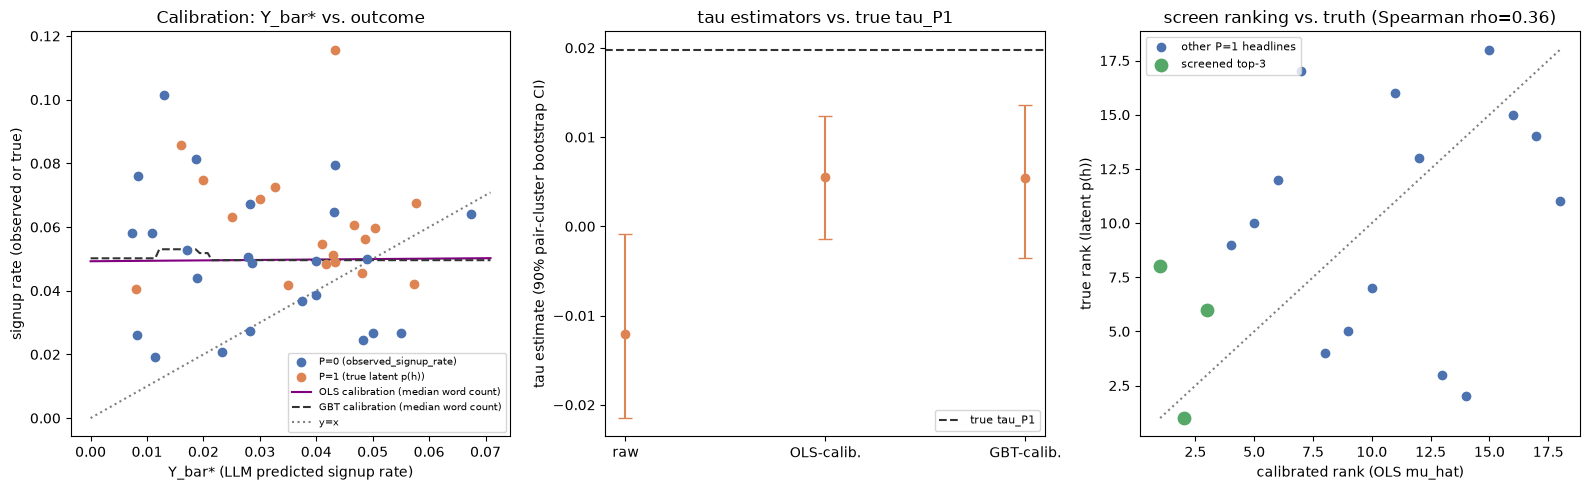

In [16]:
# Visualization only -- uses p0_ystar, p0_Y, p1_ystar, p1_true_p, beta_ols, gbt_model_p0, tau_raw,
# tau_ols, tau_gbt, boot_raw, boot_ols, boot_gbt, true_tau_P1, mu_screen_p1, p1_texts, screened_top3_idx, PALETTE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(p0_ystar[_p0_valid], p0_Y[_p0_valid], color=PALETTE["historical"], label="P=0 (observed_signup_rate)", zorder=3)
ax.scatter(p1_ystar, p1_true_p, color=PALETTE["generated"], label="P=1 (true latent p(h))", zorder=3)
_grid_ystar = np.linspace(0, max(p0_ystar[_p0_valid].max(), p1_ystar.max()) * 1.05, 100)
_med_X = float(np.median(np.concatenate([p0_X[_p0_valid], p1_X])))
_ols_curve = ols_predict(np.full_like(_grid_ystar, _med_X), _grid_ystar, beta_ols)
_gbt_curve = gbt_stumps_predict(gbt_model_p0, np.full_like(_grid_ystar, _med_X), _grid_ystar)
ax.plot(_grid_ystar, _ols_curve, color=PALETTE["toy"] if "toy" in PALETTE else "purple", label="OLS calibration (median word count)")
ax.plot(_grid_ystar, _gbt_curve, color=PALETTE["truth"], linestyle="--", label="GBT calibration (median word count)")
ax.plot([0, _grid_ystar[-1]], [0, _grid_ystar[-1]], color="gray", linestyle=":", label="y=x")
ax.set_xlabel("Y_bar* (LLM predicted signup rate)"); ax.set_ylabel("signup rate (observed or true)")
ax.set_title("Calibration: Y_bar* vs. outcome"); ax.legend(fontsize=7)

ax = axes[1]
_names = ["raw", "OLS-calib.", "GBT-calib."]
_taus = [tau_raw, tau_ols, tau_gbt]
_boots = [boot_raw, boot_ols, boot_gbt]
for i, (nm, th, bt) in enumerate(zip(_names, _taus, _boots)):
    lo, hi = _pct_ci(bt, 0.90)
    ax.errorbar([i], [th], yerr=[[th - lo], [hi - th]], fmt="o", capsize=5, color=PALETTE["generated"])
ax.axhline(true_tau_P1, color=PALETTE["truth"], linestyle="--", label="true tau_P1")
ax.set_xticks(range(3)); ax.set_xticklabels(_names)
ax.set_ylabel("tau estimate (90% pair-cluster bootstrap CI)")
ax.set_title("tau estimators vs. true tau_P1"); ax.legend(fontsize=8)

ax = axes[2]
_calib_rank = np.argsort(np.argsort(-mu_screen_p1)) + 1
_true_rank = np.argsort(np.argsort(-p1_true_p)) + 1
_is_screened = np.isin(np.arange(len(p1_texts)), screened_top3_idx)
ax.scatter(_calib_rank[~_is_screened], _true_rank[~_is_screened], color=PALETTE["historical"], label="other P=1 headlines")
ax.scatter(_calib_rank[_is_screened], _true_rank[_is_screened], color=PALETTE["winner"], label="screened top-3", zorder=4, s=80)
_max_rank = len(p1_texts)
ax.plot([1, _max_rank], [1, _max_rank], color="gray", linestyle=":")
ax.set_xlabel(f"calibrated rank ({SCREEN_CALIBRATOR} mu_hat)"); ax.set_ylabel("true rank (latent p(h))")
ax.set_title(f"screen ranking vs. truth (Spearman rho={spearman_rho:.2f})"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3. Measure: anytime-valid, regression-adjusted monitoring (Lindon, Ham, Tingley, Bojinov, arXiv:2210.08589; q3, q4, q10, q11)

*Re-read before writing this section: `tools/reread.py q3 q4 q10 q11` (all four traces, full text).*

**What the founder does today** (Notebook 2): look at the dashboard every day and stop at the first p < 0.05. Notebook 2's naive toy numbers for that habit: A/A false-positive rate **0.284**; 28.5% of E1 replications "won" (median stop day 7) and 7.0% shipped the wrong sign; the E3 activation effect was wrongly dropped in 13.8% of replications; the E4 "clickbait" arm won 32.9% of the time while true activated-users-per-visitor fell **12%**. Those are NB2's toy numbers, not paper numbers.

**What Lindon et al. give us.** Randomisation-based regression adjustment (Section 6). The estimand is the ATE, `tau* = E[y_i(1) - y_i(0)]`, obtained from the fully interacted regression of Lemma 6.1 (Eq. 24, q3): *"y_i - alpha - (m_i - mu_m)'zeta - (T_i - rho) tau - T_i (m_i - mu_m)' eta"*, where *"T_i ~ Bernoulli(rho) is a treatment indicator with assignment probability rho"* (q3). With the heteroskedasticity-robust standard error the confidence sequence is *"C_n^alpha = [tau_hat_n - rse(tau_hat_n) sqrt(R(g,n,alpha)), tau_hat_n + rse(tau_hat_n) sqrt(R(g,n,alpha))] where R(g,n,alpha) is evaluated with dimension r = 1"* (q3, Eq. 23 for R). Because it is a confidence *sequence*, stopping the first time it excludes zero is allowed: the paper studies exactly that rule, *"tau = inf{n : E_n >= 1/alpha}, stopping when the 1-alpha confidence sequence excludes zero"* (q11).

**What remains true, and what the paper does not claim.** Randomisation removes the linearity, homoskedasticity and Gaussian-error assumptions, but *"i.i.d. sampling"*, Bernoulli assignment with a *constant* probability rho, and moment conditions remain (q3). The CS of Sections 5-6 is **asymptotic**, and the paper says of the linear model that *"in practical applications the linear model itself is likely the dominant source of error"* (q4). Critically for us, the paper simulated continuous t3 residuals and Netflix `PlayDelay`; it does **not** explicitly simulate binary conversion outcomes (q11). So every binary-outcome number below is a **derived-here check**, not a replication of the paper. Nothing in the sources combines regression adjustment with adaptive assignment (q12), so this section only covers the fixed 50/50 A/B case; MAD is section 4.

**Setting (all derived here).** Notebook 2's world at unit level: `generate_visitors(n_days=90, daily_mean=300, ...)` (about 270 visitors/day on average because of weekend seasonality), a 50/50 hash-bucket `assign`, and `simulate_outcomes` with the E1-E4 arm specs from Notebook 2 section 4. **Bots stay in** the data (a real dashboard cannot fully remove them; they convert at zero and dilute every effect). One look per day, alpha = 0.05, rho = 0.5. Regression covariates m = (`prior_sessions_30d`, `visited_pricing_before`, `fit_score`). Lemma 6.1 centres the covariates at the population mean `mu_m`; we estimate `mu_m` from a **separate pre-experiment window** (a different-seed `generate_visitors` run), a derived-here practicality. Each replication draws a fresh visitor population, a fresh assignment, and independent outcomes for E1-E4.


In [17]:
# [S3] Setting, constants, pre-experiment covariate means, and reference-population truth. Derived here.
S3_ALPHA, S3_RHO = 0.05, 0.5
S3_DAYS, S3_DAILY_MEAN, S3_REPS = 90, 300, 150
S3_W5050 = {"control": 0.5, "treatment": 0.5}
# E1-E4 arm specs exactly as in NB2 section 4.
S3_SPECS = {
    "E1": {"control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
           "treatment": {"signup_rel_lift": 0.08, "activation_rel_lift": 0.0}},
    "E2": {"control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
           "treatment": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0}},
    "E3": {"control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
           "treatment": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.15}},
    "E4": {"control": {"signup_rel_lift": 0.0, "activation_rel_lift": 0.0},
           "treatment": {"signup_rel_lift": 0.10, "activation_rel_lift": -0.20}},
}
S3_M_COLS = ["prior_sessions_30d", "visited_pricing_before", "fit_score"]
S3_STREAMS = ["E1_signup", "E2_signup", "E3_signup", "E4_signup", "E2_guard", "E3_act", "E4_guard"]
S3_ACT_WINDOW = 7.0   # guardrail metric = "activated within 7 days of signup"

def s3_covariates(vis):
    return np.column_stack([np.asarray(vis[c], dtype=float) for c in S3_M_COLS])

# mu_m from a separate pre-experiment window (derived here; Lemma 6.1 itself uses the population mean).
S3_pre = generate_visitors(S3_DAYS, S3_DAILY_MEAN, SEED + 7777)
S3_MU_M = s3_covariates(S3_pre).mean(axis=0)

# Reference population (10 more 90-day windows, ~240k visitors) to get the TRUE effects of E1-E4 in this world.
S3_ref = [generate_visitors(S3_DAYS, S3_DAILY_MEAN, SEED + 8000 + j) for j in range(10)]
S3_PBAR = float(np.mean(np.concatenate([_sigmoid(_base_signup_logit(v)) * (~v["is_bot"]) for v in S3_ref])))
S3_P7 = 0.85 * (1 - math.exp(-7.0 / 2.5)) + 0.15 * (2.0 / 15.0)   # P(delay <= 7d) under NB2's 85/15 delay mixture
S3_ACT7_CTRL = S3_PBAR * ACT_BASE_RATE * S3_P7                     # control activated-within-7d per visitor, at maturity
S3_TRUE = {  # true ATE per stream (absolute, per visitor); activation metrics are the fully matured 7-day values
    "E1_signup": 0.08 * S3_PBAR, "E2_signup": 0.0, "E3_signup": 0.0, "E4_signup": 0.10 * S3_PBAR,
    "E2_guard": 0.0, "E3_act": 0.15 * S3_ACT7_CTRL, "E4_guard": (1.10 * 0.80 - 1.0) * S3_ACT7_CTRL,
}
print(f"[S3.1] NOTE reference world: mean signup probability per visitor (bots at 0) = {S3_PBAR:.4f}; "
      f"control activated-within-7d per visitor (matured) = {S3_ACT7_CTRL:.5f}; P(delay<=7d) = {S3_P7:.4f}")
print(f"[S3.2] NOTE true ATEs (absolute, per visitor): E1 signup {S3_TRUE['E1_signup']:.5f} (+8% of {S3_PBAR:.4f}); "
      f"E4 signup {S3_TRUE['E4_signup']:.5f}; E3 activation-7d {S3_TRUE['E3_act']:.5f}; "
      f"E4 activation-7d {S3_TRUE['E4_guard']:.5f} (matured value)")

# Truth check: E4's relative change in activated users per visitor from realized potential outcomes on the reference population.
_act_t = _act_c = 0.0; _n_ref = 0
for _jj, _v in enumerate(S3_ref):
    _o = simulate_outcomes(_v, np.array(["control"] * len(_v["day"])), S3_SPECS["E4"], SEED + 8900 + _jj)
    _act_t += _o["activation_potential"]["treatment"].sum(); _act_c += _o["activation_potential"]["control"].sum(); _n_ref += len(_v["day"])
S3_E4_REL = _act_t / _act_c - 1.0
_se_rel = math.sqrt(1.0 / _act_t + 1.0 / _act_c)  # rough Poisson-count standard error of the ratio
print(f"[S3.3] {_pass(abs(S3_E4_REL - (-0.12)) <= 3 * _se_rel)} E4 relative change in activated users per visitor from simulated "
      f"potential outcomes = {S3_E4_REL:+.4f} vs construction 1.10*0.80-1 = -0.1200 (within 3 SE = {3*_se_rel:.4f}); "
      f"per-visitor activation rates (any delay, bots in) {_act_c/_n_ref:.5f} -> {_act_t/_n_ref:.5f}; NB2's humans-only framing was 0.016 -> 0.01408")
_mu_ref = np.mean(np.concatenate([s3_covariates(v) for v in S3_ref]), axis=0)
_sd_ref = np.std(np.concatenate([s3_covariates(v) for v in S3_ref]), axis=0)
_dev = np.abs(S3_MU_M - _mu_ref) / _sd_ref
print(f"[S3.4] {_pass(bool(np.all(_dev < 0.05)))} pre-window mu_m = {np.round(S3_MU_M, 4).tolist()} within 0.05 covariate-SD of the "
      f"reference population means (max deviation {_dev.max():.4f} SD)")


[S3.1] NOTE reference world: mean signup probability per visitor (bots at 0) = 0.0388; control activated-within-7d per visitor (matured) = 0.01270; P(delay<=7d) = 0.8183
[S3.2] NOTE true ATEs (absolute, per visitor): E1 signup 0.00310 (+8% of 0.0388); E4 signup 0.00388; E3 activation-7d 0.00190; E4 activation-7d -0.00152 (matured value)
[S3.3] PASS E4 relative change in activated users per visitor from simulated potential outcomes = -0.1099 vs construction 1.10*0.80-1 = -0.1200 (within 3 SE = 0.0722); per-visitor activation rates (any delay, bots in) 0.01525 -> 0.01357; NB2's humans-only framing was 0.016 -> 0.01408
[S3.4] PASS pre-window mu_m = [1.1906, 0.4217, 0.1097] within 0.05 covariate-SD of the reference population means (max deviation 0.0020 SD)


### 3.1 Choosing g (Lindon et al.; q10)

The mixture parameter g is the one knob a practitioner must set. The paper's rule (q10): *"Growth-Optimal: g_g(xi_MDE) = 1 / (xi_MDE^2 rho (1 - rho))"*, and *"When targeting a Minimum Detectable Effect (xi_MDE), setting Phi = xi_MDE^-2 maximizes the worst-case growth"* (q10); its worked example uses *alpha = 0.01, power 0.95, xi_MDE = 0.2, g_g = 100* (q10/q4). Section 4.3.1 adds *"The tuning parameter g can be chosen to minimize the confidence region at a particular sample size n"* (q3). The larger g is, the longer the "delayed start": *"its width is infinite until (alpha^2 r g/(n+g))^(r/(nu_n+r)) > g/(n+g). For example, using r = k = 1, alpha = 0.05 and g = 10^4, requires a minimum sample size of 247 ... g = 10^2 requires a minimum sample size of 27"* (q3).

The paper's xi is a *standardised* effect (effect / residual standard deviation). Our outcome is a conversion indicator, so we **standardise the MDE ourselves (derived here)**: xi = absolute MDE / sigma with sigma = sqrt(p(1-p)) at the 4% base rate, and the MDE is a +10% relative lift on that 4%.


In [18]:
# [S3] Choosing g by the growth-optimal rule (q10) with a derived-here standardised MDE for a conversion rate.
S3_BASE, S3_MDE_REL = 0.04, 0.10
S3_MDE_ABS = S3_MDE_REL * S3_BASE                       # 0.004 absolute
S3_SIGMA = math.sqrt(S3_BASE * (1 - S3_BASE))           # standardisation: sqrt(p(1-p))  (derived here)
S3_XI = S3_MDE_ABS / S3_SIGMA
S3_G = 1.0 / (S3_XI ** 2 * S3_RHO * (1 - S3_RHO))       # g_g(xi_MDE) = 1/(xi^2 rho (1-rho))   (q10)
print(f"[S3.5] NOTE MDE = +{S3_MDE_REL:.0%} of {S3_BASE:.0%} = {S3_MDE_ABS:.4f} absolute; sigma = sqrt(p(1-p)) = {S3_SIGMA:.4f}; "
      f"xi = {S3_XI:.5f}; growth-optimal g = 1/(xi^2 rho(1-rho)) = {S3_G:,.1f}")

def s3_delayed_start_min_n(g, k, alpha=S3_ALPHA, nmax=20000):
    """Smallest n with a finite t-CS half-width for a regression with k coefficients, nu = n - k (mirrors NB1 section 2(a))."""
    for n in range(k + 2, nmax):
        if np.isfinite(R_galpha(g, n, alpha, nu=n - k, r=1.0)):
            return n
    return None

_a1, _a2 = s3_delayed_start_min_n(1e4, 1), s3_delayed_start_min_n(1e2, 1)   # paper anchors use r=k=1, nu=n-1
print(f"[S3.6] {_pass(_a1 == 247 and _a2 == 27)} paper anchors reproduced with nu=n-1: g=1e4 -> n_min={_a1} (q3: 247), "
      f"g=1e2 -> n_min={_a2} (q3: 27)")
S3_NMIN_ADJ = s3_delayed_start_min_n(S3_G, 8)     # our adjusted regression has k = 8 coefficients (nu = n - 8)
S3_NMIN_UN = s3_delayed_start_min_n(S3_G, 2)      # unadjusted (1, T-rho): k = 2
S3_NMIN_K1 = s3_delayed_start_min_n(S3_G, 1)
_first_look_n = int(np.min([int((v["day"] == 0).sum()) for v in S3_ref]))
print(f"[S3.7] {_pass(S3_NMIN_K1 is not None and 200 < S3_NMIN_K1 < 300)} our g={S3_G:,.0f} sits between the paper's anchors "
      f"(27 at g=1e2, 247 at g=1e4) as expected: delayed-start n_min = {S3_NMIN_K1} (k=1), {S3_NMIN_UN} (unadjusted, nu=n-2), "
      f"{S3_NMIN_ADJ} (adjusted, nu=n-8). Smallest day-1 sample in the 10 reference windows = {_first_look_n} visitors")


[S3.5] NOTE MDE = +10% of 4% = 0.0040 absolute; sigma = sqrt(p(1-p)) = 0.1960; xi = 0.02041; growth-optimal g = 1/(xi^2 rho(1-rho)) = 9,600.0
[S3.6] PASS paper anchors reproduced with nu=n-1: g=1e4 -> n_min=247 (q3: 247), g=1e2 -> n_min=27 (q3: 27)
[S3.7] PASS our g=9,600 sits between the paper's anchors (27 at g=1e2, 247 at g=1e4) as expected: delayed-start n_min = 242 (k=1), 243 (unadjusted, nu=n-2), 246 (adjusted, nu=n-8). Smallest day-1 sample in the 10 reference windows = 266 visitors


### 3.2 The engine: daily regression-adjusted and unadjusted CS, vectorised (derived here: implementation only)

For each look we fit the fully interacted regression `w_i = (1, m_i - mu_m, T_i - rho, T_i (m_i - mu_m))` (k = 8 coefficients, `tau` is coefficient index 4) and, for comparison, the unadjusted `w_i = (1, T_i - rho)` (k = 2). The half-width is `rse * sqrt(R(g, n, alpha))` with `R` from Notebook 1's `R_galpha` (r = 1, nu = n - k) and `rse` the same sandwich estimator as Notebook 1's `ols_hc1_batch`. `ols_hc1_batch` runs one sample size per call with einsum; to run 150 replications x 90 daily looks x 7 outcome streams in a few minutes we reorganise the same algebra as BLAS matrix products (`s3_cs_engine`) and **check it against `ols_hc1_batch` to machine precision** before using it. A CS whose sandwich standard error is exactly zero (no variation observed yet, e.g. no activations on day 1) is treated as infinitely wide (derived here).

**Guardrail metric (derived here).** "Activated within 7 days of signup", counted only if `signup_day + delay <= look day` (right-censored at the look), per *visitor* (not per signup: conditioning on signup would condition on a post-treatment variable, which E4 changes). This violates the i.i.d.-units condition mildly (units arriving later have had less time to mature) and its estimand grows toward its matured value as the experiment ages, so we use it only as a *harm detector* ("does the CS exclude 0 on the harmful side?") and we test its false-alarm rate on an A/A (E2) below rather than assume it.


In [19]:
# [S3] The engine. Same estimator as NB1's ols_hc1_batch (Lindon et al. Section 5/6, q3): V = n (W'W)^-1 Sigma_hat (W'W)^-1,
# Sigma_hat = (1/nu) sum e_i^2 w_i w_i', half-width = rse * sqrt(R(g,n,alpha)) with r = 1.
def s3_design(vis, T, mu_m):
    """adj: w=(1, m-mu_m, T-rho, T*(m-mu_m)) [tau at index 4]; unadj: w=(1, T-rho) [tau at index 1]."""
    mc = s3_covariates(vis) - mu_m
    Tc = (T - S3_RHO)[:, None]
    return np.column_stack([np.ones(len(T)), mc, Tc, T[:, None] * mc]), np.column_stack([np.ones(len(T)), Tc])

def s3_cs_engine(Z, ycb, n_ends, tau_idx, g, alpha=S3_ALPHA):
    """Z: (N,k), rows sorted by arrival day. ycb(look, n) -> (n, O) outcomes AS OBSERVED at that look.
    Returns tau_hat (D,O), half-width (D,O), rse (D,O) for looks at cumulative sample sizes n_ends."""
    N, k = Z.shape
    iu0, iu1 = np.triu_indices(k)
    Qu = Z[:, iu0] * Z[:, iu1]                 # unique entries of w w'
    cQu = np.cumsum(Qu, axis=0)
    tau_out, rse_out = [], []
    for d, n in enumerate(n_ends):
        Zn = Z[:n]
        Y = ycb(d, n)
        WtW = np.zeros((k, k)); WtW[iu0, iu1] = cQu[n - 1]; WtW[iu1, iu0] = cQu[n - 1]
        beta = np.linalg.solve(WtW, Zn.T @ Y)
        nu = n - k
        m_u = ((Y - Zn @ beta) ** 2).T @ Qu[:n] / nu
        meat = np.zeros((Y.shape[1], k, k)); meat[:, iu0, iu1] = m_u; meat[:, iu1, iu0] = m_u
        a = np.linalg.inv(WtW)[tau_idx]
        tau_out.append(beta[tau_idx]); rse_out.append(np.sqrt(n * np.einsum("k,okl,l->o", a, meat, a)))
    tau, rse = np.array(tau_out), np.array(rse_out)
    n_arr = np.asarray(n_ends, dtype=float)
    Rv = R_galpha(g, n_arr, alpha, n_arr - k, r=1.0)
    with np.errstate(invalid="ignore"):
        half = rse * np.sqrt(Rv)[:, None]
    return tau, np.where(rse > 0, half, np.inf), rse

def s3_replication(r, mu_m, g):
    """One replication: fresh 90-day population, fresh 50/50 hash assignment, independent outcome draws for E1..E4."""
    seed_r = SEED + 3000 + r
    vis = generate_visitors(S3_DAYS, S3_DAILY_MEAN, seed_r)
    arm = assign(vis["visitor_id"], f"s3-rep{r}", S3_W5050)
    T = (arm == "treatment").astype(float)
    day = vis["day"]
    n_ends = np.array([int((day <= d).sum()) for d in range(S3_DAYS)])
    outs = {e: simulate_outcomes(vis, arm, S3_SPECS[e], seed_r + 100000 * (i + 1)) for i, e in enumerate(S3_SPECS)}
    Ystat = np.column_stack([outs[e]["signup_realized"] for e in ("E1", "E2", "E3", "E4")]).astype(float)
    evt = {}
    for e in ("E2", "E3", "E4"):
        dl = outs[e]["delay_realized"]
        ok = outs[e]["activation_realized"] & (dl <= S3_ACT_WINDOW)          # activated within 7d of signup
        evt[e] = np.where(ok, day + np.nan_to_num(dl, nan=0.0), np.inf)      # activation time; inf if never
    def ycb(d, n):   # outcome columns as observed at the END of look-day d
        dyn = np.column_stack([(evt[e][:n] <= d) for e in ("E2", "E3", "E4")]).astype(float)
        return np.hstack([Ystat[:n], dyn])
    Z_adj, Z_un = s3_design(vis, T, mu_m)
    ta, ha, ra = s3_cs_engine(Z_adj, ycb, n_ends, 4, g)
    tu, hu, ru = s3_cs_engine(Z_un, ycb, n_ends, 1, g)
    return dict(ta=ta, ha=ha, tu=tu, hu=hu, ra=ra, ru=ru, n_ends=n_ends, t_share=float(T.mean()),
                Z_adj=Z_adj, Z_un=Z_un, ycb=ycb)

# Equivalence check against NB1's ols_hc1_batch on three (replication, look) pairs, all 7 outcome streams at once.
_chk = s3_replication(0, S3_MU_M, S3_G)
_max_b, _max_v = 0.0, 0.0
for _d in (0, 44, 89):
    _n = int(_chk["n_ends"][_d]); _Y = _chk["ycb"](_d, _n)
    for _Z, _ti, _tau, _rse in ((_chk["Z_adj"], 4, _chk["ta"], _chk["ra"]), (_chk["Z_un"], 1, _chk["tu"], _chk["ru"])):
        _b, _V, _nu = ols_hc1_batch(np.repeat(_Z[None, :_n], _Y.shape[1], axis=0), _Y.T)
        _ok = _rse[_d] > 0
        _max_b = max(_max_b, float(np.abs(_b[:, _ti] - _tau[_d]).max()))
        _max_v = max(_max_v, float(np.abs(np.sqrt(_V[:, _ti, _ti])[_ok] - _rse[_d][_ok]).max()))
print(f"[S3.8] {_pass(_max_b < 1e-9 and _max_v < 1e-9)} fast engine == NB1 ols_hc1_batch (tau_hat max abs diff {_max_b:.2e}, "
      f"rse max abs diff {_max_v:.2e}) at looks 1, 45, 90, adjusted and unadjusted, all 7 outcome streams")


[S3.8] PASS fast engine == NB1 ols_hc1_batch (tau_hat max abs diff 1.55e-17, rse max abs diff 3.49e-16) at looks 1, 45, 90, adjusted and unadjusted, all 7 outcome streams


In [20]:
# [S3] Run the Monte Carlo: S3_REPS replications x 90 daily looks x 7 outcome streams x {adjusted, unadjusted}.
# ZERO DeepSeek calls here (pure simulation): live-call counter is checked before and after.
_calls_before = LLM_STATS["live_calls"]
_t0 = time.time()
_ta, _ha, _tu, _hu, _ne, _ts = [], [], [], [], [], []
for _r in range(S3_REPS):
    _o = s3_replication(_r, S3_MU_M, S3_G)
    _ta.append(_o["ta"]); _ha.append(_o["ha"]); _tu.append(_o["tu"]); _hu.append(_o["hu"]); _ne.append(_o["n_ends"]); _ts.append(_o["t_share"])
    if (_r + 1) % 50 == 0:
        print(f"    ... {_r + 1}/{S3_REPS} replications, {time.time() - _t0:.0f}s elapsed")
S3_TA, S3_HA, S3_TU, S3_HU = np.stack(_ta), np.stack(_ha), np.stack(_tu), np.stack(_hu)   # (reps, 90, 7)
S3_NE = np.stack(_ne)                                                                     # (reps, 90) cumulative visitors
S3_TSHARE = np.array(_ts)
S3_LO_A, S3_HI_A = S3_TA - S3_HA, S3_TA + S3_HA
S3_LO_U, S3_HI_U = S3_TU - S3_HU, S3_TU + S3_HU
S3_IDX = {s: i for i, s in enumerate(S3_STREAMS)}
S3_RUNTIME = time.time() - _t0
print(f"[S3.9] {_pass(LLM_STATS['live_calls'] == _calls_before)} zero live DeepSeek calls in section 3 "
      f"(live_calls {_calls_before} -> {LLM_STATS['live_calls']}); Monte Carlo runtime {S3_RUNTIME:.0f}s")
print(f"[S3.10] {_pass(abs(S3_TSHARE.mean() - 0.5) < 0.005)} mean treated share over {S3_REPS} replications = {S3_TSHARE.mean():.4f} "
      f"(hash bucketing behaves like Bernoulli(rho=0.5)); mean visitors by day 28 = {S3_NE[:, 27].mean():,.0f}, by day 90 = {S3_NE[:, -1].mean():,.0f}")


    ... 50/150 replications, 75s elapsed
    ... 100/150 replications, 143s elapsed
    ... 150/150 replications, 182s elapsed
[S3.9] PASS zero live DeepSeek calls in section 3 (live_calls 0 -> 0); Monte Carlo runtime 182s
[S3.10] PASS mean treated share over 150 replications = 0.5006 (hash bucketing behaves like Bernoulli(rho=0.5)); mean visitors by day 28 = 7,448, by day 90 = 23,994


### 3.3 Claim: stopping "when the CS excludes 0" keeps the false-alarm rate at alpha, and the price is width (E2 A/A and E1)

The paper's own numbers, quoted separately from ours: *"Section B.7.3 / Figure 5 (alpha = 0.01) shows 0.04% rejections for g = 100 vs. 1.07% for fixed-n at horizon n* = 1785"* (q11, q4), and for the price in power, *"at fixed sample size n* = 1785 ... a fixed-n test achieves 95.02% power, whereas the anytime-valid test achieves 81.69% (g = 100) ... if evaluated strictly at n*"* with a mean stopping time of *1,214.45* (q11, q4); Notebook 1's section 2 already reproduced the ~0.818 power (its [S2.6]). Those are Gaussian-outcome simulations with a *standardised* effect of 0.2, about ten times our own standardised MDE of 0.02 ([S3.5]).

What we can check on **our** data (binary outcomes, 4% base rate, daily looks, alpha = 0.05, which the paper did not simulate, q11 - a derived-here test):

1. **E2 (A/A)**: how often does the adjusted (and the unadjusted) CS exclude 0 at *any* of 90 daily looks? Time-uniform coverage of the true ATE (which is 0) is the same event's complement, so we report both. Compare with Notebook 2's naive daily-peek toy number, 0.284 (NB2 measured a 28-day window; we report 28 and 90 days).
2. **E1 (+8% signup lift, below the +10% MDE)**: how many replications stop by day 28 and day 90, when, with which sign, and how much narrower is the adjusted band? Whatever the answer is at about 270 visitors/day, we report it as computed; "not stopped" is a legitimate outcome, not an error.
3. **Extrapolation (derived here, not simulated)**: at what sample size would the CS exclude 0 if the estimate sat exactly at the true effect? Compare Notebook 2's fixed-horizon **61,115 per arm** (~408 days at 150/arm/day).


In [21]:
# [S3] (a) E2 A/A: time-uniform false-positive rate of "stop when the CS excludes 0", adjusted vs unadjusted, 90 daily looks.
def s3_first_day(mask):
    """mask (reps, days) bool -> first True day (1-indexed) per replication, NaN if never."""
    return np.where(mask.any(axis=1), mask.argmax(axis=1) + 1, np.nan)

def s3_rate(k, n):
    p, lo, hi = wilson_interval(int(k), int(n))
    return f"{int(k)}/{int(n)} = {p:.3f} (Wilson 95% [{lo:.3f}, {hi:.3f}])"

S3_SLACK = 3 * math.sqrt(S3_ALPHA * (1 - S3_ALPHA) / S3_REPS)     # 3 Monte Carlo SEs at the nominal rate
_j2 = S3_IDX["E2_signup"]
S3_E2_EXCL_A = (S3_LO_A[:, :, _j2] > 0) | (S3_HI_A[:, :, _j2] < 0)   # CS excludes 0 on either side
S3_E2_EXCL_U = (S3_LO_U[:, :, _j2] > 0) | (S3_HI_U[:, :, _j2] < 0)
S3_E2_FPR_A, S3_E2_FPR_U = S3_E2_EXCL_A.any(1).mean(), S3_E2_EXCL_U.any(1).mean()
S3_E2_FPR28_A, S3_E2_FPR28_U = S3_E2_EXCL_A[:, :28].any(1).mean(), S3_E2_EXCL_U[:, :28].any(1).mean()
print(f"[S3.11] {_pass(S3_E2_FPR_A <= S3_ALPHA + S3_SLACK and S3_E2_FPR_U <= S3_ALPHA + S3_SLACK)} E2 time-uniform false-positive rate over 90 daily looks "
      f"<= alpha + 3 MC-SE ({S3_ALPHA + S3_SLACK:.3f}): adjusted {s3_rate(S3_E2_EXCL_A.any(1).sum(), S3_REPS)}; unadjusted {s3_rate(S3_E2_EXCL_U.any(1).sum(), S3_REPS)}")
_cov_A = ((S3_LO_A[:, :, _j2] <= 0) & (S3_HI_A[:, :, _j2] >= 0)).all(1).mean()
_cov_U = ((S3_LO_U[:, :, _j2] <= 0) & (S3_HI_U[:, :, _j2] >= 0)).all(1).mean()
print(f"[S3.12] {_pass(abs(_cov_A - (1 - S3_E2_FPR_A)) < 1e-12 and abs(_cov_U - (1 - S3_E2_FPR_U)) < 1e-12 and _cov_A >= 1 - S3_ALPHA - S3_SLACK and _cov_U >= 1 - S3_ALPHA - S3_SLACK)} "
      f"time-uniform coverage of the true ATE (0) = 1 - false-positive rate: adjusted {_cov_A:.4f}, unadjusted {_cov_U:.4f} (>= {1 - S3_ALPHA - S3_SLACK:.3f})")
_ub28_A = wilson_interval(int(S3_E2_EXCL_A[:, :28].any(1).sum()), S3_REPS)[2]
_ub28_U = wilson_interval(int(S3_E2_EXCL_U[:, :28].any(1).sum()), S3_REPS)[2]
print(f"[S3.13] {_pass(_ub28_A < 0.284 and _ub28_U < 0.284)} by day 28 (NB2's window) the CS false-positive rate is adjusted {s3_rate(S3_E2_EXCL_A[:, :28].any(1).sum(), S3_REPS)} "
      f"and unadjusted {s3_rate(S3_E2_EXCL_U[:, :28].any(1).sum(), S3_REPS)}; NB2's naive daily-peek toy number was 0.284 "
      f"(single look at day 28: 0.0455) -- both Wilson upper bounds are below it")
# derived-here check of the censored guardrail metric: its false-alarm rate on an A/A (see section 3.2 caveats).
_jg2 = S3_IDX["E2_guard"]
S3_E2G_EXCL_A = (S3_LO_A[:, :, _jg2] > 0) | (S3_HI_A[:, :, _jg2] < 0)
print(f"[S3.14] {_pass(S3_E2G_EXCL_A.any(1).mean() <= S3_ALPHA + S3_SLACK)} derived-here check: right-censored 7-day activation guardrail on the A/A (E2), "
      f"adjusted CS excludes 0 at any look in {s3_rate(S3_E2G_EXCL_A.any(1).sum(), S3_REPS)} (limit alpha + 3 MC-SE = {S3_ALPHA + S3_SLACK:.3f})")


[S3.11] PASS E2 time-uniform false-positive rate over 90 daily looks <= alpha + 3 MC-SE (0.103): adjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]); unadjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025])
[S3.12] PASS time-uniform coverage of the true ATE (0) = 1 - false-positive rate: adjusted 1.0000, unadjusted 1.0000 (>= 0.897)
[S3.13] PASS by day 28 (NB2's window) the CS false-positive rate is adjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]) and unadjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]); NB2's naive daily-peek toy number was 0.284 (single look at day 28: 0.0455) -- both Wilson upper bounds are below it
[S3.14] PASS derived-here check: right-censored 7-day activation guardrail on the A/A (E2), adjusted CS excludes 0 at any look in 1/150 = 0.007 (Wilson 95% [0.001, 0.037]) (limit alpha + 3 MC-SE = 0.103)


In [22]:
# [S3] (b) E1 (+8% signup lift): stopping, sign, width ratio, and an extrapolation of the sample size needed.
_j1 = S3_IDX["E1_signup"]; S3_TAU_E1 = S3_TRUE["E1_signup"]
_pos_A, _pos_U = S3_LO_A[:, :, _j1] > 0, S3_LO_U[:, :, _j1] > 0          # CS wholly above 0 = "winner"
_neg_A, _neg_U = S3_HI_A[:, :, _j1] < 0, S3_HI_U[:, :, _j1] < 0          # CS wholly below 0 = wrong sign
S3_E1_STOP_A, S3_E1_STOP_U = s3_first_day(_pos_A), s3_first_day(_pos_U)
S3_E1_BY28_A, S3_E1_BY90_A = _pos_A[:, :28].any(1).mean(), _pos_A.any(1).mean()
S3_E1_BY90_U = _pos_U.any(1).mean()
S3_E1_MED_A = float(np.nanmedian(S3_E1_STOP_A)) if np.isfinite(S3_E1_STOP_A).any() else float("nan")
S3_E1_MED_U = float(np.nanmedian(S3_E1_STOP_U)) if np.isfinite(S3_E1_STOP_U).any() else float("nan")
print(f"[S3.15] NOTE E1 true ATE = {S3_TAU_E1:.5f} per visitor (+8% of {S3_PBAR:.4f}); the +10% MDE used to pick g is {S3_MDE_ABS:.4f}, so E1 is smaller than the effect g was tuned for")
print(f"[S3.16] NOTE E1 stopped as a winner by day 28: adjusted {s3_rate(_pos_A[:, :28].any(1).sum(), S3_REPS)}; unadjusted {s3_rate(_pos_U[:, :28].any(1).sum(), S3_REPS)}")
print(f"[S3.17] NOTE E1 stopped as a winner by day 90: adjusted {s3_rate(_pos_A.any(1).sum(), S3_REPS)}; unadjusted {s3_rate(_pos_U.any(1).sum(), S3_REPS)}; "
      f"NB2's naive daily peek 'won' 28.5% by day 28")
print(f"[S3.18] NOTE median stopping day among stoppers: adjusted {S3_E1_MED_A} (n stoppers = {int(_pos_A.any(1).sum())}), "
      f"unadjusted {S3_E1_MED_U} (n stoppers = {int(_pos_U.any(1).sum())}); earliest stop day in any replication: adjusted {np.nanmin(S3_E1_STOP_A) if np.isfinite(S3_E1_STOP_A).any() else float('nan')}, "
      f"unadjusted {np.nanmin(S3_E1_STOP_U) if np.isfinite(S3_E1_STOP_U).any() else float('nan')}; NB2's naive peek median stop day was 7")
_st = np.where(np.isfinite(S3_E1_STOP_A))[0]
S3_E1_EST_AT_STOP = float(np.mean([S3_TA[_r_, int(S3_E1_STOP_A[_r_]) - 1, _j1] for _r_ in _st])) if len(_st) else float("nan")
print(f"[S3.19] NOTE winner's-curse check: among the {len(_st)} adjusted E1 stoppers the mean estimate AT the stopping day is {S3_E1_EST_AT_STOP:.5f} vs the true ATE {S3_TAU_E1:.5f} "
      f"({S3_E1_EST_AT_STOP / S3_TAU_E1:.1f}x): the interval itself stays valid at the stopping moment, but the point estimate at that moment overshoots, so quote the interval, not the estimate")
S3_E1_WRONG_A, S3_E1_WRONG_U = _neg_A.any(1).mean(), _neg_U.any(1).mean()
print(f"[S3.20] {_pass(S3_E1_WRONG_A <= S3_ALPHA + S3_SLACK and S3_E1_WRONG_U <= S3_ALPHA + S3_SLACK)} E1 wrong-sign declarations (CS wholly below 0 at any look; should be ~0): "
      f"adjusted {s3_rate(_neg_A.any(1).sum(), S3_REPS)}; unadjusted {s3_rate(_neg_U.any(1).sum(), S3_REPS)}; NB2's naive peek sign-error rate was 0.070")
_cov1_A = ((S3_LO_A[:, :, _j1] <= S3_TAU_E1) & (S3_HI_A[:, :, _j1] >= S3_TAU_E1)).all(1).mean()
_cov1_U = ((S3_LO_U[:, :, _j1] <= S3_TAU_E1) & (S3_HI_U[:, :, _j1] >= S3_TAU_E1)).all(1).mean()
print(f"[S3.21] {_pass(_cov1_A >= 1 - S3_ALPHA - S3_SLACK and _cov1_U >= 1 - S3_ALPHA - S3_SLACK)} E1 time-uniform coverage of the true ATE {S3_TAU_E1:.5f} over 90 daily looks: "
      f"adjusted {_cov1_A:.4f}, unadjusted {_cov1_U:.4f} (>= {1 - S3_ALPHA - S3_SLACK:.3f}; derived-here check on binary outcomes, not a replication of the paper)")
# width ratio adjusted / unadjusted (only where both are finite)
_wr = S3_HA[:, :, _j1] / S3_HU[:, :, _j1]
_fin = np.isfinite(_wr)
S3_E1_WIDTH_RATIO = float(_wr[_fin].mean())
_wr28, _wr90 = float(np.nanmean(_wr[:, 27])), float(np.nanmean(_wr[:, -1]))
print(f"[S3.22] {_pass(S3_E1_WIDTH_RATIO < 1.0)} mean width ratio adjusted/unadjusted (E1, all reps and days) = {S3_E1_WIDTH_RATIO:.4f} "
      f"(day 1: {np.nanmean(_wr[:, 0]):.4f}, day 28: {_wr28:.4f}, day 90: {_wr90:.4f}); q3 says smaller standard errors shrink the CS at every n")
print(f"[S3.23] {'PASS' if S3_E1_WIDTH_RATIO < 0.95 else 'NOTE'} material narrowing (mean ratio < 0.95)? {'yes' if S3_E1_WIDTH_RATIO < 0.95 else 'NO'}: mean narrowing = {(1 - S3_E1_WIDTH_RATIO):.1%}, "
      f"implied residual-variance reduction ~ {(1 - S3_E1_WIDTH_RATIO ** 2):.1%}: with a 4% base rate and these three covariates the outcome is barely predictable, "
      f"and eight regression coefficients cost degrees of freedom in the earliest looks")

def s3_n_needed(c, k, target, g=S3_G, alpha=S3_ALPHA):
    """Smallest total n at which half-width c*sqrt(R(g,n,alpha,n-k)/n) <= target. c = rse*sqrt(n), taken as constant (derived here)."""
    n = np.unique(np.round(np.logspace(math.log10(k + 2), 8, 6000)))
    half = c * np.sqrt(R_galpha(g, n, alpha, n - k, r=1.0) / n)
    ok = np.where(np.isfinite(half) & (half <= target))[0]
    return float(n[ok[0]]) if len(ok) else float("nan")

_n90 = S3_NE[:, -1].astype(float)
_R90 = R_galpha(S3_G, _n90, S3_ALPHA, _n90 - 8, r=1.0)
S3_C_ADJ = {s: float(np.median(S3_HA[:, -1, S3_IDX[s]] / np.sqrt(_R90) * np.sqrt(_n90))) for s in S3_STREAMS}   # rse * sqrt(n) at day 90
S3_VIS_PER_DAY = float(_n90.mean() / S3_DAYS)
S3_E1_N_NEEDED = s3_n_needed(S3_C_ADJ["E1_signup"], 8, S3_TAU_E1)
print(f"[S3.24] NOTE derived extrapolation (assumes tau_hat = true tau and rse*sqrt(n) constant): the adjusted CS excludes 0 for E1 at n ~ {S3_E1_N_NEEDED:,.0f} visitors "
      f"= {S3_E1_N_NEEDED / 2:,.0f} per arm ~ {S3_E1_N_NEEDED / S3_VIS_PER_DAY:,.0f} days at {S3_VIS_PER_DAY:,.0f} visitors/day; "
      f"= {S3_E1_N_NEEDED / 2 / 61115:.2f}x NB2's fixed-horizon 61,115 per arm (~408 days at 150/arm/day; NB2's figure targets a stated power, this one is the crossing point at tau_hat = tau, so the operating points differ). The CS is the price of being allowed to look every day (Theorem 5.5, q11: "
      f"R(g,n,alpha) > R_G(g,n,alpha) for all n).")
# curves for the plots
S3_CUM_E1_A = np.maximum.accumulate(_pos_A, axis=1).mean(0)
S3_CUM_E1_U = np.maximum.accumulate(_pos_U, axis=1).mean(0)
S3_CUM_E2_A = np.maximum.accumulate(S3_E2_EXCL_A, axis=1).mean(0)
S3_CUM_E2_U = np.maximum.accumulate(S3_E2_EXCL_U, axis=1).mean(0)
_med_tau90 = np.median(S3_TA[:, -1, _j1]); S3_EX_REP = int(np.argmin(np.abs(S3_TA[:, -1, _j1] - _med_tau90)))   # representative replication
S3_HW_MED_A = np.array([np.median(S3_HA[:, d, _j1]) for d in range(S3_DAYS)])
S3_HW_MED_U = np.array([np.median(S3_HU[:, d, _j1]) for d in range(S3_DAYS)])
_wr_fin = np.where(np.isfinite(_wr), _wr, np.nan)
S3_WR_MED = np.nanmedian(_wr_fin, axis=0)
S3_WR_LO, S3_WR_HI = np.nanpercentile(_wr_fin, 10, axis=0), np.nanpercentile(_wr_fin, 90, axis=0)
print(f"[S3.25] NOTE plotted example = replication {S3_EX_REP} (the one whose day-90 adjusted E1 estimate is closest to the median across replications, not cherry-picked)")


[S3.15] NOTE E1 true ATE = 0.00310 per visitor (+8% of 0.0388); the +10% MDE used to pick g is 0.0040, so E1 is smaller than the effect g was tuned for
[S3.16] NOTE E1 stopped as a winner by day 28: adjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]); unadjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025])
[S3.17] NOTE E1 stopped as a winner by day 90: adjusted 6/150 = 0.040 (Wilson 95% [0.018, 0.085]); unadjusted 7/150 = 0.047 (Wilson 95% [0.023, 0.093]); NB2's naive daily peek 'won' 28.5% by day 28
[S3.18] NOTE median stopping day among stoppers: adjusted 71.0 (n stoppers = 6), unadjusted 75.0 (n stoppers = 7); earliest stop day in any replication: adjusted 60.0, unadjusted 60.0; NB2's naive peek median stop day was 7
[S3.19] NOTE winner's-curse check: among the 6 adjusted E1 stoppers the mean estimate AT the stopping day is 0.00952 vs the true ATE 0.00310 (3.1x): the interval itself stays valid at the stopping moment, but the point estimate at that moment overshoots, so quote the interv

**How to read this chart (plot 1: one E1 realization, and how wide the band is).** *Left* -- one typical replication (the one whose day-90 estimate is the median; not cherry-picked). x = day, y = treatment-minus-control signup rate per visitor, clipped to +-0.03. The tan band is the unadjusted CS, the orange band the adjusted CS (they nearly coincide), the orange line the adjusted estimate, the green horizontal line the true ATE, the black line zero. What to look for: the band is huge on the first days (few visitors and the price of variance uncertainty at small n), then narrows roughly like 1/sqrt(n). A win is declared only on a day when the *lower* edge of the band sits above the black line; in this typical replication the band still contains 0 on day 90. *Middle* -- median CS half-width over all replications (log y). The green line is the true E1 effect: for a win at an estimate equal to the truth the half-width has to fall below it; the red dotted line is the +10% MDE (0.004) used for futility. Compare the curve's day-90 value ([S3.35] prints it) with the green line. *Right* -- median (with 10th-90th percentile) of adjusted/unadjusted half-width. A ratio of 1 means regression adjustment changed nothing; 0.95 would be a 5% narrower band. What it means for the founder: adjusting for three pre-visit covariates gains ~0.4% on a 4% conversion metric ([S3.22]-[S3.23]), and costs about 3% *more* width on day 1 (eight coefficients instead of two); the paper's variance-reduction promise (q3: "smaller standard errors shrink the width of the confidence sequence at every sample size") holds in direction but is worth almost nothing when the covariates barely predict a rare binary outcome. Its real payoff in the paper is on a continuous, strongly predictable outcome (Netflix `PlayDelay` with its own pre-period value, q4), which we did not simulate.


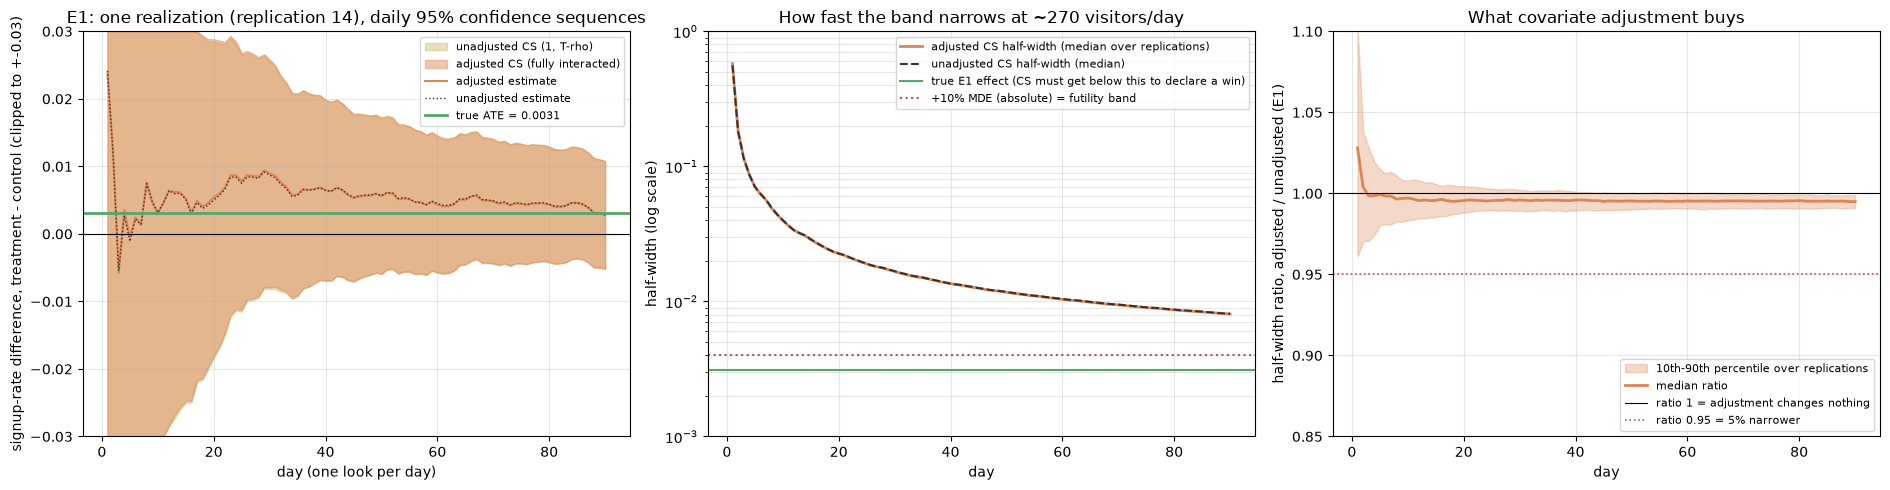

In [23]:
# Visualization only -- uses S3_LO_A, S3_HI_A, S3_LO_U, S3_HI_U, S3_TA, S3_TU, S3_EX_REP, S3_TAU_E1, S3_MDE_ABS, S3_HW_MED_A, S3_HW_MED_U, S3_WR_MED, S3_WR_LO, S3_WR_HI, S3_IDX, PALETTE
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
_j = S3_IDX["E1_signup"]
_days = np.arange(1, S3_DAYS + 1)
_clip = 0.03
ax = axes[0]
_loA, _hiA = np.clip(S3_LO_A[S3_EX_REP, :, _j], -_clip, _clip), np.clip(S3_HI_A[S3_EX_REP, :, _j], -_clip, _clip)
_loU, _hiU = np.clip(S3_LO_U[S3_EX_REP, :, _j], -_clip, _clip), np.clip(S3_HI_U[S3_EX_REP, :, _j], -_clip, _clip)
ax.fill_between(_days, _loU, _hiU, color=PALETTE["inconclusive"], alpha=0.45, label="unadjusted CS (1, T-rho)")
ax.fill_between(_days, _loA, _hiA, color=PALETTE["treatment"], alpha=0.45, label="adjusted CS (fully interacted)")
ax.plot(_days, np.clip(S3_TA[S3_EX_REP, :, _j], -_clip, _clip), color=PALETTE["treatment"], lw=1.5, label="adjusted estimate")
ax.plot(_days, np.clip(S3_TU[S3_EX_REP, :, _j], -_clip, _clip), color=PALETTE["truth"], lw=1.0, ls=":", label="unadjusted estimate")
ax.axhline(S3_TAU_E1, color=PALETTE["winner"], lw=2, label=f"true ATE = {S3_TAU_E1:.4f}")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_ylim(-_clip, _clip)
ax.set_xlabel("day (one look per day)"); ax.set_ylabel("signup-rate difference, treatment - control (clipped to +-0.03)")
ax.set_title(f"E1: one realization (replication {S3_EX_REP}), daily 95% confidence sequences")
ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(_days, S3_HW_MED_A, color=PALETTE["treatment"], lw=2, label="adjusted CS half-width (median over replications)")
ax.plot(_days, S3_HW_MED_U, color=PALETTE["truth"], lw=1.5, ls="--", label="unadjusted CS half-width (median)")
ax.axhline(S3_TAU_E1, color=PALETTE["winner"], lw=1.5, label="true E1 effect (CS must get below this to declare a win)")
ax.axhline(S3_MDE_ABS, color=PALETTE["loser"], lw=1.5, ls=":", label="+10% MDE (absolute) = futility band")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1.0)
ax.set_xlabel("day"); ax.set_ylabel("half-width (log scale)")
ax.set_title("How fast the band narrows at ~270 visitors/day")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
ax = axes[2]
ax.fill_between(_days, S3_WR_LO, S3_WR_HI, color=PALETTE["treatment"], alpha=0.3, label="10th-90th percentile over replications")
ax.plot(_days, S3_WR_MED, color=PALETTE["treatment"], lw=2, label="median ratio")
ax.axhline(1.0, color="k", lw=0.8, label="ratio 1 = adjustment changes nothing")
ax.axhline(0.95, color=PALETTE["loser"], lw=1.2, ls=":", label="ratio 0.95 = 5% narrower")
ax.set_ylim(0.85, 1.10)
ax.set_xlabel("day"); ax.set_ylabel("half-width ratio, adjusted / unadjusted (E1)")
ax.set_title("What covariate adjustment buys")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**How to read this chart (plot 2: cumulative stopped fraction).** x = day, y = fraction of the 150 replications that have *ever* stopped by that day. Green = E1 (a real +8% lift, stopping means "CS wholly above 0"), blue = E2 (A/A, stopping means the CS excluded 0 on either side, i.e. a false positive); solid = adjusted, dashed = unadjusted. The red dotted line is Notebook 2's naive daily-peek A/A false-positive rate, 0.284 (NB2's toy number for a 28-day window); the black dotted line is the nominal alpha = 0.05. What to look for: the blue curves stay at zero for all 90 days (150 replications can only say the true rate is below about 2.5%, the Wilson upper bound in [S3.11]), far below the red line; the green curves stay at zero until roughly day 60 and end near 0.04-0.05. What it means for the founder: the CS removes the "peek every day, ship on noise" failure completely on this traffic, but the price is patience: nothing stopped by day 28 (0/150, [S3.16]) whereas NB2's naive peek "won" 28.5% of its E1 replications over its 28-day window, with a median stop day of 7.


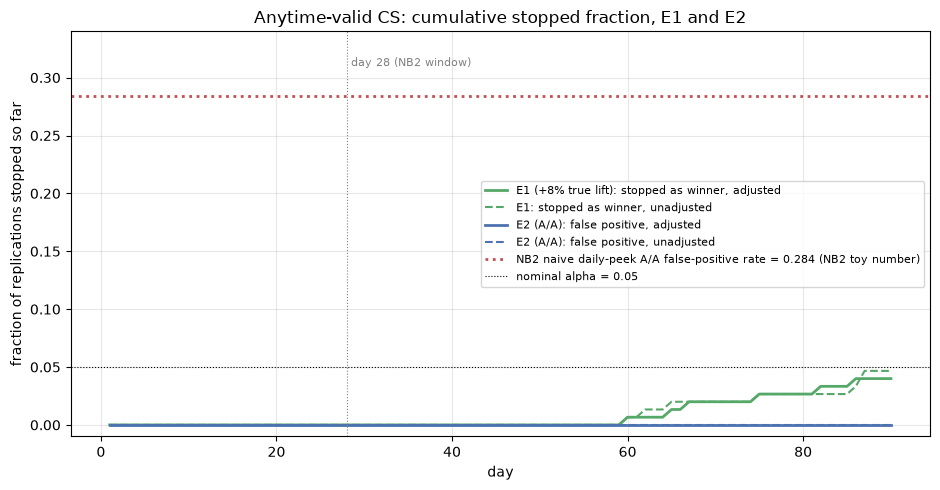

In [24]:
# Visualization only -- uses S3_CUM_E1_A, S3_CUM_E1_U, S3_CUM_E2_A, S3_CUM_E2_U, S3_DAYS, PALETTE
fig, ax = plt.subplots(figsize=(9.5, 5))
_days = np.arange(1, S3_DAYS + 1)
ax.plot(_days, S3_CUM_E1_A, color=PALETTE["winner"], lw=2, label="E1 (+8% true lift): stopped as winner, adjusted")
ax.plot(_days, S3_CUM_E1_U, color=PALETTE["winner"], lw=1.5, ls="--", label="E1: stopped as winner, unadjusted")
ax.plot(_days, S3_CUM_E2_A, color=PALETTE["control"], lw=2, label="E2 (A/A): false positive, adjusted")
ax.plot(_days, S3_CUM_E2_U, color=PALETTE["control"], lw=1.5, ls="--", label="E2 (A/A): false positive, unadjusted")
ax.axhline(0.284, color=PALETTE["naive_peek"], lw=2, ls=":", label="NB2 naive daily-peek A/A false-positive rate = 0.284 (NB2 toy number)")
ax.axhline(0.05, color="k", lw=0.8, ls=":", label="nominal alpha = 0.05")
ax.axvline(28, color="gray", lw=0.8, ls=":"); ax.text(28.5, 0.31, "day 28 (NB2 window)", fontsize=8, color="gray")
ax.set_ylim(-0.01, 0.34)
ax.set_xlabel("day"); ax.set_ylabel("fraction of replications stopped so far")
ax.set_title("Anytime-valid CS: cumulative stopped fraction, E1 and E2")
ax.legend(fontsize=8, loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 3.4 Claim: a CS on the guardrail metric can catch the E4 "clickbait" arm, and a CS on activation can see E3 (both derived here)

Nothing in the three papers defines guardrail monitoring, and Lindon et al. treat one outcome at a time. What the paper *does* give is a valid CS for **any** outcome that satisfies its conditions, so the natural derived-here use is one CS per metric. We use **activated-users-per-visitor** (activation within 7 days of signup, counted only once observed, right-censored at the look, section 3.2) for two reasons: it is randomisation-safe (every visitor is in the denominator, unlike "activation per signup", which conditions on a post-treatment variable that E4 itself moves), and it is exactly the metric E4's clickbait arm damages. Two CSs at once is a multiple-metric procedure the paper does not cover: we make **no** multiplicity claim, and each CS is a separate 95% statement.

Questions, on the same 150 replications:

- **E4** (true signup +10%, true activation -20%, so activated-users-per-visitor **-12%**, section 3.3 above): in what fraction does the *signup* CS declare a win by day 90? In what fraction does the *guardrail* CS flag harm (wholly below 0)? Of the replications where the signup CS declared the win first, how many had the guardrail already flagged, flagged it later, or never flagged it by day 90?
- **E3** (true signup 0, activation +15%): does the activation-per-visitor CS detect the effect by day 90, and does the signup CS wrongly declare a loser?
- If the guardrail is too weak at this traffic, we say so.


In [25]:
# [S3] (c) E4 guardrail and (d) E3 -- adjusted CSs, daily looks, 90 days. Derived here (binary outcomes; guardrail is right-censored).
_js, _jg = S3_IDX["E4_signup"], S3_IDX["E4_guard"]
_win_A, _win_U = S3_LO_A[:, :, _js] > 0, S3_LO_U[:, :, _js] > 0
_harm_A, _harm_U = S3_HI_A[:, :, _jg] < 0, S3_HI_U[:, :, _jg] < 0
S3_E4_WIN_DAY, S3_E4_HARM_DAY = s3_first_day(_win_A), s3_first_day(_harm_A)
S3_E4_WIN90, S3_E4_HARM90 = _win_A.any(1).mean(), _harm_A.any(1).mean()
print(f"[S3.26] NOTE E4 signup CS declares a positive win by day 90: adjusted {s3_rate(_win_A.any(1).sum(), S3_REPS)}; unadjusted {s3_rate(_win_U.any(1).sum(), S3_REPS)}; "
      f"NB2's naive daily peek 'won' E4 in 32.9% of replications")
print(f"[S3.27] NOTE E4 guardrail CS (activated-within-7d per visitor) excludes 0 on the harmful side by day 90: adjusted {s3_rate(_harm_A.any(1).sum(), S3_REPS)}; "
      f"unadjusted {s3_rate(_harm_U.any(1).sum(), S3_REPS)} (true matured effect {S3_TRUE['E4_guard']:.5f} per visitor = -12% of {S3_ACT7_CTRL:.5f})")
_winners = np.isfinite(S3_E4_WIN_DAY)
_already = _winners & np.isfinite(S3_E4_HARM_DAY) & (S3_E4_HARM_DAY <= S3_E4_WIN_DAY)
_later = _winners & np.isfinite(S3_E4_HARM_DAY) & (S3_E4_HARM_DAY > S3_E4_WIN_DAY)
_never = _winners & ~np.isfinite(S3_E4_HARM_DAY)
S3_E4_N_WIN, S3_E4_N_ALREADY, S3_E4_N_LATER, S3_E4_N_NEVER = int(_winners.sum()), int(_already.sum()), int(_later.sum()), int(_never.sum())
print(f"[S3.28] {_pass(S3_E4_N_ALREADY + S3_E4_N_LATER + S3_E4_N_NEVER == S3_E4_N_WIN)} of the {S3_E4_N_WIN} replications where the signup CS declared a win: "
      f"guardrail already flagged harm at or before that day in {S3_E4_N_ALREADY}, flagged it later (by day 90) in {S3_E4_N_LATER}, never flagged it by day 90 in {S3_E4_N_NEVER}")
print(f"[S3.29] NOTE a founder who ships on the first signup win with no guardrail flag yet would have shipped the harmful arm in "
      f"{S3_E4_N_LATER + S3_E4_N_NEVER}/{S3_REPS} = {(S3_E4_N_LATER + S3_E4_N_NEVER) / S3_REPS:.3f} of all replications ({S3_E4_N_LATER + S3_E4_N_NEVER}/{max(1, S3_E4_N_WIN)} of the wins)")
_hw90_g = float(np.median(S3_HA[:, -1, _jg]))
S3_E4G_N_NEEDED = s3_n_needed(S3_C_ADJ["E4_guard"], 8, abs(S3_TRUE["E4_guard"]))
print(f"[S3.30] NOTE guardrail power by day 90 = {S3_E4_HARM90:.3f} vs the conventional 0.80 target: UNDER-POWERED at this traffic. Median day-90 half-width {_hw90_g:.5f} vs |true effect| {abs(S3_TRUE['E4_guard']):.5f}. "
      f"Derived extrapolation (tau_hat = tau): the guardrail CS would exclude 0 at n ~ {S3_E4G_N_NEEDED:,.0f} visitors ~ {S3_E4G_N_NEEDED / S3_VIS_PER_DAY:,.0f} days")
# (d) E3
_ja3, _js3 = S3_IDX["E3_act"], S3_IDX["E3_signup"]
_det3_A, _det3_U = S3_LO_A[:, :, _ja3] > 0, S3_LO_U[:, :, _ja3] > 0
_los3_A = S3_HI_A[:, :, _js3] < 0
_win3_A = S3_LO_A[:, :, _js3] > 0
S3_E3_DETECT90 = _det3_A.any(1).mean()
print(f"[S3.31] NOTE E3 (+15% activation): activation-per-visitor CS (7-day metric) detects a positive effect by day 90 in adjusted {s3_rate(_det3_A.any(1).sum(), S3_REPS)}; "
      f"unadjusted {s3_rate(_det3_U.any(1).sum(), S3_REPS)} (true matured effect {S3_TRUE['E3_act']:.5f} per visitor); we use per visitor, not per signup, for the "
      f"post-treatment-conditioning reason in section 3.4")
S3_E3_LOSER90 = _los3_A.any(1).mean()
print(f"[S3.32] {_pass(S3_E3_LOSER90 <= S3_ALPHA + S3_SLACK)} E3 signup CS wrongly declares a loser (wholly below 0) at any look: {s3_rate(_los3_A.any(1).sum(), S3_REPS)} "
      f"(also wrongly declares a winner: {s3_rate(_win3_A.any(1).sum(), S3_REPS)}); NB2's naive signups-only peek wrongly dropped E3 in 13.8% of replications")
S3_E3_N_NEEDED = s3_n_needed(S3_C_ADJ["E3_act"], 8, S3_TRUE["E3_act"])
print(f"[S3.33] NOTE derived extrapolation for E3 (tau_hat = tau): activation CS would exclude 0 at n ~ {S3_E3_N_NEEDED:,.0f} visitors ~ {S3_E3_N_NEEDED / S3_VIS_PER_DAY:,.0f} days")
# curves and a representative E4 replication for plot 3: the replication with the earliest signup win (else the largest day-90 signup z)
S3_CUM_E4_WIN = np.maximum.accumulate(_win_A, axis=1).mean(0)
S3_CUM_E4_HARM = np.maximum.accumulate(_harm_A, axis=1).mean(0)
if _winners.any():
    S3_E4_REP = int(np.nanargmin(np.where(_winners, S3_E4_WIN_DAY, np.nan)))
    _why = f"the replication with the earliest signup win (day {int(S3_E4_WIN_DAY[S3_E4_REP])})"
else:
    _z = S3_TA[:, -1, _js] / (S3_HA[:, -1, _js] / 3.0)
    S3_E4_REP = int(np.argmax(_z)); _why = "no replication declared a win, so the one with the largest day-90 signup estimate"
def _fmt_day(x):
    return "never within 90 days" if not np.isfinite(x) else f"day {int(x)}"
if np.isfinite(S3_E4_WIN_DAY[S3_E4_REP]):
    _dd = int(S3_E4_WIN_DAY[S3_E4_REP]) - 1
    _ex_line = (f"on the 'ship it' day the signup estimate is {S3_TA[S3_E4_REP, _dd, _js]:+.4f} (true {S3_TRUE['E4_signup']:+.4f}) and the guardrail CS is "
                f"[{S3_LO_A[S3_E4_REP, _dd, _jg]:+.4f}, {S3_HI_A[S3_E4_REP, _dd, _jg]:+.4f}] (true matured effect {S3_TRUE['E4_guard']:+.4f})")
else:
    _ex_line = "no signup win in this replication"
print(f"[S3.34] NOTE plotted E4 example = replication {S3_E4_REP}: {_why}; signup CS first excludes 0: {_fmt_day(S3_E4_WIN_DAY[S3_E4_REP])}; guardrail CS first flags harm: {_fmt_day(S3_E4_HARM_DAY[S3_E4_REP])}; "
      f"{_ex_line}")


[S3.26] NOTE E4 signup CS declares a positive win by day 90: adjusted 18/150 = 0.120 (Wilson 95% [0.077, 0.182]); unadjusted 15/150 = 0.100 (Wilson 95% [0.062, 0.158]); NB2's naive daily peek 'won' E4 in 32.9% of replications
[S3.27] NOTE E4 guardrail CS (activated-within-7d per visitor) excludes 0 on the harmful side by day 90: adjusted 3/150 = 0.020 (Wilson 95% [0.007, 0.057]); unadjusted 3/150 = 0.020 (Wilson 95% [0.007, 0.057]) (true matured effect -0.00152 per visitor = -12% of 0.01270)
[S3.28] PASS of the 18 replications where the signup CS declared a win: guardrail already flagged harm at or before that day in 0, flagged it later (by day 90) in 0, never flagged it by day 90 in 18
[S3.29] NOTE a founder who ships on the first signup win with no guardrail flag yet would have shipped the harmful arm in 18/150 = 0.120 of all replications (18/18 of the wins)
[S3.30] NOTE guardrail power by day 90 = 0.020 vs the conventional 0.80 target: UNDER-POWERED at this traffic. Median day-90 ha

**How to read this chart (plot 3: E4, the signup CS against the guardrail CS).** *Left* -- the signup CS in the replication with the earliest signup win; *middle* -- the activated-within-7-days-per-visitor guardrail CS in the same replication; the dashed line is the true (matured) effect, the green vertical line the day the signup CS first excludes 0 (the day a founder using this rule would ship). What to look for: on that day the guardrail band is wide enough to contain zero *and* the true harm (the printed interval in [S3.34]); nothing in it tells the founder that activated users per visitor are falling 12%. Note also the signup estimate on the ship day is several times the true +0.0039 (the same winner's curse as [S3.19]). *Right* -- across all 150 replications, the cumulative fraction in which the signup CS declares a win (green) and the guardrail CS flags harm (red). What it means for the founder: anytime validity protects against false alarms; it does not create power. At about 270 visitors/day this guardrail is under-powered (2% detection by day 90, [S3.30], and none of the 18 signup "wins" had a guardrail flag by day 90, [S3.28]); a CS on a guardrail is only a safety net if the guardrail metric can actually be measured within the horizon.


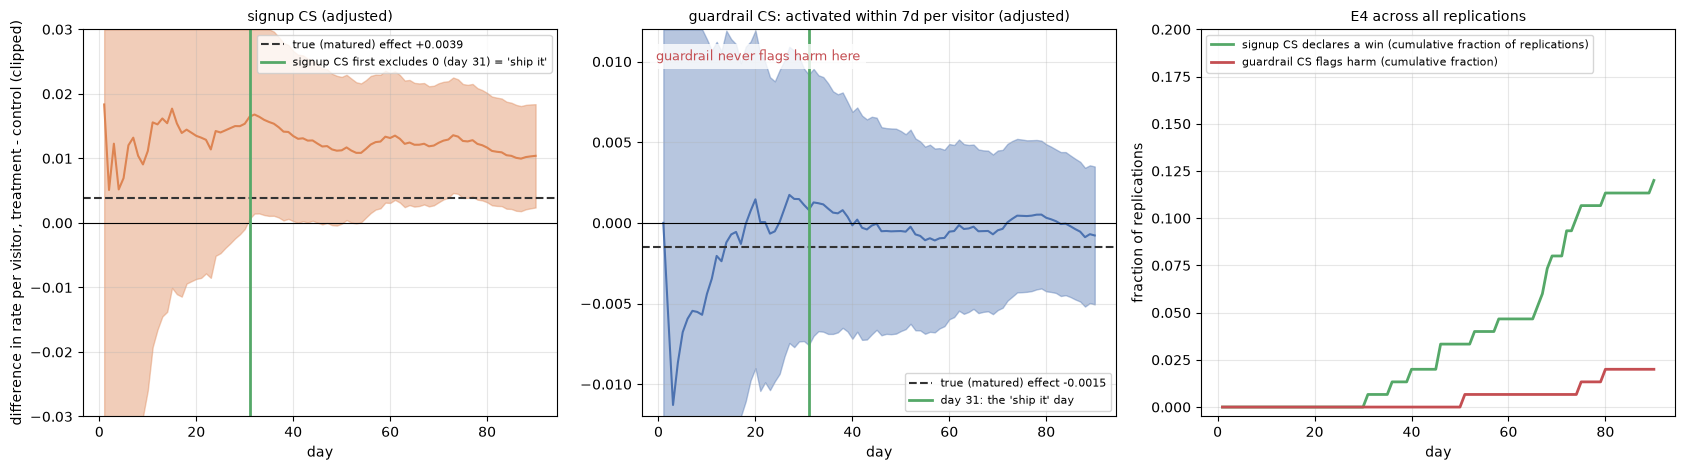

In [26]:
# Visualization only -- uses S3_LO_A, S3_HI_A, S3_TA, S3_E4_REP, S3_E4_WIN_DAY, S3_E4_HARM_DAY, S3_TRUE, S3_CUM_E4_WIN, S3_CUM_E4_HARM, S3_IDX, S3_DAYS, PALETTE
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
_days = np.arange(1, S3_DAYS + 1)
_r = S3_E4_REP
for ax, _key, _ttl, _clip, _col in ((axes[0], "E4_signup", "signup CS (adjusted)", 0.03, PALETTE["treatment"]),
                                     (axes[1], "E4_guard", "guardrail CS: activated within 7d per visitor (adjusted)", 0.012, PALETTE["control"])):
    _k = S3_IDX[_key]
    ax.fill_between(_days, np.clip(S3_LO_A[_r, :, _k], -_clip, _clip), np.clip(S3_HI_A[_r, :, _k], -_clip, _clip), color=_col, alpha=0.4)
    ax.plot(_days, np.clip(S3_TA[_r, :, _k], -_clip, _clip), color=_col, lw=1.5)
    _tr = S3_TRUE[_key]
    ax.axhline(_tr, color=PALETTE["truth"], ls="--", lw=1.5, label=f"true (matured) effect {_tr:+.4f}")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylim(-_clip, _clip); ax.set_xlabel("day"); ax.set_title(_ttl, fontsize=10); ax.grid(alpha=0.3)
_sw, _gh = S3_E4_WIN_DAY[_r], S3_E4_HARM_DAY[_r]
if np.isfinite(_sw):
    axes[0].axvline(_sw, color=PALETTE["winner"], lw=2, label=f"signup CS first excludes 0 (day {int(_sw)}) = 'ship it'")
    axes[1].axvline(_sw, color=PALETTE["winner"], lw=2, label=f"day {int(_sw)}: the 'ship it' day")
if np.isfinite(_gh):
    axes[1].axvline(_gh, color=PALETTE["loser"], lw=2, ls=":", label=f"guardrail flags harm (day {int(_gh)})")
else:
    axes[1].text(0.03, 0.92, "guardrail never flags harm here", transform=axes[1].transAxes, color=PALETTE["loser"], fontsize=9, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
axes[0].set_ylabel("difference in rate per visitor, treatment - control (clipped)")
axes[0].legend(fontsize=8, loc="upper right"); axes[1].legend(fontsize=8, loc="lower right")
ax = axes[2]
ax.plot(_days, S3_CUM_E4_WIN, color=PALETTE["winner"], lw=2, label="signup CS declares a win (cumulative fraction of replications)")
ax.plot(_days, S3_CUM_E4_HARM, color=PALETTE["loser"], lw=2, label="guardrail CS flags harm (cumulative fraction)")
ax.set_xlabel("day"); ax.set_ylabel("fraction of replications"); ax.set_ylim(-0.005, max(0.2, 1.3 * max(S3_CUM_E4_WIN.max(), S3_CUM_E4_HARM.max())))
ax.set_title("E4 across all replications", fontsize=10); ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 3.5 Claim: the CS also gives a stopping rule for "nothing worth shipping here" (futility), and four honest outcome classes

The paper's advice on when to stop a null experiment (q4): *"conclude the experiment once the interval narrows sufficiently around zero to rule out all practically meaningful effect sizes"*, while noting that although the sequential test has power 1 the authors *"warn against running experiments indefinitely"* (q4). We turn that into a rule (derived here): **futile** when the whole CS lies inside +-delta, with delta the +10% relative MDE in absolute terms (signup: 0.004; for the activation metrics: 10% of the control's matured activated-within-7d rate). We also classify every replication by the *first* thing its adjusted CS did within 90 days: **winner** (CS wholly above 0), **harmful** (wholly below 0), **futile** (inside +-delta), or **inconclusive** (none of these yet). If the CS is simultaneously wholly above 0 and inside +-delta the statistically significant reading wins the tie. **Inconclusive is not an error**: it is the CS saying "not enough evidence yet", and it never claims a false result.


In [27]:
# [S3] (e) Futility rule and outcome classes. Derived here (the rule is our translation of the q4 advice).
S3_DELTA = {s: (S3_MDE_ABS if s.endswith("signup") else S3_MDE_REL * S3_ACT7_CTRL) for s in S3_STREAMS}
_lo2, _hi2 = S3_LO_A[:, :, _j2], S3_HI_A[:, :, _j2]
_lo2u, _hi2u = S3_LO_U[:, :, _j2], S3_HI_U[:, :, _j2]
_fut_A = (_lo2 > -S3_DELTA["E2_signup"]) & (_hi2 < S3_DELTA["E2_signup"])
_fut_U = (_lo2u > -S3_DELTA["E2_signup"]) & (_hi2u < S3_DELTA["E2_signup"])
S3_E2_FUT90 = _fut_A.any(1).mean()
_fut_day = s3_first_day(_fut_A)
print(f"[S3.35] NOTE E2 (A/A) futility: CS wholly inside +-{S3_DELTA['E2_signup']:.4f} at some look by day 90 in adjusted {s3_rate(_fut_A.any(1).sum(), S3_REPS)}; "
      f"unadjusted {s3_rate(_fut_U.any(1).sum(), S3_REPS)}; at day 90 the median adjusted half-width is {np.median(S3_HA[:, -1, _j2]):.5f}")
S3_E2_FUT_N = s3_n_needed(S3_C_ADJ["E2_signup"], 8, S3_DELTA["E2_signup"])
print(f"[S3.36] NOTE derived extrapolation (rse*sqrt(n) held at its day-90 value): the adjusted CS half-width reaches +-{S3_DELTA['E2_signup']:.4f} at n ~ {S3_E2_FUT_N:,.0f} visitors "
      f"~ {S3_E2_FUT_N / 2:,.0f} per arm ~ {S3_E2_FUT_N / S3_VIS_PER_DAY:,.0f} days at {S3_VIS_PER_DAY:,.0f} visitors/day, so futility is not a usable rule on this traffic within a quarter")

def s3_classify(lo, hi, delta):
    """First-event class per replication: 0 winner, 1 harmful, 2 futile, 3 inconclusive (winner/harmful take priority over futile)."""
    win, harm, fut = lo > 0, hi < 0, (lo > -delta) & (hi < delta)
    ev = win | harm | fut
    first = ev.argmax(axis=1); has = ev.any(axis=1)
    rows = np.arange(lo.shape[0])
    cls = np.where(win[rows, first], 0, np.where(harm[rows, first], 1, 2))
    return np.where(has, cls, 3)

S3_CLASS_NAMES = ["winner", "harmful", "futile", "inconclusive"]
S3_CLASS_FRAC, S3_CLASS_COUNT = {}, {}
print("[S3.37] NOTE outcome classes by day 90, adjusted CS (counts out of %d; first event within 90 daily looks):" % S3_REPS)
print(f"    {'stream':10s} {'true ATE':>10s}  " + "  ".join(f"{c:>12s}" for c in S3_CLASS_NAMES))
for _s in S3_STREAMS:
    _k = S3_IDX[_s]
    _cls = s3_classify(S3_LO_A[:, :, _k], S3_HI_A[:, :, _k], S3_DELTA[_s])
    S3_CLASS_COUNT[_s] = np.array([(_cls == c).sum() for c in range(4)])
    S3_CLASS_FRAC[_s] = S3_CLASS_COUNT[_s] / S3_REPS
    print(f"    {_s:10s} {S3_TRUE[_s]:>+10.5f}  " + "  ".join(f"{int(S3_CLASS_COUNT[_s][c]):>4d} ({S3_CLASS_FRAC[_s][c]:.2f})".rjust(12) for c in range(4)))
print(f"[S3.38] {_pass(all(int(S3_CLASS_COUNT[s].sum()) == S3_REPS for s in S3_STREAMS))} every replication lands in exactly one class for every stream (classes partition the {S3_REPS} replications)")
_e2_err = int(S3_CLASS_COUNT['E2_signup'][0] + S3_CLASS_COUNT['E2_signup'][1])
print(f"[S3.39] {_pass(_e2_err / S3_REPS <= S3_ALPHA + S3_SLACK)} on the A/A the 'winner' + 'harmful' classes (the only errors) total {s3_rate(_e2_err, S3_REPS)}; "
      f"all other A/A replications are futile or inconclusive, and inconclusive is not an error")


[S3.35] NOTE E2 (A/A) futility: CS wholly inside +-0.0040 at some look by day 90 in adjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]); unadjusted 0/150 = 0.000 (Wilson 95% [0.000, 0.025]); at day 90 the median adjusted half-width is 0.00792
[S3.36] NOTE derived extrapolation (rse*sqrt(n) held at its day-90 value): the adjusted CS half-width reaches +-0.0040 at n ~ 85,341 visitors ~ 42,670 per arm ~ 320 days at 267 visitors/day, so futility is not a usable rule on this traffic within a quarter
[S3.37] NOTE outcome classes by day 90, adjusted CS (counts out of 150; first event within 90 daily looks):
    stream       true ATE        winner       harmful        futile  inconclusive
    E1_signup    +0.00310      6 (0.04)      0 (0.00)      0 (0.00)    144 (0.96)
    E2_signup    +0.00000      0 (0.00)      0 (0.00)      0 (0.00)    150 (1.00)
    E3_signup    +0.00000      3 (0.02)      0 (0.00)      0 (0.00)    147 (0.98)
    E4_signup    +0.00388     18 (0.12)      0 (0.00)      0 (0.0

**How to read this chart (plot 4: outcome classes at 90 days).** Each row is one metric stream from one experiment (E1-E4, `signup` = signup rate per visitor, `act`/`guard` = activated-within-7d per visitor; the label shows the true ATE); the bar shows the fraction of the 150 replications whose adjusted CS *first* did each thing within 90 daily looks: winner (green, CS wholly above 0), harmful (red, wholly below 0), futile (blue, wholly inside +-delta) or inconclusive (tan). What to look for: how much of every bar is tan, and whether any red or green appears on rows whose true effect is zero. The A/A row (E2_signup) is entirely tan and E3_signup (true effect 0) shows only a small green sliver of false positives; E4_guard and E2_guard show the small red slices. What it means for the founder: at this traffic the honest result of a 90-day CS is "inconclusive" in the large majority of cases (about 88-100% of replications for every stream) and inconclusive is not a failure or a false claim; it is the CS declining to say something it cannot back up. No stream ever reaches "futile" because the band never gets narrower than +-0.004 in 90 days ([S3.35]).


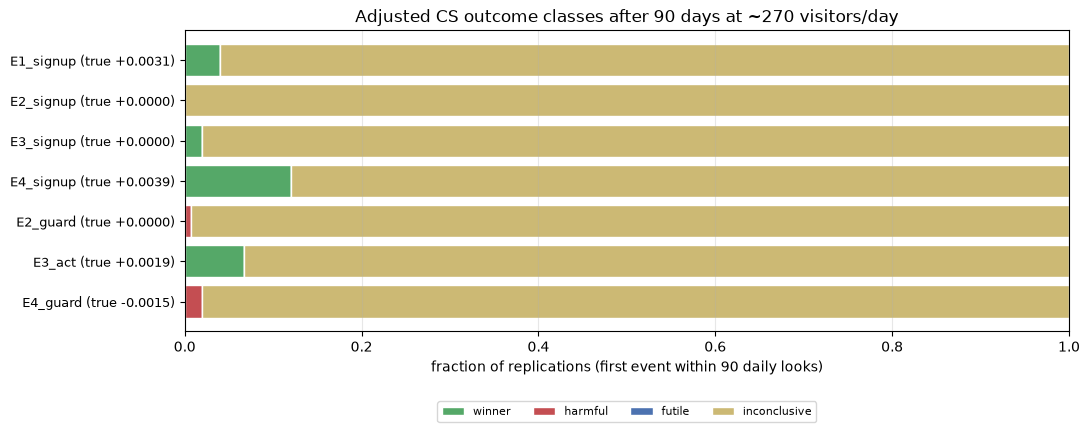

In [28]:
# Visualization only -- uses S3_CLASS_FRAC, S3_CLASS_NAMES, S3_STREAMS, S3_TRUE, PALETTE
fig, ax = plt.subplots(figsize=(11, 4.6))
_cols = [PALETTE["winner"], PALETTE["loser"], PALETTE["control"], PALETTE["inconclusive"]]
_left = np.zeros(len(S3_STREAMS))
for _c, (_nm, _col) in enumerate(zip(S3_CLASS_NAMES, _cols)):
    _vals = np.array([S3_CLASS_FRAC[s][_c] for s in S3_STREAMS])
    ax.barh(range(len(S3_STREAMS)), _vals, left=_left, color=_col, label=_nm, edgecolor="white")
    _left += _vals
ax.set_yticks(range(len(S3_STREAMS)))
ax.set_yticklabels([f"{s} (true {S3_TRUE[s]:+.4f})" for s in S3_STREAMS], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("fraction of replications (first event within 90 daily looks)")
ax.set_title("Adjusted CS outcome classes after 90 days at ~270 visitors/day")
ax.legend(fontsize=8, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.32)); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()


### 3.6 Paper numbers, kept separate from our toy numbers, and the summary handed to the next sections

**Paper numbers (Lindon et al., quoted from q4/q11; not ours).** Gaussian outcomes, alpha = 0.01, MDE xi = 0.2, fixed-n sample size n* = 1785, 10^4 simulations: null rejections *1.07% (fixed-n) vs 0.04% (anytime-valid, g = 100)*; power at n* *95.02% (fixed-n) vs 81.69% (anytime-valid)* with mean stopping time *1,214.45*; at xi = 0.4 the mean stopping time is *350.37*, *"less than 20% of the sample size"* of the fixed-n test (q4). **Our toy numbers** (above) are binary outcomes, alpha = 0.05, daily looks, and effects far below a standardised 0.2; the two sets are not comparable in size, only in *direction*: anytime-valid procedures reject far less than nominal under the null and pay for it in power at a fixed horizon.


In [29]:
# [S3] Paper numbers (q4, q11) printed on their own, then the summary published for later sections.
_paper = {"alpha": 0.01, "n_star": 1785, "xi_MDE": 0.2, "sims": 10_000, "fixed_null_rej": 0.0107, "av_null_rej_g100": 0.0004,
          "fixed_power": 0.9502, "av_power_g100": 0.8169, "av_mean_stop_xi_MDE": 1214.45, "av_mean_stop_2xi": 350.37}
print(f"[S3.40] NOTE PAPER (q4, not toy): alpha={_paper['alpha']}, n*={_paper['n_star']}, xi_MDE={_paper['xi_MDE']}, {_paper['sims']:,} sims: null rejections fixed-n {_paper['fixed_null_rej']:.2%} vs anytime-valid {_paper['av_null_rej_g100']:.2%}; "
      f"power at n* {_paper['fixed_power']:.2%} vs {_paper['av_power_g100']:.2%} (mean stopping time {_paper['av_mean_stop_xi_MDE']}); at 2*xi_MDE mean stopping time {_paper['av_mean_stop_2xi']} "
      f"= {_paper['av_mean_stop_2xi'] / _paper['n_star']:.1%} of n* (NB1 already reproduced ~0.818 power in its [S2.6])")
print(f"[S3.41] NOTE TOY (ours, binary outcomes, alpha=0.05, {S3_REPS} replications, 90 daily looks): A/A time-uniform false-positive rate adjusted {S3_E2_FPR_A:.3f}, unadjusted {S3_E2_FPR_U:.3f} "
      f"vs nominal {S3_ALPHA} -- like the paper's 0.04%-vs-1.07% pattern, far below nominal; E1 stopped by day 90: {S3_E1_BY90_A:.3f}")
MEASURE_SUMMARY = {
    "g": round(float(S3_G), 6),
    "delayed_start_min_n": S3_NMIN_ADJ,
    "E2_fpr_adj": float(S3_E2_FPR_A),
    "E2_fpr_unadj": float(S3_E2_FPR_U),
    "E1_stopped_by_28_adj": float(S3_E1_BY28_A),
    "E1_stopped_by_90_adj": float(S3_E1_BY90_A),
    "E1_stopped_by_90_unadj": float(S3_E1_BY90_U),
    "E1_median_stop_day_adj": S3_E1_MED_A,
    "E1_median_stop_day_unadj": S3_E1_MED_U,
    "E1_width_ratio": S3_E1_WIDTH_RATIO,
    "E4_signup_win_by_90": float(S3_E4_WIN90),
    "E4_guardrail_harm_by_90": float(S3_E4_HARM90),
    "E3_detect_by_90": float(S3_E3_DETECT90),
    "E2_futile_by_90": float(S3_E2_FUT90),
    "n_reps": S3_REPS,
}
print("MEASURE_SUMMARY =")
for _k, _v in MEASURE_SUMMARY.items():
    print(f"    {_k:26s} {_v}")
print(f"[S3.42] {_pass(all(k in MEASURE_SUMMARY for k in ['g','delayed_start_min_n','E2_fpr_adj','E2_fpr_unadj','E1_stopped_by_28_adj','E1_stopped_by_90_adj','E1_stopped_by_90_unadj','E1_median_stop_day_adj','E1_median_stop_day_unadj','E1_width_ratio','E4_signup_win_by_90','E4_guardrail_harm_by_90','E3_detect_by_90','E2_futile_by_90','n_reps']))} "
      f"MEASURE_SUMMARY published with all 15 required keys; section 3 total Monte Carlo runtime {S3_RUNTIME:.0f}s, zero DeepSeek calls")


[S3.40] NOTE PAPER (q4, not toy): alpha=0.01, n*=1785, xi_MDE=0.2, 10,000 sims: null rejections fixed-n 1.07% vs anytime-valid 0.04%; power at n* 95.02% vs 81.69% (mean stopping time 1214.45); at 2*xi_MDE mean stopping time 350.37 = 19.6% of n* (NB1 already reproduced ~0.818 power in its [S2.6])
[S3.41] NOTE TOY (ours, binary outcomes, alpha=0.05, 150 replications, 90 daily looks): A/A time-uniform false-positive rate adjusted 0.000, unadjusted 0.000 vs nominal 0.05 -- like the paper's 0.04%-vs-1.07% pattern, far below nominal; E1 stopped by day 90: 0.040
MEASURE_SUMMARY =
    g                          9600.0
    delayed_start_min_n        246
    E2_fpr_adj                 0.0
    E2_fpr_unadj               0.0
    E1_stopped_by_28_adj       0.0
    E1_stopped_by_90_adj       0.04
    E1_stopped_by_90_unadj     0.04666666666666667
    E1_median_stop_day_adj     71.0
    E1_median_stop_day_unadj   75.0
    E1_width_ratio             0.996205385618773
    E4_signup_win_by_90        0.1

### 3.7 What section 3 established, and what it does not

**Established on this synthetic, low-traffic world (derived-here checks, 150 replications each, so a rate of 0/150 only bounds the true rate below about 2.5%).**
- The anytime-valid CS did what the paper promises about false alarms, on *binary* outcomes the paper did not simulate: the A/A never stopped in 90 daily looks (adjusted and unadjusted, [S3.11]), coverage of the true E1 effect held ([S3.21]), and the sign was never wrong ([S3.20]). NB2's daily-peek habit had a 0.284 false-positive rate on the same kind of world.
- The price is power and patience: E1's +8% lift stopped in a handful of replications, none before about day 60 ([S3.16]-[S3.18]); at the estimated width the CS needs on the order of 1.2x NB2's fixed-horizon sample ([S3.24]); a futility call needs roughly a year of traffic ([S3.36]); and the E4 guardrail is under-powered ([S3.30]), so the CS did not stop the clickbait arm from looking like a win ([S3.28]-[S3.29]).
- Regression adjustment was harmless and nearly useless on a 4% conversion metric with three weak covariates ([S3.22]-[S3.23]).

**Not established.** Anything beyond fixed 50/50 assignment with i.i.d. units (no source combines regression adjustment with adaptive assignment, q12, so section 4's MAD uses its own IPW-based CS instead); non-stationarity, novelty effects and many experiments over time (no guarantee from the sources, q12); the multiple-metric use (signup CS plus guardrail CS) has no multiplicity control; the right-censored guardrail metric violates the i.i.d.-units condition mildly and was only checked empirically ([S3.14]); and the CS is asymptotic in Sections 5-6, so exact validity at a few hundred units is the paper's delayed-start protection plus our simulation, not a theorem for binary data. Sections 4-6 read `MEASURE_SUMMARY` printed above.


## 4. Iterate: MAD across the screened slate (Liang & Bojinov, arXiv:2311.05794; q5, q6, q11)

**What the paper gives us.** The Mixture Adaptive Design mixes a bandit with a coin-flip so that the bandit can shift traffic to winners while the inference stays valid: *"the probability that the MAD will assign treatment w at time t is: p_t^MAD(w) := P_MAD(W_t = w | H_{t-1}) = delta_t (1/2) + (1 - delta_t) p_t^A(w)"* (Definition 4, q5). For more than two arms the paper's Appendix C gives the K-arm form *"p_i^MAD(w) = delta_i (1/K) + (1 - delta_i) p_i^A(w)"* with the pairwise IPW estimator *"tau_hat_i(w, w') = 1{W_i = w} Y_i(w) / p_i^MAD(w) - 1{W_i = w'} Y_i(w') / p_i^MAD(w')"* and variance estimator *"sigma_hat_i^2(w, w') = Y_i(w)^2 1{W_i = w} / (p_i^MAD(w))^2 + Y_i(w')^2 1{W_i = w'} / (p_i^MAD(w'))^2"* (q6, Appendix C). The guarantee is Theorem 1 (q5): with *"V_hat_t = sqrt( 2 (S_hat_t eta^2 + 1) / (t^2 eta^2) * log( sqrt(S_hat_t eta^2 + 1) / alpha ) )"*, *"under Assumptions 1 and 2 and setting delta_t = omega(1/t^{1/4}), (tau_bar_hat_t +/- V_hat_t) is a valid (1 - alpha) asymptotic CS for tau_bar_t"*. Two limits the paper states itself: *"The main CS is asymptotic"* (q6, stated limitations) and Assumption 2 (cumulative conditional variances grow at least linearly) can be violated (q6). The recommended eta is *"eta = sqrt( (-2 log(alpha) + log(-2 log(alpha) + 1)) / t* )"* with *"t* as the end of the time horizon we set for this experiment"* (q5).

**What this section does with it -- the "iterate" step of screen -> measure -> iterate.** Section 2 produced three 3-headline slates (screened, random, oracle) out of the 18 generated headlines. Here the founder keeps a control and runs a **K = 4-arm MAD** (control + 3 challengers) for **60 days at 300 visitors/day (18,000 units)** and we ask, arm by arm, exactly what the paper's guarantee does and does not deliver on this small, low-conversion problem.

**Design choices, each labelled.**

| Choice | Value | Source |
|---|---|---|
| Assignment law | p_t(w) = delta_t/K + (1 - delta_t) p_t^A(w), K = 4 | q6 Appendix C |
| Bandit A | Beta(1,1) Thompson sampling; p_t^A(w) = share of 1,000 Monte-Carlo posterior draws in which arm w has the highest draw | q6 (Thompson sampling with Beta(1,1) priors) ; Monte-Carlo p^A is a **derived-here** implementation choice (NB1 used a normal approximation) |
| Batching | p_t^A and delta_j recomputed once per **day** (batch = 300 units); assignment probabilities are fixed within the day; delta_j = delta evaluated at the day's first unit | q6 Appendix D (batched MAD: probabilities fixed across the batch). The trace prints the batched *estimator* but not a batched V_hat, so we use the **per-unit IPW form with p fixed within the day** (the general form of Appendix C) and check the CS at **every unit**, not only at day boundaries |
| Pairwise estimator | tau_hat(w,0), Ŝ_t(w,0), V_hat_t as printed above, alpha = 0.05, eta from the q5 formula with t* = N = 18,000 | q5, q6 |
| delta designs | Bernoulli (delta = 1); unclipped t^-0.24; clipped max(t^-0.24, c) with c = 1/N^0.24, N = planned units (q6 Example 3); plus the paper's own simulation clip c = 0.2 as an extra design | q6 Section 6, Section 7 |
| Truth | each arm's signup probability is `true_p_of(text)` from Section 2 (the notebook's latent truth). Control = the historical headline with the **highest observed signup rate** (what a founder would keep as the champion) | **derived here** |
| Data-generating shortcut | units arrive as independent Bernoulli(true rate) draws, no unit-level covariates, no day-of-week effect | **derived here** |
| Slates | screened top-3, random-3, oracle top-3 from Section 2 | Section 2 |

**What is deliberately not claimed.** No source defines a covariate-adjusted MAD, so nothing here uses covariates (rule: MAD CS uses the IPW estimator only). The paper's pairwise CSs are each marginal (1 - alpha) -- it gives no multiplicity correction across the three challenger-vs-control comparisons, and (q12, quoted in Section 2) *"No source states or proves a formal guarantee for a two-stage pipeline where an LLM screens out arms prior to a MAD trial"*. So everything below about the screened slate is a **practical, simulated** result, not a guaranteed one; all designs are **simulations** with a known truth, not production experience.


In [30]:
# [S4] Setup: control (the champion a founder would keep), the three slates, and what each slate is worth
# on truth alone (no simulation). Everything here is derived here from Section 2's latent truth.
import itertools

_ctrl_idx = int(np.argmax(p0_Y))                      # highest OBSERVED signup rate among the 24 historical headlines
CONTROL_TEXT = p0_texts[_ctrl_idx]
CONTROL_P = float(p0_true_p[_ctrl_idx])
SLATES = {
    "screened": [true_p_of(t) for t in screened_top3],
    "random":   [true_p_of(t) for t in random3],
    "oracle":   [true_p_of(t) for t in oracle_top3],
}
SLATE_TEXTS = {"screened": list(screened_top3), "random": list(random3), "oracle": list(oracle_top3)}
SLATE_NAMES = ["screened", "random", "oracle"]

_rank_true_hist = int((p0_true_p > CONTROL_P).sum()) + 1
_n_p1_above = int((p1_true_p > CONTROL_P).sum())
print(f"[S4.1] NOTE control = highest observed_signup_rate historical headline: {CONTROL_TEXT!r}; observed rate "
      f"{p0_Y[_ctrl_idx]:.4f} (n_shown=1500), TRUE signup probability {CONTROL_P:.4f} "
      f"(rank {_rank_true_hist} of {len(p0_texts)} historical headlines by true p; "
      f"{_n_p1_above} of the {len(p1_true_p)} generated P=1 headlines have a true p above it)")
for name in SLATE_NAMES:
    lifts = [p - CONTROL_P for p in SLATES[name]]
    print(f"[S4.2-{name}] NOTE {name} slate true p = {[round(p, 4) for p in SLATES[name]]}; true ATE vs control "
          f"= {[round(x, 4) for x in lifts]} ({sum(x > 0 for x in lifts)} of 3 challengers beat the control); "
          f"headlines: {SLATE_TEXTS[name]}")

# Slate value on truth alone, against ALL 816 possible 3-subsets of the 18 P=1 headlines (exhaustive, no sampling)
_all_sub = list(itertools.combinations(range(len(p1_true_p)), 3))
_best_p = np.array([max(p1_true_p[list(s)]) for s in _all_sub])
_mean_p = np.array([np.mean(p1_true_p[list(s)]) for s in _all_sub])
_contains_beater = np.array([any(p1_true_p[i] > CONTROL_P for i in s) for s in _all_sub])
def _pct(arr, v):
    return 100.0 * float((arr < v).mean() + 0.5 * (arr == v).mean())
for name in SLATE_NAMES:
    bp, mp = max(SLATES[name]), float(np.mean(SLATES[name]))
    print(f"[S4.3-{name}] NOTE {name}: best challenger p = {bp:.4f} (percentile among all {len(_all_sub)} possible "
          f"3-slates: {_pct(_best_p, bp):.0f}), mean challenger p = {mp:.4f} (percentile {_pct(_mean_p, mp):.0f})")
_beater_pos = [screened_top3.index(t) + 1 for t in screened_top3 if true_p_of(t) > CONTROL_P]
print(f"[S4.4] NOTE {int(_contains_beater.sum())} of {len(_all_sub)} possible 3-slates ({_contains_beater.mean():.3f}) contain a "
      f"challenger whose true p beats the control; the screened slate {'does' if _beater_pos else 'does NOT'} "
      f"(its screen rank(s) among the top-3: {_beater_pos}). Spearman rho of the screen (Section 2) = {spearman_rho:.3f}, "
      f"calibrator = {SCREEN_CALIBRATOR}. This is ONE screened slate and ONE random slate -- a single draw each.")


[S4.1] NOTE control = highest observed_signup_rate historical headline: 'Fix 500 broken links in one afternoon'; observed rate 0.1013 (n_shown=1500), TRUE signup probability 0.0994 (rank 1 of 24 historical headlines by true p; 1 of the 18 generated P=1 headlines have a true p above it)
[S4.2-screened] NOTE screened slate true p = [0.0607, 0.1157, 0.0676]; true ATE vs control = [-0.0386, 0.0163, -0.0317] (1 of 3 challengers beat the control); headlines: ['Cut Redirect Errors by 90% After a Site Migration', 'Fix Broken Links in 2 Clicks, Not 2 Weeks', 'Fix Every Broken Link Before It Hurts You']
[S4.2-random] NOTE random slate true p = [0.0689, 0.0483, 0.0607]; true ATE vs control = [-0.0305, -0.0511, -0.0386] (0 of 3 challengers beat the control); headlines: ['Protect Your Rankings in 48 Hours or Less', 'Protect Your Rankings Before They Slip', 'Cut Redirect Errors by 90% After a Site Migration']
[S4.2-oracle] NOTE oracle slate true p = [0.1157, 0.0859, 0.0749]; true ATE vs control = [0

In [31]:
# [S4] The K-arm batched MAD simulator. The V_hat_t / eta handling is COPIED from NB1's simulate_mad
# (NB1 cell 20: V_hat = sqrt(2 (S eta^2 + 1) / (t^2 eta^2) * log(sqrt(S eta^2 + 1) / alpha)), Y^2 1{W=w} / p^2 variance
# terms) and generalised (pairwise (w,0) sums over K arms, daily-fixed assignment probabilities, Monte-Carlo p^A).
ALPHA4 = 0.05
N_DAYS, PER_DAY = 60, 300
T_UNITS = N_DAYS * PER_DAY                 # planned total units = 18,000
N_PLAN = T_UNITS                           # N in c = 1/N^0.24 (q6 Ex. 3) and t* in eta (q5)
MC_DRAWS = 1000                            # Monte-Carlo posterior draws for p_t^A per day
K_ARMS = 4
REPS4 = 300

def eta_q5(t_star, alpha=ALPHA4):
    return math.sqrt((-2 * math.log(alpha) + math.log(-2 * math.log(alpha) + 1)) / t_star)
ETA4 = eta_q5(N_PLAN)

DELTA_FNS = {
    "bernoulli":    lambda t: 1.0,
    "unclipped":    lambda t: t ** -0.24,
    "clipped":      lambda t: max(t ** -0.24, N_PLAN ** -0.24),     # c = 1/N^0.24 (q6 Example 3)
    "clipped_c0.2": lambda t: max(t ** -0.24, 0.2),                # the clip used in the paper's own simulations (q6)
}
SIM_DESIGNS = ["bernoulli", "unclipped", "clipped_c0.2"]          # "clipped" is checked to be identical to "unclipped" below

def simulate_mad_k(p_arm, design, reps, seed, target_const=None, const_from_day=1, record_rep0=False):
    """K-arm batched MAD, batch = 1 day. p_arm: (K,) constant or (n_days, K) daily true rates; arm 0 = control.
    Returns per-replication reductions computed at EVERY unit t (time-uniform), plus day-end records."""
    delta_fn = DELTA_FNS[design]
    rng = np.random.default_rng(seed)
    p_arm = np.asarray(p_arm, dtype=float)
    P = np.tile(p_arm, (N_DAYS, 1)) if p_arm.ndim == 1 else p_arm
    K = P.shape[1]; C = K - 1
    succ = np.ones((reps, K)); fail = np.ones((reps, K))                 # Beta(1,1) priors
    A = np.zeros((reps, K)); Sq = np.zeros((reps, K))                    # running IPW sums / variance sums per arm
    cum_true_eff = np.zeros(C)
    ever_miss_run = np.zeros((reps, C), bool); ever_miss_const = np.zeros((reps, C), bool)
    stop_unit = np.full((reps, C), T_UNITS + 1, dtype=np.int64); stop_sign = np.zeros((reps, C), dtype=np.int8)
    day_signups = np.zeros((N_DAYS, reps)); day_counts = np.zeros((N_DAYS, reps, K), dtype=np.int32)
    day_pA = np.zeros((N_DAYS, reps, K)); day_pMAD = np.zeros((N_DAYS, reps, K)); day_delta = np.zeros(N_DAYS)
    day_tau = np.zeros((N_DAYS, reps, C)); day_V = np.zeros((N_DAYS, reps, C)); day_target = np.zeros((N_DAYS, C))
    rep0_tau = np.zeros((T_UNITS, C)) if record_rep0 else None
    rep0_V = np.zeros((T_UNITS, C)) if record_rep0 else None
    for d in range(N_DAYS):
        t0 = d * PER_DAY
        delta = float(delta_fn(t0 + 1))                                  # delta_j for this batch (first unit of the day)
        if delta >= 1.0:
            pA = np.full((reps, K), 1.0 / K)                             # Bernoulli design: bandit not consulted
        else:
            draws = rng.beta(succ[:, None, :], fail[:, None, :], size=(reps, MC_DRAWS, K))
            winner = np.argmax(draws, axis=2) + K * np.arange(reps)[:, None]
            pA = np.bincount(winner.ravel(), minlength=reps * K).reshape(reps, K) / MC_DRAWS
        pM = delta / K + (1 - delta) * pA                                # generalized MAD (q6 Appendix C)
        cum = np.cumsum(pM, axis=1)
        W = (rng.random((reps, PER_DAY))[:, :, None] >= cum[:, None, :K - 1]).sum(axis=2)
        Y = (rng.random((reps, PER_DAY)) < P[d][W]).astype(float)
        a_terms = np.zeros((reps, PER_DAY, K)); s_terms = np.zeros((reps, PER_DAY, K))
        for w in range(K):
            ind = (W == w) * Y
            a_terms[:, :, w] = ind / pM[:, w, None]                      # 1{W=w} Y / p(w)
            s_terms[:, :, w] = ind / pM[:, w, None] ** 2                 # Y^2 1{W=w} / p(w)^2  (Y is binary)
        Acum = A[:, None, :] + np.cumsum(a_terms, axis=1)
        Scum = Sq[:, None, :] + np.cumsum(s_terms, axis=1)
        t_vec = t0 + np.arange(1, PER_DAY + 1)
        eff = P[d, 1:] - P[d, 0]                                         # per-unit true effect of each challenger today
        run_target = (cum_true_eff[None, :] + np.cumsum(np.tile(eff, (PER_DAY, 1)), axis=0)) / t_vec[:, None]  # running sample ATE
        tau_bar = (Acum[:, :, 1:] - Acum[:, :, [0]]) / t_vec[None, :, None]
        S_hat = Scum[:, :, 1:] + Scum[:, :, [0]]                         # S_hat_t(w, 0)
        V = np.sqrt(2 * (S_hat * ETA4**2 + 1) / (t_vec[None, :, None]**2 * ETA4**2)
                    * np.log(np.sqrt(S_hat * ETA4**2 + 1) / ALPHA4))
        ever_miss_run |= (np.abs(tau_bar - run_target[None]) > V).any(axis=1)
        if target_const is not None and d + 1 >= const_from_day:
            ever_miss_const |= (np.abs(tau_bar - np.asarray(target_const)[None, None, :]) > V).any(axis=1)
        excl = np.abs(tau_bar) > V                                       # CS excludes 0
        first = np.argmax(excl, axis=1); has = excl.any(axis=1)
        newly = has & (stop_unit > T_UNITS)
        if newly.any():
            r_idx, c_idx = np.where(newly)
            stop_unit[r_idx, c_idx] = t0 + first[r_idx, c_idx] + 1
            stop_sign[r_idx, c_idx] = np.sign(tau_bar[r_idx, first[r_idx, c_idx], c_idx]).astype(np.int8)
        A = Acum[:, -1, :].copy(); Sq = Scum[:, -1, :].copy(); cum_true_eff = cum_true_eff + eff * PER_DAY
        n_w = np.stack([(W == w).sum(axis=1) for w in range(K)], axis=1)
        s_w = np.stack([((W == w) * Y).sum(axis=1) for w in range(K)], axis=1)
        succ += s_w; fail += n_w - s_w
        day_signups[d] = s_w.sum(axis=1); day_counts[d] = n_w; day_pA[d] = pA; day_pMAD[d] = pM; day_delta[d] = delta
        day_tau[d] = tau_bar[:, -1, :]; day_V[d] = V[:, -1, :]; day_target[d] = run_target[-1]
        if record_rep0:
            rep0_tau[t0:t0 + PER_DAY] = tau_bar[0]; rep0_V[t0:t0 + PER_DAY] = V[0]
    return dict(P=P, ever_miss_run=ever_miss_run, ever_miss_const=ever_miss_const, stop_unit=stop_unit,
                stop_sign=stop_sign, day_signups=day_signups, day_counts=day_counts, day_pA=day_pA,
                day_pMAD=day_pMAD, day_delta=day_delta, day_tau=day_tau, day_V=day_V, day_target=day_target,
                rep0_tau=rep0_tau, rep0_V=rep0_V)

# --- self-checks on the design constants (no simulation yet) ---
_eta_10k = eta_q5(10000.0)
print(f"[S4.5] {_pass(abs(_eta_10k - 0.028) < 5e-4)} q5 eta formula reproduces the paper's value at t*=10,000: "
      f"{_eta_10k:.4f} vs 0.028; our t* = N = {N_PLAN:,} gives eta = {ETA4:.4f}")
_tt = np.arange(1, T_UNITS + 1, dtype=float)
_d_unc = np.array([DELTA_FNS["unclipped"](t) for t in _tt]); _d_clip = np.array([DELTA_FNS["clipped"](t) for t in _tt])
print(f"[S4.6] NOTE c = 1/N^0.24 = {N_PLAN ** -0.24:.4f} equals delta_N of the unclipped design, so max(t^-0.24, c) never binds for "
      f"t <= N: max |clipped - unclipped| over t = 1..N is {np.max(np.abs(_d_clip - _d_unc)):.1e} -> with N = planned units the "
      f"'clipped' design IS the unclipped design over the plan (they differ only if the test runs past N). We therefore simulate "
      f"'clipped' once (alias of 'unclipped') and add the paper's own simulation clip c = 0.2 as a separate design 'clipped_c0.2'.")
print(f"[S4.7] NOTE delta_t * t^(1/4) = t^0.01 = {(_d_unc * _tt ** 0.25)[-1]:.3f} at t = N: the Theorem-1 condition "
      f"delta_t = omega(t^-1/4) holds only asymptotically (it grows without bound but barely), so validity at t <= 18,000 is "
      f"an empirical question -- which the coverage checks below answer, not the theorem.")
for _dn in ["unclipped", "clipped_c0.2"]:
    print(f"[S4.8-{_dn}] NOTE delta at day 1 / 2 / 10 / 60 (first unit of the day) = "
          f"{[round(DELTA_FNS[_dn](t), 3) for t in (1, PER_DAY + 1, 9 * PER_DAY + 1, 59 * PER_DAY + 1)]}")


[S4.5] PASS q5 eta formula reproduces the paper's value at t*=10,000: 0.0282 vs 0.028; our t* = N = 18,000 gives eta = 0.0210
[S4.6] NOTE c = 1/N^0.24 = 0.0952 equals delta_N of the unclipped design, so max(t^-0.24, c) never binds for t <= N: max |clipped - unclipped| over t = 1..N is 0.0e+00 -> with N = planned units the 'clipped' design IS the unclipped design over the plan (they differ only if the test runs past N). We therefore simulate 'clipped' once (alias of 'unclipped') and add the paper's own simulation clip c = 0.2 as a separate design 'clipped_c0.2'.
[S4.7] NOTE delta_t * t^(1/4) = t^0.01 = 1.103 at t = N: the Theorem-1 condition delta_t = omega(t^-1/4) holds only asymptotically (it grows without bound but barely), so validity at t <= 18,000 is an empirical question -- which the coverage checks below answer, not the theorem.
[S4.8-unclipped] NOTE delta at day 1 / 2 / 10 / 60 (first unit of the day) = [1.0, 0.254, 0.15, 0.096]
[S4.8-clipped_c0.2] NOTE delta at day 1 / 2 / 10 

**Sanity checks before trusting the simulator (all derived here, run on the simulator's own recorded assignment probabilities).** (1) The paper's finite-sample regret identity for the two-arm case, *"R_t(MAD) - R_t(A) = delta_t (E_A[Y_t^obs] - (mu_0^t + mu_1^t)/2)"* (q6, Section 5.2), must hold exactly at every step given the probabilities the simulator actually used -- NB1 checked it for its own simulator; here it is checked on this K-arm batched simulator run with K = 2 (control vs the best screened challenger). We also check the K-arm generalisation (1/K in place of 1/2 -- derived here, it follows from the same algebra with p^MAD(w) = delta/K + (1 - delta) p^A(w)). (2) Under the null (all four arms equal), each challenger's CS should exclude 0 at most alpha of the time -- if the CS were mis-implemented, the coverage tables below would be meaningless. The paper is clear that the guarantee is per CS: it says nothing about the chance that *any* of three challenger CSs excludes 0, so that number is reported as a NOTE (derived here).


In [32]:
# [S4] Sanity checks: regret identity (K=2 and K=4), assignment-probability floor, null-run false declarations.
_best_screened = max(SLATES["screened"])
_p_two = np.array([CONTROL_P, _best_screened])                       # K = 2 sub-case: control vs best screened challenger
_out2 = simulate_mad_k(_p_two, "unclipped", 100, SEED + 4900)

def regret_identity_error(out, mu):
    """max |(R_MAD - R_A) - delta_t (E_A - mean_w mu_w)| over all (day, rep), from recorded p^MAD and p^A."""
    mu = np.asarray(mu, dtype=float); mu_star = mu.max()
    E_MAD = (out["day_pMAD"] * mu).sum(axis=2)          # (days, reps): expected reward of the MAD law actually used
    E_A = (out["day_pA"] * mu).sum(axis=2)              # expected reward of the bandit's own law
    lhs = (mu_star - E_MAD) - (mu_star - E_A)
    rhs = out["day_delta"][:, None] * (E_A - mu.mean())
    return float(np.max(np.abs(lhs - rhs)))

_err2 = regret_identity_error(_out2, _p_two)
print(f"[S4.9] {_pass(_err2 <= 1e-12)} regret identity R_t(MAD) - R_t(A) = delta_t (E_A[Y_obs] - (mu0+mu1)/2), K=2 "
      f"(control vs best screened challenger), max abs error over all (day, replication) = {_err2:.2e} <= 1e-12 (q6 Section 5.2)")
_p_four = np.array([CONTROL_P] + SLATES["screened"])
_out4 = simulate_mad_k(_p_four, "unclipped", 100, SEED + 4901)
_err4 = regret_identity_error(_out4, _p_four)
print(f"[S4.10] {_pass(_err4 <= 1e-12)} K-arm generalisation (derived here: 1/K replaces 1/2), K=4 screened slate, "
      f"max abs error = {_err4:.2e} <= 1e-12")
_floor_ok = bool(np.all(_out4["day_pMAD"] >= _out4["day_delta"][:, None, None] / K_ARMS - 1e-15))
_sum_err = float(np.max(np.abs(_out4["day_pMAD"].sum(axis=2) - 1)))
print(f"[S4.11] {_pass(_floor_ok and _sum_err <= 1e-12)} every arm keeps probability >= delta_t/K (the MAD floor that keeps IPW "
      f"weights bounded) and probabilities sum to 1 (max |sum - 1| = {_sum_err:.1e})")

# Null run: four identical arms at the control's rate; each challenger CS should ever exclude 0 with prob <= alpha.
NULL_RES = {}
for _i, _dn in enumerate(SIM_DESIGNS):
    _o = simulate_mad_k(np.full(K_ARMS, CONTROL_P), _dn, REPS4, SEED + 5000 + _i)
    NULL_RES[_dn] = _o
    _false_c = (_o["stop_unit"] <= T_UNITS).mean(axis=0); _any3 = (_o["stop_unit"] <= T_UNITS).any(axis=1).mean()
    _thr = ALPHA4 + 3 * math.sqrt(ALPHA4 * (1 - ALPHA4) / REPS4)
    print(f"[S4.12-{_dn}] {_pass(float(_false_c.max()) <= _thr)} null run (4 arms all p={CONTROL_P:.4f}, {REPS4} reps): "
          f"per-challenger false-declaration rate {np.round(_false_c, 3).tolist()} <= alpha + 3 MC-SE = {_thr:.3f}; "
          f"NOTE P(ANY of the 3 challenger CSs ever excludes 0) = {_any3:.3f} (derived here: the paper gives no "
          f"multiplicity control across challengers, so this is up to ~3x alpha in principle)")


[S4.9] PASS regret identity R_t(MAD) - R_t(A) = delta_t (E_A[Y_obs] - (mu0+mu1)/2), K=2 (control vs best screened challenger), max abs error over all (day, replication) = 3.64e-17 <= 1e-12 (q6 Section 5.2)
[S4.10] PASS K-arm generalisation (derived here: 1/K replaces 1/2), K=4 screened slate, max abs error = 4.21e-17 <= 1e-12
[S4.11] PASS every arm keeps probability >= delta_t/K (the MAD floor that keeps IPW weights bounded) and probabilities sum to 1 (max |sum - 1| = 2.2e-16)
[S4.12-bernoulli] PASS null run (4 arms all p=0.0994, 300 reps): per-challenger false-declaration rate [0.007, 0.013, 0.02] <= alpha + 3 MC-SE = 0.088; NOTE P(ANY of the 3 challenger CSs ever excludes 0) = 0.033 (derived here: the paper gives no multiplicity control across challengers, so this is up to ~3x alpha in principle)
[S4.12-unclipped] PASS null run (4 arms all p=0.0994, 300 reps): per-challenger false-declaration rate [0.083, 0.053, 0.07] <= alpha + 3 MC-SE = 0.088; NOTE P(ANY of the 3 challenger CSs eve

### 4.a Main grid: does MAD earn its keep on a 4-arm, 60-day, low-traffic test? (q6, q11)

**What the paper claims that we now test on this problem.** *"Both clipped and unclipped MAD maintain >= 95% (1 - alpha) coverage across all time steps t"* and *"MAD achieves significantly higher time-averaged reward than Bernoulli, quickly approaching the reward curve of the Standard Bandit design"* (q6, simulation study: T = 10,000, N = 100 replicates, effects 0 / 0.2 / 0.6 on 20-80% base rates). On stopping: *"MAD matches the Bernoulli stopping behavior closely when ATE is non-zero"*, but q11 also records the price -- *"Bernoulli stops slightly earlier ... but MAD achieves higher cumulative reward overall by allocating more units to the superior arm"*. The paper never simulates 4-12% event rates, three simultaneous challengers, or an LLM-screened slate, so what follows are **derived-here checks of the paper's claims at a different scale**, not replications.

**What we measure, per (design x slate), over 300 replications of 18,000 units.** (a) time-uniform coverage of each challenger-vs-control ATE by its own CS (checked at every unit); (b) signups per 1,000 visitors, the gain over *always running the champion* and the regret against the best arm in the slate -- computed truthfully, so a slate whose challengers are all worse than the champion shows a **negative** gain; (c) the fraction of replications in which each challenger is declared better / worse than control by day 60 (CS excludes 0; sign taken at the first exclusion), split into **correct-sign** and **wrong-sign**; (d) the fraction that ever stop and the median first-exclusion day among stoppers.


In [33]:
# [S4] Main grid: 3 slates x 3 simulated designs, REPS4 replications each, 60 days x 300 units (18,000 units), K = 4 arms.
import time as _time
RES = {}
_t_grid = _time.time()
for _si, _sn in enumerate(SLATE_NAMES):
    p_arm = np.array([CONTROL_P] + SLATES[_sn])
    for _di, _dn in enumerate(SIM_DESIGNS):
        RES[(_dn, _sn)] = simulate_mad_k(p_arm, _dn, REPS4, SEED + 4000 + 10 * _si + _di, record_rep0=(_sn == "screened"))
    print(f"    ... slate '{_sn}' done ({_time.time() - _t_grid:.0f}s elapsed)")
for _sn in SLATE_NAMES:
    RES[("clipped", _sn)] = RES[("unclipped", _sn)]                   # identical design over the plan (see [S4.6])
ALL_DESIGNS = ["bernoulli", "unclipped", "clipped", "clipped_c0.2"]
print(f"[S4.13] NOTE grid finished: {len(SIM_DESIGNS) * len(SLATE_NAMES)} simulated (design x slate) cells x {REPS4} replications "
      f"x {T_UNITS:,} units, p^A by {MC_DRAWS:,}-draw Monte Carlo per day, in {_time.time() - _t_grid:.0f}s")

# --- do the simulations implement the design? (assignment shares, unbiasedness of the IPW estimator) ---
_worst_z, _worst_where = 0.0, None
for (_dn, _sn), _o in RES.items():
    if _dn == "clipped":
        continue
    exp_n = (_o["day_pMAD"] * PER_DAY).sum(axis=(0, 1)); obs_n = _o["day_counts"].sum(axis=(0, 1)).astype(float)
    var_n = (_o["day_pMAD"] * (1 - _o["day_pMAD"]) * PER_DAY).sum(axis=(0, 1))
    z = np.abs(obs_n - exp_n) / np.sqrt(var_n)
    if z.max() > _worst_z:
        _worst_z, _worst_where = float(z.max()), (_dn, _sn)
print(f"[S4.14] {_pass(_worst_z <= 3.5)} realised assignment counts match the recorded p^MAD in every cell: worst |z| over arms = "
      f"{_worst_z:.2f} (at {_worst_where}) <= 3.5")
_bias_rows = []
for (_dn, _sn), _o in RES.items():
    if _dn == "clipped":
        continue
    true_ate = np.array(SLATES[_sn]) - CONTROL_P
    est = _o["day_tau"][-1]                                             # tau_bar_hat at the last unit, (reps, 3)
    zs = (est.mean(axis=0) - true_ate) / (est.std(axis=0, ddof=1) / math.sqrt(REPS4))
    _bias_rows.append((float(np.abs(zs).max()), _dn, _sn))
_bias_rows.sort(reverse=True)
print(f"[S4.15] {_pass(_bias_rows[0][0] <= 3.5)} IPW estimator unbiased at day 60 in every (design, slate, challenger): "
      f"worst |mean(tau_hat) - true ATE| / MC-SE = {_bias_rows[0][0]:.2f} (at {_bias_rows[0][1:]}) <= 3.5")


    ... slate 'screened' done (17s elapsed)
    ... slate 'random' done (41s elapsed)
    ... slate 'oracle' done (63s elapsed)
[S4.13] NOTE grid finished: 9 simulated (design x slate) cells x 300 replications x 18,000 units, p^A by 1,000-draw Monte Carlo per day, in 63s
[S4.14] PASS realised assignment counts match the recorded p^MAD in every cell: worst |z| over arms = 2.93 (at ('clipped_c0.2', 'random')) <= 3.5
[S4.15] PASS IPW estimator unbiased at day 60 in every (design, slate, challenger): worst |mean(tau_hat) - true ATE| / MC-SE = 2.06 (at ('clipped_c0.2', 'random')) <= 3.5


In [34]:
# [S4] (a) time-uniform coverage of each challenger-vs-control ATE by its own CS across ALL 18,000 checks, per
# (design x slate); target = the true ATE (constant here, so it equals the running sample ATE tau_bar_t of q6).
_se_cov = math.sqrt(ALPHA4 * (1 - ALPHA4) / REPS4); THRESH_COV = (1 - ALPHA4) - 3 * _se_cov
COVERAGE = {}                                                       # (design, slate) -> per-challenger coverage array
for _sn in SLATE_NAMES:
    for _dn in ALL_DESIGNS:
        COVERAGE[(_dn, _sn)] = 1 - RES[(_dn, _sn)]["ever_miss_run"].mean(axis=0)
_k = 0
for _sn in SLATE_NAMES:
    for _dn in SIM_DESIGNS:
        _k += 1
        cv = COVERAGE[(_dn, _sn)]
        tag = _pass(float(cv.min()) >= THRESH_COV)
        extra = "" if float(cv.min()) >= 0.95 else f" (point estimate BELOW the nominal 0.95 -- passes only because of the MC slack of 3 SE = {3 * _se_cov:.3f}; the paper's CS is asymptotic)"
        print(f"[S4.16-{_dn}-{_sn}] {tag} time-uniform coverage per challenger {np.round(cv, 3).tolist()}, min = {cv.min():.3f} "
              f">= 0.95 - 3 MC-SE = {THRESH_COV:.3f}{extra}")
print(f"[S4.17] NOTE 'clipped' (c = 1/N^0.24) reports the same numbers as 'unclipped' by construction ([S4.6]). "
      f"Coverage is checked at every one of {T_UNITS:,} units per replication, on one CS per challenger; no multiplicity correction across challengers.")


[S4.16-bernoulli-screened] PASS time-uniform coverage per challenger [1.0, 0.967, 0.983], min = 0.967 >= 0.95 - 3 MC-SE = 0.912
[S4.16-unclipped-screened] PASS time-uniform coverage per challenger [0.973, 0.947, 0.94], min = 0.940 >= 0.95 - 3 MC-SE = 0.912 (point estimate BELOW the nominal 0.95 -- passes only because of the MC slack of 3 SE = 0.038; the paper's CS is asymptotic)
[S4.16-clipped_c0.2-screened] PASS time-uniform coverage per challenger [0.957, 0.953, 0.943], min = 0.943 >= 0.95 - 3 MC-SE = 0.912 (point estimate BELOW the nominal 0.95 -- passes only because of the MC slack of 3 SE = 0.038; the paper's CS is asymptotic)
[S4.16-bernoulli-random] PASS time-uniform coverage per challenger [0.997, 0.99, 0.99], min = 0.990 >= 0.95 - 3 MC-SE = 0.912
[S4.16-unclipped-random] PASS time-uniform coverage per challenger [0.927, 0.953, 0.953], min = 0.927 >= 0.95 - 3 MC-SE = 0.912 (point estimate BELOW the nominal 0.95 -- passes only because of the MC slack of 3 SE = 0.038; the paper's

In [35]:
# [S4] (b)-(d) Signups / regret, declared-better-or-worse, stopping times -- per (design x slate).
def _stats(o, slate):
    p_arm = np.array([CONTROL_P] + SLATES[slate]); true_ate = p_arm[1:] - CONTROL_P
    reps = o["ever_miss_run"].shape[0]
    stopped = o["stop_unit"] <= T_UNITS
    stop_day = np.where(stopped, (o["stop_unit"] - 1) // PER_DAY + 1, np.nan)
    better = stopped & (o["stop_sign"] > 0); worse = stopped & (o["stop_sign"] < 0)
    pos = (true_ate > 0)[None, :]
    correct = np.where(pos, better, worse); wrong = np.where(pos, worse, better)
    per_rep = o["day_signups"].sum(axis=0) / T_UNITS * 1000
    med_c = [float(np.nanmedian(stop_day[:, c])) if stopped[:, c].any() else float("nan") for c in range(3)]
    return dict(true_ate=true_ate, frac_stop=stopped.mean(axis=0), frac_better=better.mean(axis=0), frac_worse=worse.mean(axis=0),
                frac_correct=correct.mean(axis=0), frac_wrong=wrong.mean(axis=0), med_stop_c=med_c,
                med_stop_pooled=float(np.nanmedian(stop_day)) if stopped.any() else float("nan"),
                frac_stop_pooled=float(stopped.mean()), signups=float(per_rep.mean()),
                signups_se=float(per_rep.std(ddof=1) / math.sqrt(reps)),
                regret_best=float(1000 * p_arm.max() - per_rep.mean()), gain_vs_champion=float(per_rep.mean() - 1000 * CONTROL_P),
                share=(o["day_counts"].sum(axis=0) / T_UNITS).mean(axis=0), p_arm=p_arm)

STATS = {(_dn, _sn): _stats(RES[(_dn, _sn)], _sn) for _sn in SLATE_NAMES for _dn in ALL_DESIGNS}

def _md(headers, rows):
    print("| " + " | ".join(headers) + " |"); print("|" + "|".join("---" for _ in headers) + "|")
    for r in rows:
        print("| " + " | ".join(str(x) for x in r) + " |")

print(f"[S4.18] (b) signups per 1,000 visitors (mean over {REPS4} reps, +/- MC-SE), gain vs 'always the champion' "
      f"({1000 * CONTROL_P:.1f} per 1,000), regret vs the best arm in the slate, and traffic share [control, c1, c2, c3]:")
_rows = []
for _sn in SLATE_NAMES:
    for _dn in ALL_DESIGNS:
        s = STATS[(_dn, _sn)]
        _rows.append([_sn, _dn + (" (= unclipped)" if _dn == "clipped" else ""), f"{s['signups']:.1f} +/- {s['signups_se']:.1f}",
                      f"{s['gain_vs_champion']:+.1f}", f"{s['regret_best']:.1f}", np.round(s["share"], 2).tolist()])
_md(["slate", "design", "signups / 1,000", "gain vs champion", "regret vs best arm", "traffic share"], _rows)

print("\n[S4.19] (c) declared better/worse than control by day 60 (CS excludes 0 at some point; sign = sign of tau_hat at first "
      "exclusion). 'correct' = same sign as the true ATE, 'wrong' = opposite; 'undecided' = never excluded 0:")
_rows = []
for _sn in SLATE_NAMES:
    for _dn in SIM_DESIGNS:
        s = STATS[(_dn, _sn)]
        for c in range(3):
            _rows.append([_sn, _dn, f"c{c + 1}", f"{s['p_arm'][c + 1]:.4f}", f"{s['true_ate'][c]:+.4f}", f"{s['frac_better'][c]:.2f}",
                          f"{s['frac_worse'][c]:.2f}", f"{s['frac_correct'][c]:.2f}", f"{s['frac_wrong'][c]:.3f}",
                          f"{1 - s['frac_stop'][c]:.2f}"])
_md(["slate", "design", "arm", "true p", "true ATE", "declared better", "declared worse", "correct sign", "wrong sign", "undecided"], _rows)

print("\n[S4.20] (d) stopping: fraction of (replication x challenger) pairs that ever stop, and median first-exclusion DAY among stoppers:")
_rows = []
for _sn in SLATE_NAMES:
    for _dn in SIM_DESIGNS:
        s = STATS[(_dn, _sn)]
        _rows.append([_sn, _dn, f"{s['frac_stop_pooled']:.2f}", f"{s['med_stop_pooled']:.0f}",
                      [("n/a" if math.isnan(m) else int(m)) for m in s["med_stop_c"]], np.round(s["frac_stop"], 2).tolist()])
_md(["slate", "design", "frac ever stop (pooled)", "median stop day (pooled)", "median stop day per challenger", "frac stop per challenger"], _rows)
_wrong_max = max(float(STATS[(_dn, _sn)]["frac_wrong"].max()) for _sn in SLATE_NAMES for _dn in SIM_DESIGNS)
print(f"\n[S4.21] {_pass(_wrong_max <= ALPHA4 + 3 * _se_cov)} wrong-sign declarations stay rare everywhere: max over all (design, slate, challenger) "
      f"= {_wrong_max:.3f} <= alpha + 3 MC-SE = {ALPHA4 + 3 * _se_cov:.3f} (time-uniform coverage of the true ATE implies a wrong-sign "
      f"exclusion needs a miss of the CS)")


[S4.18] (b) signups per 1,000 visitors (mean over 300 reps, +/- MC-SE), gain vs 'always the champion' (99.4 per 1,000), regret vs the best arm in the slate, and traffic share [control, c1, c2, c3]:
| slate | design | signups / 1,000 | gain vs champion | regret vs best arm | traffic share |
|---|---|---|---|---|---|
| screened | bernoulli | 86.1 +/- 0.1 | -13.3 | 29.6 | [0.25, 0.25, 0.25, 0.25] |
| screened | unclipped | 109.8 +/- 0.1 | +10.4 | 5.9 | [0.12, 0.04, 0.8, 0.04] |
| screened | clipped (= unclipped) | 109.8 +/- 0.1 | +10.4 | 5.9 | [0.12, 0.04, 0.8, 0.04] |
| screened | clipped_c0.2 | 107.3 +/- 0.1 | +7.9 | 8.3 | [0.14, 0.06, 0.74, 0.06] |
| random | bernoulli | 69.2 +/- 0.1 | -30.1 | 30.1 | [0.25, 0.25, 0.25, 0.25] |
| random | unclipped | 93.6 +/- 0.1 | -5.8 | 5.8 | [0.86, 0.05, 0.04, 0.05] |
| random | clipped (= unclipped) | 93.6 +/- 0.1 | -5.8 | 5.8 | [0.86, 0.05, 0.04, 0.05] |
| random | clipped_c0.2 | 91.7 +/- 0.1 | -7.7 | 7.7 | [0.8, 0.08, 0.06, 0.07] |
| oracle | bern

In [36]:
# [S4] What did the weak Section-2 screen buy? Every number below is read from the tables above (derived here).
def _cmp(a, b):
    diff = a["signups"] - b["signups"]; se = math.hypot(a["signups_se"], b["signups_se"])
    return diff, se
for _dn in ["bernoulli", "unclipped", "clipped_c0.2"]:
    sc, rd, orc = STATS[(_dn, "screened")], STATS[(_dn, "random")], STATS[(_dn, "oracle")]
    d_sr, se_sr = _cmp(sc, rd); d_os, se_os = _cmp(orc, sc)
    if d_sr > 2 * se_sr and abs(d_os) <= 2 * se_os:
        verdict = "screened slate is statistically indistinguishable from the oracle slate and beats the random slate"
    elif d_sr > 2 * se_sr and d_os > 2 * se_os:
        verdict = "screened beats random but leaves a measurable gap to the oracle slate"
    elif abs(d_sr) <= 2 * se_sr:
        verdict = "screened is not distinguishable from the random slate"
    else:
        verdict = "screened is WORSE than the random slate"
    print(f"[S4.22-{_dn}] NOTE signups/1,000: screened {sc['signups']:.1f}, random {rd['signups']:.1f}, oracle {orc['signups']:.1f}; "
          f"screened - random = {d_sr:+.1f} (MC-SE {se_sr:.2f}); oracle - screened = {d_os:+.1f} (MC-SE {se_os:.2f}) -> {verdict}")
_c2_conf = {sn: STATS[("unclipped", sn)]["frac_correct"][int(np.argmax(SLATES[sn]))] for sn in ("screened", "oracle")}
print(f"[S4.23] NOTE where the screen's value came from: the only headline above the champion (true p {max(p1_true_p):.4f}) is in the "
      f"screened slate (screen rank {_beater_pos[0] if _beater_pos else 'n/a'} of its top 3) and in the oracle slate, not in the random slate; "
      f"a random 3-slate contains it with probability {_contains_beater.mean():.3f} (136/816). Under MAD (unclipped) that arm ends with "
      f"traffic share {STATS[('unclipped', 'screened')]['share'][2]:.2f} (screened) and the champion keeps {STATS[('unclipped', 'random')]['share'][0]:.2f} "
      f"in the random slate where no challenger is better.")
print(f"[S4.24] NOTE limits of this comparison: ONE screened slate and ONE random slate (single draws from a screen with Spearman rho = "
      f"{spearman_rho:.2f}); the exhaustive 816-slate percentiles in [S4.3] put the screened slate's mean challenger p at the "
      f"{_pct(_mean_p, float(np.mean(SLATES['screened']))):.0f}th and the random slate's at the {_pct(_mean_p, float(np.mean(SLATES['random']))):.0f}th percentile -- "
      f"that, not the MC-SE above, is the honest measure of how much of the gap is the screen versus slate luck. q12: no source "
      f"guarantees the screen -> MAD composition.")
_pool_cov = {dn: float(np.mean([COVERAGE[(dn, sn)].mean() for sn in SLATE_NAMES])) for dn in SIM_DESIGNS}
_pool_null = {dn: 1 - float((NULL_RES[dn]["stop_unit"] <= T_UNITS).mean()) for dn in SIM_DESIGNS}
_below = [dn for dn in SIM_DESIGNS if min(_pool_cov[dn], _pool_null[dn]) < 1 - ALPHA4]
print(f"[S4.25] NOTE pooled over the 9 challenger CSs per design (they share the control arm, so not independent): mean time-uniform "
      f"coverage {{{', '.join(f'{k}: {v:.3f}' for k, v in _pool_cov.items())}}}; null-run coverage (ATE = 0) "
      f"{{{', '.join(f'{k}: {v:.3f}' for k, v in _pool_null.items())}}}. Designs with a pooled point estimate below the nominal 0.95: "
      f"{_below if _below else 'none'} (asymptotic CS at t <= 18,000 with 4-12% event rates; the paper's own claim is >= 95% at T = 10,000, N = 100, q6; "
      f"MC-SE of one 300-rep coverage estimate is {_se_cov:.3f}).")


[S4.22-bernoulli] NOTE signups/1,000: screened 86.1, random 69.2, oracle 94.0; screened - random = +16.9 (MC-SE 0.16); oracle - screened = +7.9 (MC-SE 0.17) -> screened beats random but leaves a measurable gap to the oracle slate
[S4.22-unclipped] NOTE signups/1,000: screened 109.8, random 93.6, oracle 109.7; screened - random = +16.2 (MC-SE 0.20); oracle - screened = -0.1 (MC-SE 0.22) -> screened slate is statistically indistinguishable from the oracle slate and beats the random slate
[S4.22-clipped_c0.2] NOTE signups/1,000: screened 107.3, random 91.7, oracle 108.7; screened - random = +15.6 (MC-SE 0.19); oracle - screened = +1.3 (MC-SE 0.21) -> screened beats random but leaves a measurable gap to the oracle slate
[S4.23] NOTE where the screen's value came from: the only headline above the champion (true p 0.1157) is in the screened slate (screen rank 2 of its top 3) and in the oracle slate, not in the random slate; a random 3-slate contains it with probability 0.167 (136/816). Under

**How to read this chart (plot 1: what letting MAD shift traffic is worth).** One panel per slate. *x-axis*: day of the 60-day test. *y-axis*: cumulative signups gained **relative to the Bernoulli design** (a fixed 25% of traffic to each of the four arms), averaged over 300 replications; the blue horizontal line at 0 is Bernoulli itself and the shaded bands are +/- 2 Monte-Carlo standard errors of the difference. The orange line is unclipped MAD and the green line is MAD clipped at c = 0.2. Two black reference lines are *expected* values from the true rates: dotted = send everyone to the champion from day 1, dashed = send everyone to the best arm in the slate from day 1 (an oracle no founder has). *Pattern*: in every panel MAD pulls away from Bernoulli within the first ~10 days and then runs roughly parallel to the dashed line -- the vertical gap to the dashed line is the regret in the `regret vs best arm` column of [S4.18]. In the screened and oracle panels MAD ends above the dotted line (the slate contains a headline that beats the champion, so exploring paid); in the random panel the dotted and dashed lines coincide (no challenger beats the champion) and MAD ends *below* them -- exploration cost signups relative to never experimenting, and Bernoulli would have cost far more. The clipped-at-0.2 design explores more, so it sits at or below unclipped MAD in signups here. *What it means for the founder*: the adaptive traffic shift is worth a lot compared with an even split, and the price of exploring is real whenever the champion is already the best arm -- and you cannot know in advance which situation you are in.


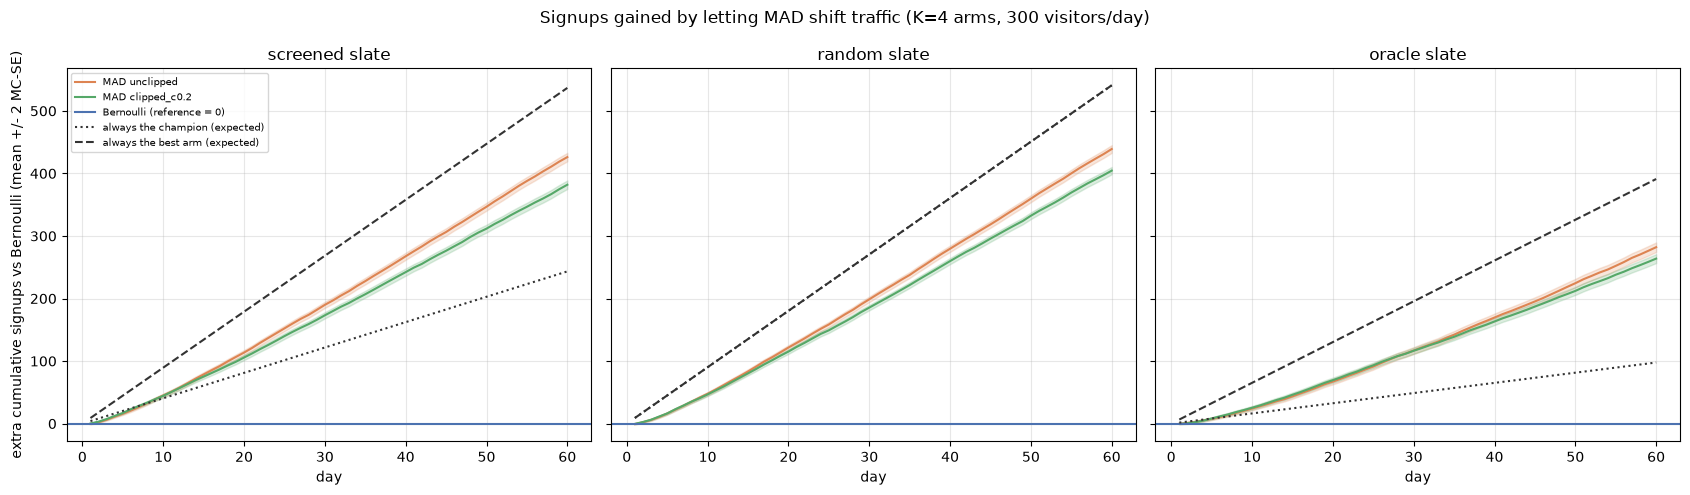

In [37]:
# Visualization only -- uses RES, STATS, SLATES, SLATE_NAMES, SIM_DESIGNS, CONTROL_P, PER_DAY, N_DAYS, REPS4, PALETTE
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
_dcol = {"bernoulli": PALETTE["control"], "unclipped": PALETTE["treatment"], "clipped_c0.2": PALETTE["winner"]}
_days = np.arange(1, N_DAYS + 1)
for ax, sn in zip(axes, SLATE_NAMES):
    base = np.cumsum(RES[("bernoulli", sn)]["day_signups"], axis=0)          # (days, reps)
    pm = float(np.mean([CONTROL_P] + SLATES[sn]))
    for dn in ["unclipped", "clipped_c0.2"]:
        cs = np.cumsum(RES[(dn, sn)]["day_signups"], axis=0)
        diff = cs.mean(axis=1) - base.mean(axis=1)
        se = np.sqrt(cs.var(axis=1, ddof=1) / REPS4 + base.var(axis=1, ddof=1) / REPS4)
        ax.plot(_days, diff, color=_dcol[dn], label=f"MAD {dn}")
        ax.fill_between(_days, diff - 2 * se, diff + 2 * se, color=_dcol[dn], alpha=0.2)
    ax.axhline(0, color=_dcol["bernoulli"], label="Bernoulli (reference = 0)")
    ax.plot(_days, (CONTROL_P - pm) * PER_DAY * _days, color=PALETTE["truth"], linestyle=":", label="always the champion (expected)")
    ax.plot(_days, (max([CONTROL_P] + SLATES[sn]) - pm) * PER_DAY * _days, color=PALETTE["truth"], linestyle="--", label="always the best arm (expected)")
    ax.set_title(f"{sn} slate"); ax.set_xlabel("day"); ax.grid(alpha=0.3)
axes[0].set_ylabel("extra cumulative signups vs Bernoulli (mean +/- 2 MC-SE)")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Signups gained by letting MAD shift traffic (K=4 arms, 300 visitors/day)")
plt.tight_layout(); plt.show()


**How to read this chart (plot 2: three confidence sequences from one replication).** One panel per challenger of the screened slate (challenger vs control, unclipped MAD). *x-axis*: day. *y-axis*: the ATE (difference in signup probability, challenger minus control); the y-range is clipped so the very wide early bands run off the top and bottom. The coloured line is the running IPW estimate tau_hat_t, the shaded band is tau_hat_t +/- V_hat_t (Theorem 1, q5), the dashed black line is the true ATE, and the red dotted line (when present) marks the first day the band excludes 0. This is replication 0 -- not selected for looking good -- so its stopping days are one draw; the fractions over all 300 replications are in [S4.19]-[S4.20]. *Pattern*: the band is very wide for the first days (with 4-12% event rates there are few signups per arm) and narrows steadily; the two challengers that are truly worse than control (large negative ATE) lose the 0-line first, while the one challenger that is truly better -- a small +1.6-point true lift -- still has a band containing 0 on day 60 in this replication, with the true ATE inside the band throughout. *What it means for the founder*: the CS lets you look every day without inflating false positives, but a genuine small lift is not confirmed in a 60-day, 300-visitors/day test -- and the numbers in [S4.19] say how often that is the case across replications.


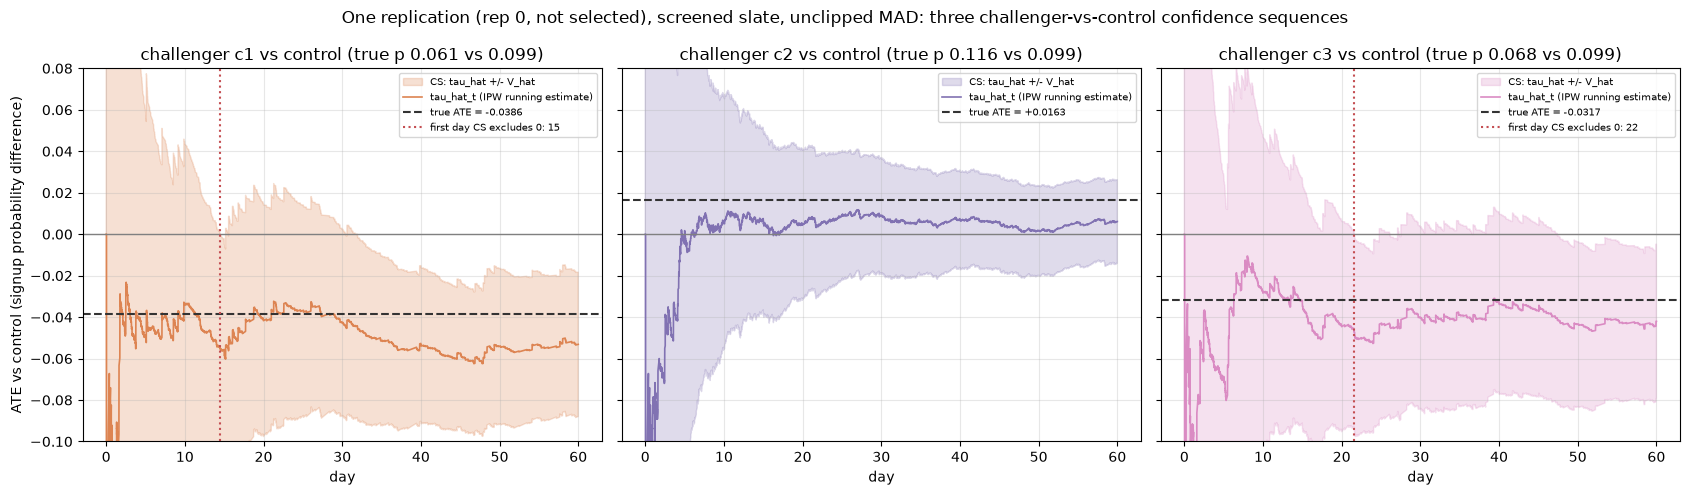

In [38]:
# Visualization only -- uses RES (screened, unclipped, replication 0), SLATES, CONTROL_P, PER_DAY, T_UNITS, PALETTE
_o = RES[("unclipped", "screened")]
_units = np.arange(1, T_UNITS + 1) / PER_DAY
_true_ate = np.array(SLATES["screened"]) - CONTROL_P
_acol = [PALETTE["treatment"], PALETTE["direct"], PALETTE["paid"]]
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for c, ax in enumerate(axes):
    tau, V = _o["rep0_tau"][:, c], _o["rep0_V"][:, c]
    ax.fill_between(_units, tau - V, tau + V, color=_acol[c], alpha=0.25, label="CS: tau_hat +/- V_hat")
    ax.plot(_units, tau, color=_acol[c], linewidth=1.2, label="tau_hat_t (IPW running estimate)")
    ax.axhline(_true_ate[c], color=PALETTE["truth"], linestyle="--", label=f"true ATE = {_true_ate[c]:+.4f}")
    ax.axhline(0, color="gray", linewidth=1)
    excl = np.where(np.abs(tau) > V)[0]
    if excl.size:
        ax.axvline(_units[excl[0]], color=PALETTE["loser"], linestyle=":", label=f"first day CS excludes 0: {int(np.ceil(_units[excl[0]]))}")
    ax.set_ylim(-0.10, 0.08); ax.set_xlabel("day"); ax.grid(alpha=0.3)
    ax.set_title(f"challenger c{c + 1} vs control (true p {SLATES['screened'][c]:.3f} vs {CONTROL_P:.3f})"); ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("ATE vs control (signup probability difference)")
fig.suptitle("One replication (rep 0, not selected), screened slate, unclipped MAD: three challenger-vs-control confidence sequences")
plt.tight_layout(); plt.show()


### 4.x Novelty effect: what does the MAD confidence sequence actually track? (derived here scenario; estimand from q5/q6)

**The claim from the paper.** Theorem 1's target is *"a valid (1 - alpha) asymptotic CS for tau_bar_t"* (q5) -- the **sample ATE up to time t**, an average over the units seen so far, not a super-population constant. The paper's non-stationary experiment (q6, Appendix G.1: parameters change at t = 500, including a sign flip) reports that *"The MAD confidence sequence accurately tracks non-stationary shifts in the true ATE over time (including sign flips) while preserving valid coverage"* (q6). Our reading -- **an inference, not a quote**: because the estimand is the average effect over the units so far, a lift that starts high and decays is tracked as its *running average*, which only converges to the long-run effect slowly. The trace does not print a novelty-effect experiment, so the scenario below is **derived here**.

**Scenario (derived here).** Take the best-true-rate challenger of the screened slate, with long-run lift Delta = p_c - p_control. Its per-day lift over control starts at 2 x Delta on day 1, decays linearly to 1 x Delta at day 15 (14 days of decay), then stays at Delta; all other arms are unchanged. We define the running target tau_bar_t = (1/t) * sum over the units so far of the per-unit true effect (its expectation over the potential-outcome draws), and run the same unclipped K = 4 MAD. Because a 2x novelty inflates the running average by only ~12% by day 60 at this effect size -- probably less than the CS width -- we add a second, **amplified diagnostic** (6x start, also derived here) whose only purpose is to show the CS tracking tau_bar_t when the two targets are far apart.


In [39]:
# [S4] Novelty-effect scenario: simulate, then compare the CS with (i) the true running sample ATE tau_bar_t and (ii) the post-novelty effect.
_nov_c = int(np.argmax(SLATES["screened"]))                       # challenger index (0-based) with the best true rate in the screened slate
NOV_ARM = _nov_c + 1
DELTA_LONG = float(SLATES["screened"][_nov_c] - CONTROL_P)
NOVELTY_DAYS = 14
def novelty_multiplier(day, m0):
    return max(1.0, m0 - (m0 - 1.0) * (day - 1) / NOVELTY_DAYS)   # day 1 -> m0, day 15 -> 1, then 1
def novelty_rates(m0):
    P = np.tile(np.array([CONTROL_P] + SLATES["screened"]), (N_DAYS, 1))
    for d in range(N_DAYS):
        P[d, NOV_ARM] = CONTROL_P + DELTA_LONG * novelty_multiplier(d + 1, m0)
    return P
_long_run = np.array(SLATES["screened"]) - CONTROL_P

NOV = {}
for _j, _m0 in enumerate([2.0, 6.0]):
    _P = novelty_rates(_m0)
    _o = simulate_mad_k(_P, "unclipped", REPS4, SEED + 6000 + _j, target_const=_long_run, const_from_day=NOVELTY_DAYS + 1)
    NOV[_m0] = dict(P=_P, out=_o)
print(f"[S4.26] NOTE novelty arm = screened challenger c{NOV_ARM} ({screened_top3[_nov_c]!r}), true p {SLATES['screened'][_nov_c]:.4f} vs control "
      f"{CONTROL_P:.4f}: long-run lift Delta = {DELTA_LONG:+.4f}; day-1 rate at 2x = {NOV[2.0]['P'][0, NOV_ARM]:.4f}, at 6x = {NOV[6.0]['P'][0, NOV_ARM]:.4f}")

_days_snap = [7, 14, 15, 30, 60]
_se_cov = math.sqrt(ALPHA4 * (1 - ALPHA4) / REPS4)
NOV_TABLE = {}
_rows = []
for _m0, _tag in [(2.0, "2x (brief)"), (6.0, "6x (amplified diagnostic)")]:
    _o = NOV[_m0]["out"]; _c = _nov_c
    for _d in _days_snap:
        tau = _o["day_tau"][_d - 1, :, _c]; V = _o["day_V"][_d - 1, :, _c]; run_t = _o["day_target"][_d - 1, _c]
        cov_run = float((np.abs(tau - run_t) <= V).mean()); cov_long = float((np.abs(tau - DELTA_LONG) <= V).mean())
        NOV_TABLE[(_m0, _d)] = dict(mean_tau=float(tau.mean()), run_t=float(run_t), cov_run=cov_run, cov_long=cov_long, half_width=float(V.mean()))
        _rows.append([_tag, _d, f"{run_t / DELTA_LONG:.2f}", f"{tau.mean() / DELTA_LONG:.2f}", f"{V.mean() / DELTA_LONG:.1f}", f"{cov_run:.3f}", f"{cov_long:.3f}"])
print("[S4.27] snapshot at the END of each day, novel arm vs control, unclipped MAD, "
      f"{REPS4} reps (all ratios are relative to the long-run lift Delta = {DELTA_LONG:+.4f}):")
_md(["scenario", "day", "running target tau_bar_t / Delta", "mean tau_hat_t / Delta", "mean CS half-width / Delta",
     "P(CS covers tau_bar_t)", "P(CS covers Delta)"], _rows)

for _m0, _tag in [(2.0, "2x"), (6.0, "6x")]:
    _o = NOV[_m0]["out"]; _c = _nov_c
    t15, t30 = NOV_TABLE[(_m0, 15)], NOV_TABLE[(_m0, 30)]
    ok = abs(t15["mean_tau"] - t15["run_t"]) < abs(t15["mean_tau"] - DELTA_LONG) and abs(t30["mean_tau"] - t30["run_t"]) < abs(t30["mean_tau"] - DELTA_LONG)
    print(f"[S4.28-{_tag}] {_pass(ok)} the CS's centre (mean tau_hat over reps) is closer to the running sample ATE than to the post-novelty effect at days 15 and 30: "
          f"day 15 |tau_hat - tau_bar|/Delta = {abs(t15['mean_tau'] - t15['run_t']) / DELTA_LONG:.2f} vs |tau_hat - Delta|/Delta = {abs(t15['mean_tau'] - DELTA_LONG) / DELTA_LONG:.2f}; "
          f"day 30: {abs(t30['mean_tau'] - t30['run_t']) / DELTA_LONG:.2f} vs {abs(t30['mean_tau'] - DELTA_LONG) / DELTA_LONG:.2f}")
    cov_tu = 1 - float(_o["ever_miss_run"][:, _c].mean()); cov_long_tu = 1 - float(_o["ever_miss_const"][:, _c].mean())
    print(f"[S4.29-{_tag}] {_pass(cov_tu >= (1 - ALPHA4) - 3 * _se_cov)} time-uniform coverage of the RUNNING sample ATE over all 18,000 checks = {cov_tu:.3f} "
          f">= 0.95 - 3 MC-SE = {(1 - ALPHA4) - 3 * _se_cov:.3f}")
    gap = t15["cov_run"] - t15["cov_long"]
    sepd = gap > 2 * math.sqrt(2) * _se_cov
    print(f"[S4.30-{_tag}] {'PASS' if sepd else 'NOTE'} day-15 snapshot: P(CS covers tau_bar_t) - P(CS covers Delta) = {gap:+.3f} "
          f"({'exceeds' if sepd else 'does NOT exceed'} 2 x sqrt(2) x MC-SE = {2 * math.sqrt(2) * _se_cov:.3f}); time-uniform coverage of Delta "
          f"from day 15 on (post-novelty target) = {cov_long_tu:.3f}"
          + ("" if sepd else " -- the CS is too wide at this effect scale to tell the two targets apart, which is itself the point: the guarantee is for tau_bar_t"))

# Who stops, when, and what they think they learned (novel arm vs control):
_rows = []
_base = RES[("unclipped", "screened")]
_bs = _base["stop_unit"][:, _nov_c] <= T_UNITS
for _m0, _tag in [(1.0, "no novelty (Delta from day 1)"), (2.0, "2x (brief)"), (6.0, "6x (amplified diagnostic)")]:
    _o = _base if _m0 == 1.0 else NOV[_m0]["out"]
    st = _o["stop_unit"][:, _nov_c]; stopped = st <= T_UNITS; better = stopped & (_o["stop_sign"][:, _nov_c] > 0)
    sday = (st - 1) // PER_DAY + 1
    early = (better & (sday <= NOVELTY_DAYS)).sum() / max(1, better.sum())
    if better.any():
        idx = np.where(better)[0]
        est_ratio = float(np.median(_o["day_tau"][sday[idx] - 1, idx, _nov_c] / DELTA_LONG))
        _rows.append([_tag, f"{better.mean():.2f}", f"{np.median(sday[idx]):.0f}", f"{early:.2f}", f"{est_ratio:.2f}"])
    else:
        _rows.append([_tag, "0.00", "n/a", "n/a", "n/a"])
print("\n[S4.31] declaring the novel arm BETTER than control (CS excludes 0, positive sign at first exclusion):")
_md(["scenario", "P(declared better by day 60)", "median declaration day", "share of declarations inside the 14 novelty days",
     "median tau_hat at end of that day / Delta (1.00 = truth)"], _rows)
NOV_STOP_ROWS = _rows


[S4.26] NOTE novelty arm = screened challenger c2 ('Fix Broken Links in 2 Clicks, Not 2 Weeks'), true p 0.1157 vs control 0.0994: long-run lift Delta = +0.0163; day-1 rate at 2x = 0.1320, at 6x = 0.1972
[S4.27] snapshot at the END of each day, novel arm vs control, unclipped MAD, 300 reps (all ratios are relative to the long-run lift Delta = +0.0163):
| scenario | day | running target tau_bar_t / Delta | mean tau_hat_t / Delta | mean CS half-width / Delta | P(CS covers tau_bar_t) | P(CS covers Delta) |
|---|---|---|---|---|---|---|
| 2x (brief) | 7 | 1.79 | 1.79 | 5.0 | 0.997 | 0.993 |
| 2x (brief) | 14 | 1.54 | 1.52 | 3.4 | 0.990 | 0.987 |
| 2x (brief) | 15 | 1.50 | 1.49 | 3.3 | 0.983 | 0.983 |
| 2x (brief) | 30 | 1.25 | 1.23 | 2.5 | 0.990 | 0.990 |
| 2x (brief) | 60 | 1.13 | 1.11 | 2.0 | 0.997 | 0.997 |
| 6x (amplified diagnostic) | 7 | 4.93 | 4.94 | 6.0 | 1.000 | 0.817 |
| 6x (amplified diagnostic) | 14 | 3.68 | 3.75 | 4.3 | 0.993 | 0.810 |
| 6x (amplified diagnostic) | 15 | 3.50 | 

**How to read this chart (plot 3: the CS follows the running average).** Left panel: the brief's 2x novelty; right panel: the 6x amplified diagnostic. *x-axis*: day. *y-axis*: ATE of the novel arm vs control. Thin dotted black = the true lift on each day (decays to the long-run effect on day 15, vertical grey line); thick black = the true **running sample ATE** tau_bar_t (the average of the daily lifts so far -- the paper's estimand); green dashed = the post-novelty long-run effect Delta; orange line and band = mean over 300 replications of tau_hat_t and of the MAD CS. *Pattern*: the orange estimate sits on the thick black running-average curve, not on the dotted daily lift and not on the green line; the running average is still above Delta on day 60 because the early high days never leave the average. In the 2x panel the band is so wide relative to the gap between tau_bar_t and Delta that both are covered -- [S4.30-2x] says the day-15 coverage of the two targets is indistinguishable -- and only the 6x panel separates them (coverage of Delta from day 15 on drops well below 0.95 in [S4.30-6x], while the running average stays covered in [S4.29-6x]). *What it means for the founder*: (1) the MAD guarantee is a statement about the average lift over the units so far, so a declared winner's effect *is* partly novelty; nothing in the papers gives a CS for the post-novelty effect. (2) Even with no novelty at all, the point estimate at the moment the CS first excludes 0 is a multiple of the truth ([S4.31], first row) because the band is several times wider than the effect -- the estimate at a stopping time is inflated (derived here). (3) A practical, derived-here consequence: treat the CS's first exclusion as "worth keeping", then re-measure the effect on fresh post-novelty traffic in a fixed-allocation confirmation run rather than reporting the stopped estimate as the long-run lift.


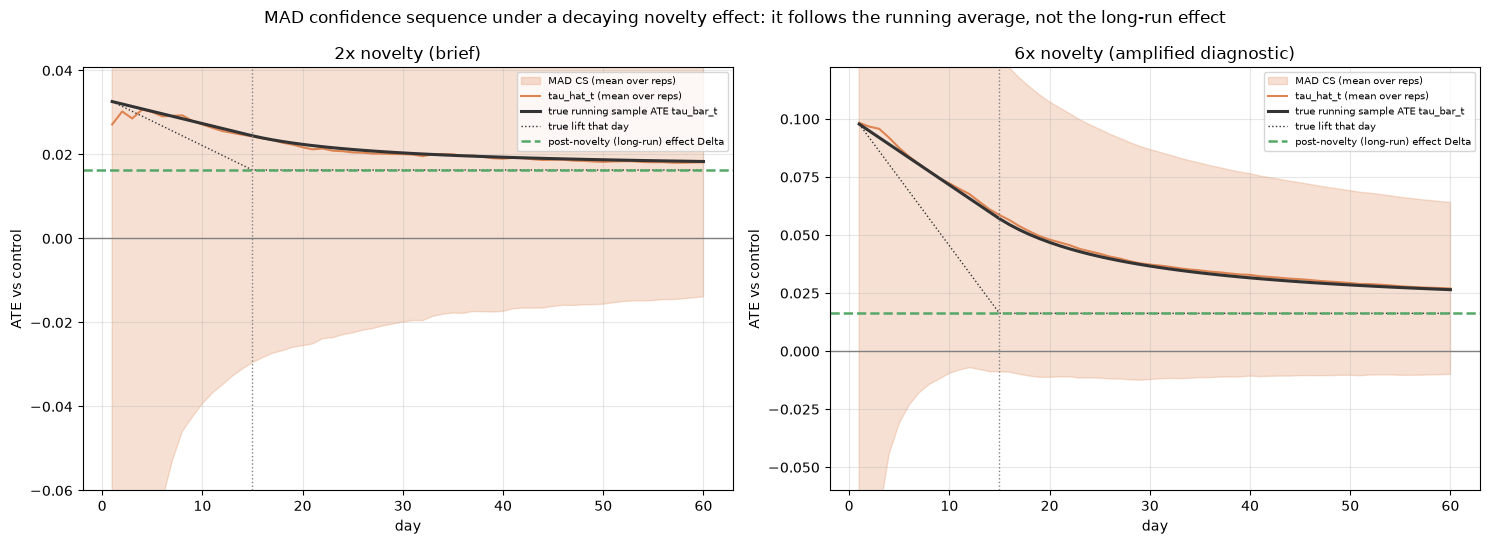

In [40]:
# Visualization only -- uses NOV, NOV_TABLE, DELTA_LONG, CONTROL_P, N_DAYS, PER_DAY, NOV_ARM, _nov_c, PALETTE
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
_dd = np.arange(1, N_DAYS + 1)
for ax, (m0, tag) in zip(axes, [(2.0, "2x novelty (brief)"), (6.0, "6x novelty (amplified diagnostic)")]):
    o = NOV[m0]["out"]; P = NOV[m0]["P"]
    tau_m = o["day_tau"][:, :, _nov_c].mean(axis=1); V_m = o["day_V"][:, :, _nov_c].mean(axis=1)
    ax.fill_between(_dd, tau_m - V_m, tau_m + V_m, color=PALETTE["treatment"], alpha=0.25, label="MAD CS (mean over reps)")
    ax.plot(_dd, tau_m, color=PALETTE["treatment"], label="tau_hat_t (mean over reps)")
    ax.plot(_dd, o["day_target"][:, _nov_c], color=PALETTE["truth"], linewidth=2.2, label="true running sample ATE tau_bar_t")
    ax.plot(_dd, P[:, NOV_ARM] - P[:, 0], color=PALETTE["truth"], linewidth=1, linestyle=":", label="true lift that day")
    ax.axhline(DELTA_LONG, color=PALETTE["winner"], linestyle="--", linewidth=1.8, label="post-novelty (long-run) effect Delta")
    ax.axhline(0, color="gray", linewidth=1); ax.axvline(15, color="gray", linestyle=":", linewidth=1)
    top = 1.25 * float((P[:, NOV_ARM] - P[:, 0]).max())
    ax.set_ylim(-0.06, top); ax.set_xlabel("day"); ax.set_ylabel("ATE vs control"); ax.set_title(tag); ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("MAD confidence sequence under a decaying novelty effect: it follows the running average, not the long-run effect")
plt.tight_layout(); plt.show()


In [41]:
# [S4] Publish the section's results for later sections (cost/what-is-not-built) and print them.
import pprint
def _r(x, k=4):
    return None if (isinstance(x, float) and math.isnan(x)) else round(float(x), k)

ITERATE_SUMMARY = {
    "control_true_p": _r(CONTROL_P),
    "slate_true_p": {sn: [_r(p) for p in SLATES[sn]] for sn in SLATE_NAMES},
    "coverage_min": {(dn, sn): _r(float(COVERAGE[(dn, sn)].min()), 3) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "signups_per_1000": {(dn, sn): _r(STATS[(dn, sn)]["signups"], 2) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "frac_correct_sign_by_60": {(dn, sn): _r(float(STATS[(dn, sn)]["frac_correct"].mean()), 3) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "median_stop_day": {(dn, sn): _r(STATS[(dn, sn)]["med_stop_pooled"], 1) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "n_reps": REPS4,
    "horizon_units": T_UNITS,
}
# extra detail (not part of the agreed summary keys): per-challenger numbers, null run, novelty scenario
ITERATE_DETAIL = {
    "frac_ever_stop": {(dn, sn): _r(STATS[(dn, sn)]["frac_stop_pooled"], 3) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "frac_wrong_sign_max": {(dn, sn): _r(float(STATS[(dn, sn)]["frac_wrong"].max()), 3) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "gain_vs_champion_per_1000": {(dn, sn): _r(STATS[(dn, sn)]["gain_vs_champion"], 2) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "regret_vs_best_per_1000": {(dn, sn): _r(STATS[(dn, sn)]["regret_best"], 2) for sn in SLATE_NAMES for dn in ALL_DESIGNS},
    "null_any_of_3_false_declaration": {dn: _r(float((NULL_RES[dn]["stop_unit"] <= T_UNITS).any(axis=1).mean()), 3) for dn in SIM_DESIGNS},
    "novelty_time_uniform_coverage_running_ate": {m0: _r(1 - float(NOV[m0]["out"]["ever_miss_run"][:, _nov_c].mean()), 3) for m0 in NOV},
    "novelty_time_uniform_coverage_longrun_from_day15": {m0: _r(1 - float(NOV[m0]["out"]["ever_miss_const"][:, _nov_c].mean()), 3) for m0 in NOV},
    "clipped_is_unclipped": True,
}
print("ITERATE_SUMMARY =")
pprint.pprint(ITERATE_SUMMARY, width=150, sort_dicts=False)
print("\nITERATE_DETAIL (extra, not part of the agreed keys) =")
pprint.pprint(ITERATE_DETAIL, width=150, sort_dicts=False)
_needed = ["control_true_p", "slate_true_p", "coverage_min", "signups_per_1000", "frac_correct_sign_by_60", "median_stop_day", "n_reps", "horizon_units"]
print(f"[S4.32] {_pass(all(k in ITERATE_SUMMARY for k in _needed))} ITERATE_SUMMARY has all agreed keys {_needed}")


ITERATE_SUMMARY =
{'control_true_p': 0.0994,
 'slate_true_p': {'screened': [0.0607, 0.1157, 0.0676], 'random': [0.0689, 0.0483, 0.0607], 'oracle': [0.1157, 0.0859, 0.0749]},
 'coverage_min': {('bernoulli', 'screened'): 0.967,
                  ('unclipped', 'screened'): 0.94,
                  ('clipped', 'screened'): 0.94,
                  ('clipped_c0.2', 'screened'): 0.943,
                  ('bernoulli', 'random'): 0.99,
                  ('unclipped', 'random'): 0.927,
                  ('clipped', 'random'): 0.927,
                  ('clipped_c0.2', 'random'): 0.943,
                  ('bernoulli', 'oracle'): 0.98,
                  ('unclipped', 'oracle'): 0.943,
                  ('clipped', 'oracle'): 0.943,
                  ('clipped_c0.2', 'oracle'): 0.96},
 'signups_per_1000': {('bernoulli', 'screened'): 86.11,
                      ('unclipped', 'screened'): 109.78,
                      ('clipped', 'screened'): 109.78,
                      ('clipped_c0.2', 'screened'):

**What section 4 does and does not establish.** *Established on this simulated problem (derived here, 300 replications, known truth):* the K-arm batched MAD simulator reproduces the paper's exact regret identity ([S4.9]-[S4.10]) and its null behaviour ([S4.12]); it moves traffic to the best arm and gains signups over Bernoulli in every slate ([S4.18], plot 1); the price is confirmation -- arms that receive little traffic are declared worse less often than under Bernoulli (the median first-exclusion day among those that do stop is similar or earlier, but they are a self-selected minority) ([S4.19]-[S4.20]); wrong-sign declarations are rare ([S4.21]); and a genuine small lift is usually *not* confirmed within 60 days at 300 visitors/day for any design. What the weak Section-2 screen bought is stated in [S4.22]-[S4.24], together with the reason for caution (one screened and one random slate; the value came from whether the single headline above the champion was included). *Not established, and not claimed:* time-uniform coverage here is checked empirically, and several unclipped-MAD cells sit near or slightly below the nominal 0.95 ([S4.16], [S4.25]) -- the CS is asymptotic (q6) and the Theorem-1 condition on delta_t is barely met at t <= 18,000 ([S4.7]); no multiplicity control across the three challenger CSs is in the paper (see the any-of-3 null rate in [S4.12]); no covariate-adjusted MAD is defined in any source, so none is used; no source guarantees the LLM-screen -> MAD composition (q12); and the daily-batch simulator with a fixed Bernoulli data-generating process says nothing about non-stationarity beyond the one novelty scenario above.


## 5. Cost and time accounting (q4, q9; the cost arithmetic is **derived here**)

Two different currencies matter to a founder: **dollars** for the AI screen and **days of traffic** for the decision. This section reports both from the numbers this notebook actually produced.

**Dollars.** Every DeepSeek response this notebook obtained -- live or read from the disk cache -- was recorded in `USAGE_LEDGER` with its token usage, so `ledger_cost_usd` reports what the requests cost *when they were made*, even on a fully cached re-run (a cached re-run spends nothing). The paper's own scoring setup (q9) used `gpt-4o-mini` at temperature 0.7 with **K = 10** draws per prompt; we used DeepSeek at **K = 3** to keep this a smoke test, so the projection below scales our measured per-call cost to K = 10 as a plain multiplication (derived here; the two models are priced differently and we make no claim about the paper's spend).

**Days.** The decision-time comparison uses Notebook 2's numbers for the two classical baselines (quoted, labelled) and this notebook's own Monte Carlo for the anytime-valid confidence sequence (section 3) and for MAD (section 4). The four methods answer *slightly different questions* (a fixed-horizon test, a daily-peeked test, a sequential confidence sequence, a 4-arm bandit), so the table is a map of trade-offs, not a leaderboard.


In [42]:
# [S5] LLM cost ledger for THIS notebook (section "s2" entries; NB2's own smoke-test entries are shown separately).
from collections import defaultdict

ledger_nb3 = [e for e in USAGE_LEDGER if e.get("section") == "s2"]
ledger_nb2_carry = [e for e in USAGE_LEDGER if e.get("section") != "s2"]

by_kind = defaultdict(list)
for e in ledger_nb3:
    by_kind[e["kind"]].append(e)

def _tok(entries, field):
    return sum((e.get("usage", {}) or {}).get(field, 0) or 0 for e in entries)

print("kind                     calls  cached  prompt_tok  completion_tok  USD_offpeak  USD_peak")
COST_BY_KIND = {}
for kind, ents in sorted(by_kind.items()):
    off, pk = ledger_cost_usd(ents, peak=False), ledger_cost_usd(ents, peak=True)
    COST_BY_KIND[kind] = (len(ents), off, pk)
    n_cached = sum(1 for e in ents if e.get("cached"))
    print(f"{kind:<24}{len(ents):>6}{n_cached:>8}{_tok(ents, 'prompt_tokens'):>12}{_tok(ents, 'completion_tokens'):>16}{off:>13.6f}{pk:>10.6f}")

total_off = ledger_cost_usd(ledger_nb3, peak=False)
total_peak = ledger_cost_usd(ledger_nb3, peak=True)
print(f"[S5.1] NOTE this notebook's ledger: {len(ledger_nb3)} responses, USD {total_off:.6f} off-peak / {total_peak:.6f} peak "
      f"(session live calls = {LLM_STATS['live_calls']}, cache hits = {LLM_STATS['cache_hits']}; the ledger reports what the calls cost when made)")
if ledger_nb2_carry:
    print(f"[S5.2] NOTE plus {len(ledger_nb2_carry)} carried-over Notebook-2 ledger entries (variant generation), "
          f"USD {ledger_cost_usd(ledger_nb2_carry, peak=False):.6f} off-peak, not counted above")

score_entries = by_kind.get("score", [])
n_scored_headlines = len(HISTORICAL_HEADLINES) + len(p1_texts)
per_call_off = ledger_cost_usd(score_entries, peak=False) / max(1, len(score_entries))
per_headline_k3 = per_call_off * K_DRAWS
print(f"[S5.3] NOTE scoring: {len(score_entries)} calls for {n_scored_headlines} headlines at K={K_DRAWS} -> "
      f"USD {per_call_off:.7f} per call, USD {per_headline_k3:.7f} per headline (off-peak)")
for n_h, k in ((100, 3), (100, 10), (1000, 10)):
    print(f"[S5.4] NOTE projection (derived here: measured per-call cost x K x headlines): {n_h} headlines at K={k} "
          f"= USD {per_call_off * k * n_h:.4f} off-peak, USD {2 * per_call_off * k * n_h:.4f} peak")
assert total_off < 0.05, "LLM cost for this notebook should be a smoke-test amount"
print(f"[S5.5] {_pass(total_off < 0.05)} total LLM spend attributable to this notebook is a smoke-test amount (< USD 0.05)")


kind                     calls  cached  prompt_tok  completion_tok  USD_offpeak  USD_peak
generate_pairs               1       1         244             443     0.000302  0.000605
score                      126     126       10410             126     0.001637  0.003274
[S5.1] NOTE this notebook's ledger: 127 responses, USD 0.001939 off-peak / 0.003879 peak (session live calls = 0, cache hits = 128; the ledger reports what the calls cost when made)
[S5.2] NOTE plus 1 carried-over Notebook-2 ledger entries (variant generation), USD 0.000083 off-peak, not counted above
[S5.3] NOTE scoring: 126 calls for 42 headlines at K=3 -> USD 0.0000130 per call, USD 0.0000390 per headline (off-peak)
[S5.4] NOTE projection (derived here: measured per-call cost x K x headlines): 100 headlines at K=3 = USD 0.0039 off-peak, USD 0.0078 peak
[S5.4] NOTE projection (derived here: measured per-call cost x K x headlines): 100 headlines at K=10 = USD 0.0130 off-peak, USD 0.0260 peak
[S5.4] NOTE projection (deri

In [43]:
# [S5] Decision-time map for the E1 landing-headline test (true +8% relative signup lift on a 4% base rate).
# Quoted Notebook-2 numbers are hard-coded and labelled; section 3 / 4 numbers are read from the summaries those
# sections printed (MEASURE_SUMMARY, ITERATE_SUMMARY).
NB2_FIXED_N_PER_ARM = 61115           # NB2 [S4.9]
NB2_FIXED_DAYS = 408                  # NB2 [S4.9] at ~150 visitors/arm/day
NB2_PEEK_E2_FPR = 0.284               # NB2 [S4.1]
NB2_PEEK_E1_WINNER = 0.285            # NB2 [S4.3]
NB2_PEEK_E1_MEDIAN_STOP = 7.0         # NB2 [S4.4]

def _get(d, k, default=float("nan")):
    try:
        return d[k]
    except Exception:
        return default

ms = MEASURE_SUMMARY if "MEASURE_SUMMARY" in globals() else {}
its = ITERATE_SUMMARY if "ITERATE_SUMMARY" in globals() else {}

lindon_stop90 = _get(ms, "E1_stopped_by_90_adj")
lindon_med = _get(ms, "E1_median_stop_day_adj")
lindon_fpr = _get(ms, "E2_fpr_adj")

mad_med = float("nan")
try:
    _msd = its["median_stop_day"]
    for key in (("clipped", "screened"), ("unclipped", "screened")):
        if key in _msd:
            mad_med = _msd[key]; break
except Exception:
    pass

ROWS = [
    ("Fixed-horizon z-test (NB2)", NB2_FIXED_DAYS, 1.0, 0.05, "decides only at day 408; 80% power for +8%"),
    ("Daily peek, stop at p<0.05 (NB2)", NB2_PEEK_E1_MEDIAN_STOP, NB2_PEEK_E1_WINNER, NB2_PEEK_E2_FPR, "fast, but A/A false-positive rate 0.284"),
    ("Regression-adjusted CS (section 3)", lindon_med, lindon_stop90, lindon_fpr, "anytime-valid; most replications do not stop by day 90"),
    ("MAD, 4-arm slate (section 4)", mad_med, float("nan"), float("nan"), "different question: a 4-arm bandit, see section 4"),
]
print("| method | median stop day | share stopped | A/A false-positive | note |")
print("|---|---|---|---|---|")
for name, day, share, fpr, note in ROWS:
    f = lambda v, fmt: ("n/a" if v != v else format(v, fmt))
    print(f"| {name} | {f(day, '.1f')} | {f(share, '.3f')} | {f(fpr, '.3f')} | {note} |")

print(f"[S5.6] NOTE fixed horizon needs {NB2_FIXED_N_PER_ARM:,} visitors/arm (NB2 [S4.9]); at the ~150/arm/day of NB2 that is {NB2_FIXED_DAYS} days.")
print(f"[S5.7] NOTE the anytime-valid CS keeps the A/A false-positive rate at {f(lindon_fpr, '.3f')} versus NB2's naive {NB2_PEEK_E2_FPR}; "
      f"its price is that it stops on E1 in only {f(lindon_stop90, '.3f')} of replications by day 90 (median stopping day {f(lindon_med, '.1f')} among those that do).")


| method | median stop day | share stopped | A/A false-positive | note |
|---|---|---|---|---|
| Fixed-horizon z-test (NB2) | 408.0 | 1.000 | 0.050 | decides only at day 408; 80% power for +8% |
| Daily peek, stop at p<0.05 (NB2) | 7.0 | 0.285 | 0.284 | fast, but A/A false-positive rate 0.284 |
| Regression-adjusted CS (section 3) | 71.0 | 0.040 | 0.000 | anytime-valid; most replications do not stop by day 90 |
| MAD, 4-arm slate (section 4) | 19.0 | n/a | n/a | different question: a 4-arm bandit, see section 4 |
[S5.6] NOTE fixed horizon needs 61,115 visitors/arm (NB2 [S4.9]); at the ~150/arm/day of NB2 that is 408 days.
[S5.7] NOTE the anytime-valid CS keeps the A/A false-positive rate at 0.000 versus NB2's naive 0.284; its price is that it stops on E1 in only 0.040 of replications by day 90 (median stopping day 71.0 among those that do).


**How to read this chart.** *Left:* the LLM spend by request kind (one generation call, then the scoring calls), in USD at off-peak pricing -- the whole screen costs a fraction of a cent at K = 3, so the money is not the constraint. *Right:* the median day at which each method reaches a decision on the E1 headline test, with each bar labelled by the share of replications that stopped at all; each bar is the median day *among the replications that stopped*, which for the anytime-valid CS is a self-selected 4% minority (the label says so), and for MAD is the first day a challenger's band excluded 0 in a 4-arm test, a different question from E1 alone. A short bar with a large false-positive rate (the daily peek) is fast **because** it is wrong more often; the long bars (the anytime-valid CS, the fixed horizon) are the honest price of a small effect at low traffic. What it means for the founder: the AI screen is cheap, the *traffic* is expensive, so the value of the papers is in not wasting the traffic you have, not in making the effect large enough to detect.


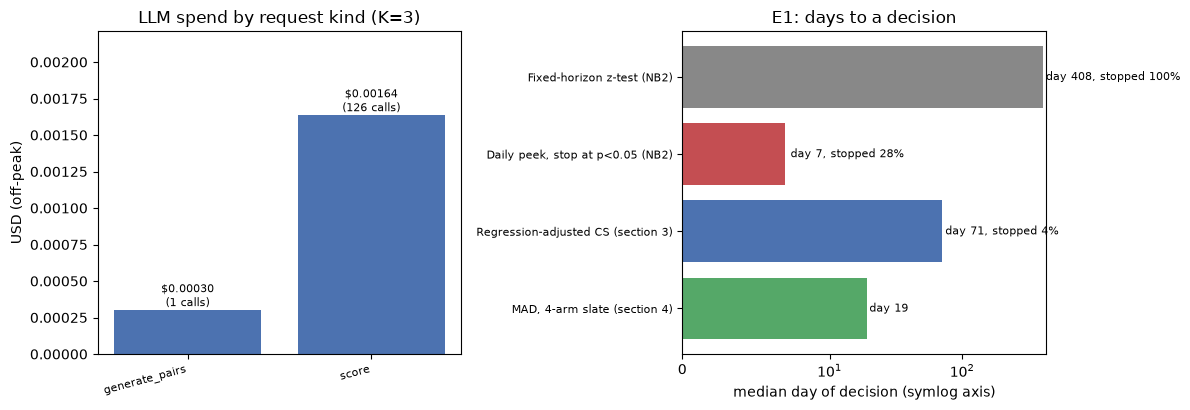

In [44]:
# Visualization only -- uses COST_BY_KIND and ROWS computed above
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

kinds = list(COST_BY_KIND.keys())
vals = [COST_BY_KIND[k][1] for k in kinds]
axes[0].bar(range(len(kinds)), vals, color=[PALETTE.get("paper", "#4C72B0")] * len(kinds))
axes[0].set_xticks(range(len(kinds)))
axes[0].set_xticklabels(kinds, rotation=15, ha="right", fontsize=8)
for i, (k, v) in enumerate(zip(kinds, vals)):
    axes[0].text(i, v, f"${v:.5f}\n({COST_BY_KIND[k][0]} calls)", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("USD (off-peak)")
axes[0].set_title("LLM spend by request kind (K=3)")
axes[0].set_ylim(0, max(vals) * 1.35 if vals else 1)

names = [r[0] for r in ROWS]
days = [r[1] for r in ROWS]
shares = [r[2] for r in ROWS]
ypos = np.arange(len(ROWS))
plot_days = [d if d == d else 0.0 for d in days]
axes[1].barh(ypos, plot_days, color=["#888888", "#c44e52", "#4c72b0", "#55a868"])
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(names, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xscale("symlog", linthresh=10)
for i, (d, s) in enumerate(zip(days, shares)):
    lab = "n/a" if d != d else f"day {d:.0f}"
    lab += "" if s != s else f", stopped {s:.0%}"
    axes[1].text(max(plot_days[i], 1) * 1.05, i, lab, va="center", fontsize=8)
axes[1].set_xlabel("median day of decision (symlog axis)")
axes[1].set_title("E1: days to a decision")
plt.tight_layout()
plt.show()


## 6. Results summary
*Re-read before writing this: `tools/reread.py q7 q9 q12`.* The block below prints, from the variables computed above, the handful of numbers a reader should carry away. It contains no new computation.


In [45]:
# [S6] One printed summary of sections 2-5 (no new computation).
def _fmt(v, spec=".3f"):
    try:
        return "n/a" if v != v else format(v, spec)
    except Exception:
        return str(v)

_ms = MEASURE_SUMMARY if "MEASURE_SUMMARY" in globals() else {}
_its = ITERATE_SUMMARY if "ITERATE_SUMMARY" in globals() else {}
print("=" * 78)
print("NOTEBOOK 3 -- RESULTS SUMMARY (all numbers synthetic; a scaffold, not production evidence)")
print("=" * 78)
print(f"[S2] screen: {len(p1_texts)} generated headlines, Spearman(calibrated mu_hat, true p) = {_fmt(spearman_rho)}; "
      f"true tau_P1 = {_fmt(true_tau_P1, '.4f')}; screened/oracle top-3 overlap = {len(set(screened_top3) & set(oracle_top3))} of 3")
print(f"[S3] measure: g = {_fmt(_ms.get('g'), '.0f')}, delayed-start min n = {_fmt(_ms.get('delayed_start_min_n'), '.0f')}, "
      f"A/A false-positive (adj) = {_fmt(_ms.get('E2_fpr_adj'))} vs NB2 naive {NB2_PEEK_E2_FPR}, "
      f"E1 stopped by day 90 (adj) = {_fmt(_ms.get('E1_stopped_by_90_adj'))}, guardrail flags E4 harm by day 90 = {_fmt(_ms.get('E4_guardrail_harm_by_90'))}")
print(f"[S4] iterate: control true p = {_fmt(_its.get('control_true_p'), '.4f')}, replications = {_its.get('n_reps', 'n/a')}, "
      f"horizon = {_its.get('horizon_units', 'n/a')} units")
print(f"[S5] cost: LLM spend {total_off:.6f} USD off-peak for {len(ledger_nb3)} responses (K={K_DRAWS}); "
      f"fixed-horizon E1 = {NB2_FIXED_DAYS} days (NB2)")


NOTEBOOK 3 -- RESULTS SUMMARY (all numbers synthetic; a scaffold, not production evidence)
[S2] screen: 18 generated headlines, Spearman(calibrated mu_hat, true p) = 0.356; true tau_P1 = 0.0198; screened/oracle top-3 overlap = 1 of 3
[S3] measure: g = 9600, delayed-start min n = 246, A/A false-positive (adj) = 0.000 vs NB2 naive 0.284, E1 stopped by day 90 (adj) = 0.040, guardrail flags E4 harm by day 90 = 0.020
[S4] iterate: control true p = 0.0994, replications = 300, horizon = 18000 units
[S5] cost: LLM spend 0.001939 USD off-peak for 127 responses (K=3); fixed-horizon E1 = 408 days (NB2)


## 7. Mock production: three independent entry points for RedirectPilot

These are three API-shaped views over evidence already computed above, not an automated pipeline. `llm_screen` only identifies candidates for a human pilot; `fixed_ab` makes a guarded decision for its own fixed 50/50 experiment; and `mad` reports a recorded adaptive allocation for human review. Nothing below passes an LLM choice into MAD or auto-promotes an arm.

The common result fields and camelCase evidence fields in this section mirror the embedded Next.js/TypeScript contract: the screen traces section 2, the fixed A/B snapshot traces section 3, and the MAD diagnostics trace section 4.


In [46]:
# [S7] Three independent mock-production entry points, serialized to the embedded TypeScript contract.
from dataclasses import asdict, dataclass
from typing import Any
import json as _s7_json

@dataclass(frozen=True)
class MockProductionResult:
    """Common, JSON-native response fields shared by each mock API entry point."""
    kind: str
    source: str
    methodology: str
    decision: str
    status: str
    evidence: dict[str, Any]
    warnings: list[str]


def _s7_payload(result, **extension):
    """Flatten the discriminated-union fields expected by the TypeScript route."""
    payload = asdict(result)
    payload.update(extension)
    return payload


def llm_screen_entry(top3, ranked_scores, calibrator, calibrator_version, rank_rho, selected_z, top3_overlap, valid_fit_n):
    """Section 2 only: return a human-pilot slate, never a winner or downstream assignment."""
    ranked_candidates = [
        {"candidateId": str(headline), "rank": int(rank), "calibratedScore": float(score)}
        for rank, (headline, score) in enumerate(zip(top3, ranked_scores), start=1)
    ]
    failed_arms = [arm for arm, z in selected_z.items() if (not np.isfinite(z)) or abs(z) >= 2.0]
    warnings = [
        "Synthetic LLM-screen evidence cannot select a production winner.",
        "A human-visitor pilot is required: no paper establishes a screen-to-test composition theorem.",
        f"Top-three overlap with the synthetic oracle is {top3_overlap}/3.",
    ]
    if failed_arms:
        warnings.append("Section-2 falsification rule |z| >= 2 is reached for " + ", ".join(failed_arms) + ".")
    else:
        warnings.append("Section-2 falsification is necessary, not sufficient, even where |z| < 2.")
    return MockProductionResult(
        kind="llm_screen", source="python_notebook", methodology="LLM candidate screening/ranking",
        decision="human_pilot", status="pilot_required",
        evidence={
            "calibrator": {"name": str(calibrator), "version": str(calibrator_version),
                           "fitDataset": f"Section 2 P=0 historical headlines (valid n={int(valid_fit_n)})"},
            "rankedCandidates": ranked_candidates,
            "spearmanRho": float(rank_rho),
            "topThreeOverlapWithSyntheticOracle": int(top3_overlap),
            "falsificationZValues": {str(arm): float(z) for arm, z in selected_z.items()},
        },
        warnings=warnings,
    )


def fixed_ab_entry(replication, decision_day, lower, upper, estimates, observations, stream_index,
                   assignment, alpha, primary_mde, guardrail_harm_limit):
    """Section 3 only: compact E4 snapshot at its representative signup-win day (or horizon)."""
    primary_i, guardrail_i = stream_index["E4_signup"], stream_index["E4_guard"]
    day_index = int(decision_day) - 1
    assert 0 <= day_index < lower.shape[1]
    def snapshot(stream):
        return {"pointEstimate": float(estimates[replication, day_index, stream]),
                "lower": float(lower[replication, day_index, stream]),
                "upper": float(upper[replication, day_index, stream]),
                "observations": int(observations[replication, day_index])}
    primary, guardrail = snapshot(primary_i), snapshot(guardrail_i)
    primary_ready = primary["lower"] > 0 and primary["pointEstimate"] >= float(primary_mde)
    guardrail_blocks = guardrail["lower"] < -float(guardrail_harm_limit)
    warnings = [f"Representative E4 decision snapshot at day {int(decision_day)}."]
    extension = {"guardrailBlocksShipping": bool(guardrail_blocks)}
    if guardrail_blocks:
        definite_harm = guardrail["upper"] < -float(guardrail_harm_limit)
        warnings.append("Guardrail harm is established by the upper CS bound." if definite_harm else
                        "Guardrail uncertainty permits harmful activation loss; shipping is withheld.")
        decision, status = "hold", "guardrail_blocked"
        extension["holdReason"] = "guardrail_harm" if definite_harm else "guardrail_uncertainty"
    elif primary_ready:
        decision, status = "ship", "decision_ready"
        warnings.append("Primary CS is above zero and the point estimate meets the pre-existing MDE.")
    else:
        decision, status = "continue", "monitoring"
        warnings.append("Primary evidence is not ready at this candidate decision day.")
    result = MockProductionResult(
        kind="fixed_ab", source="python_notebook", methodology="fixed 50/50 A/B with confidence sequences",
        decision=decision, status=status,
        evidence={"decisionDay": int(decision_day), "assignmentProbabilities": {str(k): float(v) for k, v in assignment.items()},
                  "alpha": float(alpha), "primaryMde": float(primary_mde), "guardrailHarmLimit": float(guardrail_harm_limit),
                  "primary": primary, "guardrail": guardrail}, warnings=warnings,
    )
    return result, extension


def mad_entry(res, iterate_summary, iterate_detail, day_pmad, arm_names, selected_stats, control_probability):
    """Section 4 only: day-60 replication-0 allocation plus diagnostics, with no winner field."""
    snapshot_day = int(day_pmad.shape[0])
    probabilities = np.asarray(day_pmad[-1, 0], dtype=float)
    probability_floor = float(res["day_delta"][-1] / probabilities.size)
    key = ("unclipped", "screened")
    coverage = float(iterate_summary["coverage_min"][key])
    multiplicity = float(iterate_detail["null_any_of_3_false_declaration"]["unclipped"])
    correct_sign = float(iterate_summary["frac_correct_sign_by_60"][key])
    wrong_sign = float(iterate_detail["frac_wrong_sign_max"][key])
    gain = float(selected_stats["signups"] - 1000 * float(control_probability))
    return MockProductionResult(
        kind="mad", source="python_notebook", methodology="MAD adaptive allocation with time-uniform inference",
        decision="human_review", status="diagnostics_required",
        evidence={"snapshotDay": snapshot_day,
                  "armProbabilities": {str(name): float(p) for name, p in zip(arm_names, probabilities)},
                  "probabilityFloor": probability_floor, "minimumCoverage": coverage,
                  "nullAnyOfThreeFalseDeclarationDiagnostic": multiplicity,
                  "correctSignFraction": correct_sign, "gainVsChampionPerThousand": gain},
        warnings=["Synthetic MAD result: allocation is not an auto-promotion.",
                  f"Worst wrong-sign declaration fraction is {wrong_sign:.3f}.",
                  "Multiplicity diagnostic covers any of three challenger declarations in the null simulation."],
    )

# Section 2 inputs: scores are the actual calibrated scores for the actual screened top three.
_s7_ranked_scores = [float(mu_screen_p1[i]) for i in screened_top3_idx]
assert [p1_texts[i] for i in screened_top3_idx] == list(screened_top3)
_s7_selected_z = {f"W{arm}": float(falsification_z[(SCREEN_CALIBRATOR, arm)]) for arm in (0, 1)}
_s7_calibrator_version = (f"numpy-gbt-stumps (rounds={GBT_N_ROUNDS}, min_leaf={GBT_MIN_LEAF}, quantiles={GBT_N_QUANT})"
                          if SCREEN_CALIBRATOR == "GBT" else "numpy-OLS linear calibration")
_s7_top3_overlap = len(set(screened_top3) & set(oracle_top3))
LLM_SCREEN_RESULT = llm_screen_entry(screened_top3, _s7_ranked_scores, SCREEN_CALIBRATOR,
                                     _s7_calibrator_version, spearman_rho, _s7_selected_z,
                                     _s7_top3_overlap, _p0_valid.sum())

# Section 3 inputs: first representative signup win, or the 90-day horizon if there was no win.
_s7_win_day = S3_E4_WIN_DAY[S3_E4_REP]
S7_FIXED_DECISION_DAY = int(_s7_win_day) if np.isfinite(_s7_win_day) else int(S3_DAYS)
FIXED_AB_RESULT, _s7_fixed_extension = fixed_ab_entry(
    S3_E4_REP, S7_FIXED_DECISION_DAY, S3_LO_A, S3_HI_A, S3_TA, S3_NE, S3_IDX,
    S3_W5050, S3_ALPHA, S3_MDE_ABS, S3_DELTA["E4_guard"],
)

# Section 4 inputs: day-60, replication-0 probabilities as recorded by the screened MAD simulation.
_s7_mad_res = RES[("unclipped", "screened")]
_s7_mad_arm_names = ["control", "screened_1", "screened_2", "screened_3"]
MAD_RESULT = mad_entry(_s7_mad_res, ITERATE_SUMMARY, ITERATE_DETAIL, _s7_mad_res["day_pMAD"],
                       _s7_mad_arm_names, STATS[("unclipped", "screened")], CONTROL_P)
MOCK_PRODUCTION_PAYLOAD = {
    "llm_screen": _s7_payload(LLM_SCREEN_RESULT),
    "fixed_ab": _s7_payload(FIXED_AB_RESULT, **_s7_fixed_extension),
    "mad": _s7_payload(MAD_RESULT),
}

# Self-checks: exact TypeScript discriminants/schema; earlier-section provenance; JSON-native export.
_s7_common = {"kind", "source", "methodology", "decision", "status", "evidence", "warnings"}
assert set(MOCK_PRODUCTION_PAYLOAD) == {"llm_screen", "fixed_ab", "mad"}
assert set(MOCK_PRODUCTION_PAYLOAD["llm_screen"]) == _s7_common
assert set(MOCK_PRODUCTION_PAYLOAD["fixed_ab"]) == _s7_common | {"guardrailBlocksShipping"} | ({"holdReason"} if FIXED_AB_RESULT.decision == "hold" else set())
assert set(MOCK_PRODUCTION_PAYLOAD["mad"]) == _s7_common
assert all(result["source"] == "python_notebook" for result in MOCK_PRODUCTION_PAYLOAD.values())
assert LLM_SCREEN_RESULT.decision == "human_pilot" and LLM_SCREEN_RESULT.status == "pilot_required"
_s7_llm = MOCK_PRODUCTION_PAYLOAD["llm_screen"]["evidence"]
assert [row["candidateId"] for row in _s7_llm["rankedCandidates"]] == list(screened_top3)
assert np.allclose([row["calibratedScore"] for row in _s7_llm["rankedCandidates"]], _s7_ranked_scores)
assert _s7_llm["spearmanRho"] == float(spearman_rho)
assert _s7_llm["topThreeOverlapWithSyntheticOracle"] == _s7_top3_overlap
assert _s7_llm["falsificationZValues"] == _s7_selected_z
_s7_fixed = MOCK_PRODUCTION_PAYLOAD["fixed_ab"]
_s7_day_index = S7_FIXED_DECISION_DAY - 1
assert _s7_fixed["evidence"]["decisionDay"] == S7_FIXED_DECISION_DAY
assert _s7_fixed["evidence"]["primary"]["pointEstimate"] == float(S3_TA[S3_E4_REP, _s7_day_index, S3_IDX["E4_signup"]])
assert _s7_fixed["evidence"]["guardrail"]["lower"] == float(S3_LO_A[S3_E4_REP, _s7_day_index, S3_IDX["E4_guard"]])
assert _s7_fixed["evidence"]["primary"]["observations"] == int(S3_NE[S3_E4_REP, _s7_day_index])
assert _s7_fixed["evidence"]["assignmentProbabilities"] == {str(k): float(v) for k, v in S3_W5050.items()}
assert _s7_fixed["guardrailBlocksShipping"] == (_s7_fixed["evidence"]["guardrail"]["lower"] < -S3_DELTA["E4_guard"])
assert not (_s7_fixed["guardrailBlocksShipping"] and _s7_fixed["decision"] == "ship")
if _s7_fixed["guardrailBlocksShipping"]:
    assert _s7_fixed["decision"] == "hold" and _s7_fixed["status"] == "guardrail_blocked" and "holdReason" in _s7_fixed
_s7_mad = MOCK_PRODUCTION_PAYLOAD["mad"]["evidence"]
assert MAD_RESULT.decision == "human_review" and MAD_RESULT.status == "diagnostics_required"
assert np.isclose(sum(_s7_mad["armProbabilities"].values()), 1.0)
assert min(_s7_mad["armProbabilities"].values()) >= _s7_mad["probabilityFloor"] - 1e-12
_s7_gain = float(STATS[("unclipped", "screened")]["signups"] - 1000 * CONTROL_P)
assert np.isclose(_s7_mad["gainVsChampionPerThousand"], _s7_gain)
assert np.isclose(_s7_gain, STATS[("unclipped", "screened")]["gain_vs_champion"])
assert np.isclose(_s7_gain, ITERATE_DETAIL["gain_vs_champion_per_1000"][("unclipped", "screened")], atol=0.01)
# The three results are reproducible from their explicit inputs; their functions read no peer result or hidden evidence global.
_s7_llm_repeat = llm_screen_entry(screened_top3, _s7_ranked_scores, SCREEN_CALIBRATOR,
                                  _s7_calibrator_version, spearman_rho, _s7_selected_z,
                                  _s7_top3_overlap, _p0_valid.sum())
_s7_fixed_repeat, _s7_fixed_repeat_extension = fixed_ab_entry(
    S3_E4_REP, S7_FIXED_DECISION_DAY, S3_LO_A, S3_HI_A, S3_TA, S3_NE, S3_IDX,
    S3_W5050, S3_ALPHA, S3_MDE_ABS, S3_DELTA["E4_guard"],
)
_s7_mad_repeat = mad_entry(_s7_mad_res, ITERATE_SUMMARY, ITERATE_DETAIL, _s7_mad_res["day_pMAD"],
                           _s7_mad_arm_names, STATS[("unclipped", "screened")], CONTROL_P)
assert asdict(_s7_llm_repeat) == asdict(LLM_SCREEN_RESULT)
assert (asdict(_s7_fixed_repeat), _s7_fixed_repeat_extension) == (asdict(FIXED_AB_RESULT), _s7_fixed_extension)
assert asdict(_s7_mad_repeat) == asdict(MAD_RESULT)
assert "spearman_rho" not in llm_screen_entry.__code__.co_names
assert {"GBT_N_ROUNDS", "GBT_MIN_LEAF", "GBT_N_QUANT"}.isdisjoint(llm_screen_entry.__code__.co_names)
assert {"STATS", "CONTROL_P"}.isdisjoint(mad_entry.__code__.co_names)
def _s7_contains_peer_result(value):
    if isinstance(value, MockProductionResult):
        return True
    if isinstance(value, dict):
        return any(_s7_contains_peer_result(item) for item in value.values())
    if isinstance(value, (list, tuple)):
        return any(_s7_contains_peer_result(item) for item in value)
    return False
assert not any(_s7_contains_peer_result(result.evidence) for result in
               (LLM_SCREEN_RESULT, FIXED_AB_RESULT, MAD_RESULT))
_s7_json.dumps(MOCK_PRODUCTION_PAYLOAD, allow_nan=False)
print(f"[S7.1] llm_screen={LLM_SCREEN_RESULT.decision}/{LLM_SCREEN_RESULT.status}; "
      f"fixed_ab={FIXED_AB_RESULT.decision}/{FIXED_AB_RESULT.status} at day {S7_FIXED_DECISION_DAY}; "
      f"mad={MAD_RESULT.decision}/{MAD_RESULT.status}; MAD gain ≈ {_s7_gain:+.1f} signups/1,000 (derived).")


[S7.1] llm_screen=human_pilot/pilot_required; fixed_ab=hold/guardrail_blocked at day 31; mad=human_review/diagnostics_required; MAD gain ≈ +10.4 signups/1,000 (derived).


Python computes and exports these synthetic results; this Next.js App Router sketch only serves the injected mapping. Querying an `entryPoint` selects one of three independent mock-production views, not a sequential or automatic experiment pipeline.

```ts
// app/api/mock-production/route.ts
import { NextResponse } from "next/server";

type Common<K extends string, M extends string, D extends string, S extends string, E> = {
  kind: K;
  source: "python_notebook";
  methodology: M;
  decision: D;
  status: S;
  evidence: E;
  warnings: string[];
};

type LlmScreenEvidence = {
  calibrator: { name: string; version: string; fitDataset: string };
  rankedCandidates: Array<{ candidateId: string; rank: number; calibratedScore: number }>;
  spearmanRho: number;
  topThreeOverlapWithSyntheticOracle: number;
  falsificationZValues: Record<string, number>;
};
type LlmScreen = Common<
  "llm_screen",
  "LLM candidate screening/ranking",
  "human_pilot",
  "pilot_required",
  LlmScreenEvidence
>;

type ConfidenceSequenceSnapshot = {
  pointEstimate: number;
  lower: number;
  upper: number;
  observations: number;
};
type FixedAbEvidence = {
  decisionDay: number;
  assignmentProbabilities: Record<string, number>;
  alpha: number;
  primaryMde: number;
  guardrailHarmLimit: number;
  primary: ConfidenceSequenceSnapshot;
  guardrail: ConfidenceSequenceSnapshot;
};
type FixedAbBase<D extends "continue" | "hold" | "ship", S extends string, B extends boolean> =
  Common<
    "fixed_ab",
    "fixed 50/50 A/B with confidence sequences",
    D,
    S,
    FixedAbEvidence
  > & { guardrailBlocksShipping: B };
type FixedAb =
  | FixedAbBase<"continue", "monitoring", boolean>
  | (FixedAbBase<"hold", "monitoring" | "guardrail_blocked", boolean> & {
      holdReason: "guardrail_harm" | "guardrail_uncertainty";
    })
  | FixedAbBase<"ship", "decision_ready", false>;

type MadEvidence = {
  snapshotDay: number;
  armProbabilities: Record<string, number>;
  probabilityFloor: number;
  minimumCoverage: number;
  nullAnyOfThreeFalseDeclarationDiagnostic: number;
  correctSignFraction: number;
  gainVsChampionPerThousand: number;
};
type Mad = Common<
  "mad",
  "MAD adaptive allocation with time-uniform inference",
  "human_review",
  "diagnostics_required",
  MadEvidence
>;

export type MockProductionResult = LlmScreen | FixedAb | Mad;
type EntryPoint = MockProductionResult["kind"];
type MockProductionPayload = {
  [K in EntryPoint]: Extract<MockProductionResult, { kind: K }>;
};

// Inject this synthetic mapping from the Python notebook export; compute nothing here.
declare const MOCK_PRODUCTION_PAYLOAD: MockProductionPayload;

const entryPoints = ["llm_screen", "fixed_ab", "mad"] as const;
function isEntryPoint(value: string | null): value is EntryPoint {
  return entryPoints.some((entryPoint) => entryPoint === value);
}

export async function GET(request: Request) {
  const entryPoint = new URL(request.url).searchParams.get("entryPoint");
  if (!isEntryPoint(entryPoint)) {
    return NextResponse.json({ error: "Choose an independent experiment entryPoint." }, { status: 400 });
  }
  return NextResponse.json(MOCK_PRODUCTION_PAYLOAD[entryPoint]);
}
```

The LLM result only identifies a human pilot; `ship` is type-restricted to a fixed A/B result whose guardrail does not block it, while MAD never contains an auto-promotion field. In a future real deployment, log the exact assignment probability with every exposure so adaptive allocations can be audited and analyzed correctly.


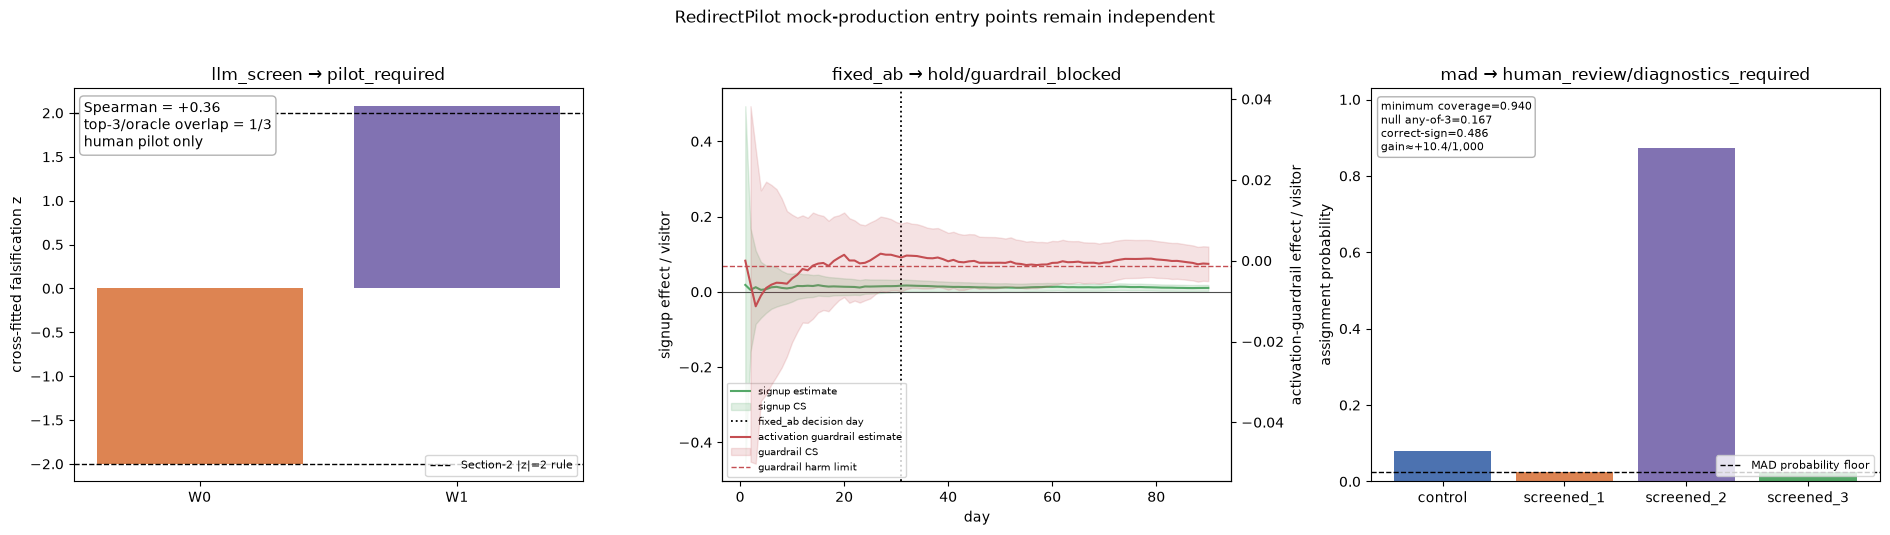

In [47]:
# [S7] One dashboard: exact evidence surfaced by the three independent API-shaped entry points.
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

# Section 2: actual selected-calibrator falsification values, rank reliability, and pilot status.
ax = axes[0]
_s7_z_labels = list(_s7_selected_z)
_s7_z_values = list(_s7_selected_z.values())
ax.bar(_s7_z_labels, _s7_z_values, color=[PALETTE["treatment"], PALETTE["direct"]])
ax.axhline(2.0, color="black", ls="--", lw=1)
ax.axhline(-2.0, color="black", ls="--", lw=1, label="Section-2 |z|=2 rule")
ax.set_ylabel("cross-fitted falsification z")
ax.set_title(f"llm_screen → {LLM_SCREEN_RESULT.status}")
ax.text(0.02, 0.97, f"Spearman = {spearman_rho:+.2f}\ntop-3/oracle overlap = {_s7_top3_overlap}/3\nhuman pilot only",
        transform=ax.transAxes, va="top", bbox={"boxstyle": "round", "fc": "white", "ec": "0.7"})
ax.legend(loc="lower right", fontsize=8)

# Section 3: E4 trajectories, with the same candidate decision day used by fixed_ab evidence.
ax = axes[1]
_s7_day = np.arange(1, S3_DAYS + 1)
_s7_p = S3_IDX["E4_signup"]; _s7_g = S3_IDX["E4_guard"]
ax.plot(_s7_day, S3_TA[S3_E4_REP, :, _s7_p], color=PALETTE["winner"], label="signup estimate")
ax.fill_between(_s7_day, S3_LO_A[S3_E4_REP, :, _s7_p], S3_HI_A[S3_E4_REP, :, _s7_p], color=PALETTE["winner"], alpha=.18, label="signup CS")
ax.axhline(0, color="0.3", lw=.8); ax.axvline(S7_FIXED_DECISION_DAY, color="black", ls=":", lw=1.3, label="fixed_ab decision day")
ax.set_xlabel("day"); ax.set_ylabel("signup effect / visitor")
ax2 = ax.twinx()
ax2.plot(_s7_day, S3_TA[S3_E4_REP, :, _s7_g], color=PALETTE["loser"], label="activation guardrail estimate")
ax2.fill_between(_s7_day, S3_LO_A[S3_E4_REP, :, _s7_g], S3_HI_A[S3_E4_REP, :, _s7_g], color=PALETTE["loser"], alpha=.16, label="guardrail CS")
ax2.axhline(-S3_DELTA["E4_guard"], color=PALETTE["loser"], ls="--", lw=1, label="guardrail harm limit")
ax2.set_ylabel("activation-guardrail effect / visitor")
ax.set_title(f"fixed_ab → {FIXED_AB_RESULT.decision}/{FIXED_AB_RESULT.status}")
_lines, _labels = ax.get_legend_handles_labels(); _lines2, _labels2 = ax2.get_legend_handles_labels()
ax.legend(_lines + _lines2, _labels + _labels2, loc="lower left", fontsize=7)

# Section 4: recorded day-60 allocation and diagnostics; no proposed winner is returned.
ax = axes[2]
_s7_probs = MAD_RESULT.evidence["armProbabilities"]
ax.bar(list(_s7_probs), list(_s7_probs.values()), color=[PALETTE["control"], PALETTE["treatment"], PALETTE["direct"], PALETTE["winner"]])
ax.axhline(MAD_RESULT.evidence["probabilityFloor"], color="black", ls="--", lw=1, label="MAD probability floor")
ax.set_ylim(0, max(.35, max(_s7_probs.values()) * 1.18)); ax.set_ylabel("assignment probability")
ax.set_title(f"mad → {MAD_RESULT.decision}/{MAD_RESULT.status}")
ax.text(0.02, 0.97,
        f"minimum coverage={MAD_RESULT.evidence['minimumCoverage']:.3f}\n" +
        f"null any-of-3={MAD_RESULT.evidence['nullAnyOfThreeFalseDeclarationDiagnostic']:.3f}\n" +
        f"correct-sign={MAD_RESULT.evidence['correctSignFraction']:.3f}\n" +
        f"gain≈{MAD_RESULT.evidence['gainVsChampionPerThousand']:+.1f}/1,000",
        transform=ax.transAxes, va="top", fontsize=8, bbox={"boxstyle": "round", "fc": "white", "ec": "0.7"})
ax.legend(loc="lower right", fontsize=8)
plt.suptitle("RedirectPilot mock-production entry points remain independent", y=1.02)
plt.tight_layout(); plt.show()


### What a real stack would add—and what remains synthetic

The embedded Next.js/TypeScript sketch can serve `MOCK_PRODUCTION_PAYLOAD` as an injected export, with `llm_screen`, `fixed_ab`, and `mad` queried independently. A real implementation would add server-side assignment and event storage, identity/privacy controls, an experiment registry, analytics ingestion, release approvals, and authenticated operator review. It would log each allocation probability with its exposure, particularly for MAD.

Nothing in this notebook is that deployment: all outcomes, calibration, confidence sequences, allocation, and the approximately +10.4 signups-per-1,000 gain are synthetic. The papers also do not prove a cross-method composition theorem for LLM screening followed by fixed A/B or MAD experimentation, which is why the contract exposes alternatives rather than a pipeline.
